## Set-up and import libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
os.chdir(r'/content/drive/MyDrive/Races/POIs_on_track/')  # Change this to the right folder for you

In [ ]:
!pip install gpxpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 691.8 kB/s eta 0:00:00


In [ ]:
!pip install overpy

In [ ]:
import requests
import plotly
import pandas as pd
import seaborn as sns
import numpy as np

import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
from geopy.distance import geodesic

from gpxpy import parse
import gpxpy.gpx
import overpy

import json
import warnings
import re

## Potential script to correct or split gpx's

### Correct gpx files if needs (by combining a city parcours in another bigger one)

Function to convert the coordinates in a gpx file in a dataframe with a latitude and longitude column

In [ ]:
data_Maribor = {
        'latitude': [46.55947858508558, 46.55882367597279],
        'longitude': [15.644400484894396, 15.644396466121517],
    }

# Create a pandas DataFrame
shortcut_df = pd.DataFrame(data_Maribor)

In [ ]:
def gpx2df(filename_gpx):
    with open(filename_gpx) as f:  #  "export_8.gpx"   "Orechov.gpx"  "export.gpx"  # "export_4.gpx"
        p = parse(f)
        points = [(point.latitude, point.longitude) for route in p.routes for point in route.points] + \
                [(point.latitude, point.longitude) for track in p.tracks for segment in track.segments for point in segment.points]
        input_df = pd.DataFrame(points, columns=["latitude", "longitude"])
    return input_df

In [ ]:
#MD1_df = gpx2df("MD1.gpx")
#MD2_df = gpx2df("MD2.gpx")
# UB30_part3_df = gpx2df("UB30_part3.gpx")
# part3_corr1_df = gpx2df("part3_corr1.gpx")
# UB30_part1_df = gpx2df("UB30_part1.gpx")
# UB30_part1_clean_df = gpx2df("UB30_part1_clean.gpx")
# rust_detour_df = gpx2df("Rust_detour.gpx")
# UB30_part2_df = gpx2df("UB30_part2.gpx")
# part2_corr1_df = gpx2df("part2_corr1.gpx")
# part2_corr2_df = gpx2df("part2_corr2.gpx")
# part2_corr3_df = gpx2df("part2_corr3.gpx")
# part2_corr4_df = gpx2df("part2_corr4.gpx")
# part2_corr5_df = gpx2df("part2_corr5.gpx")
# part2_corr6_df = gpx2df("part2_corr6.gpx")
#paczkow_df = gpx2df("MD_paczkow.gpx")
#zabreh_df = gpx2df("MD_zabreh.gpx")
to_map = gpx2df("TPR.gpx")

In [ ]:
part3_corr1_df.head()

,latitude,longitude
0,46.378035,16.185054
1,46.377949,16.184713
2,46.377831,16.184308
3,46.377813,16.184210
4,46.377918,16.184245


In [ ]:
#paczkow_df.head()

In [ ]:
from scipy.spatial.distance import cdist

def replace_route_by_start_end_match(df1, df2, lat_col='latitude', lon_col='longitude'):
    """
    Replaces a segment of the route in df1 with df2 based on the closest
    matching start and end points.

    It finds the index in df1 closest to the first row of df2 (start)
    and the index in df1 closest to the last row of df2 (end).
    Then, it replaces the portion of df1 between these indices (inclusive) with df2.

    Args:
        df1 (pd.DataFrame): The first dataframe.
        df2 (pd.DataFrame): The second dataframe to replace the segment with.
        lat_col (str): The name of the latitude column.
        lon_col (str): The name of the longitude column.

    Returns:
        pd.DataFrame: A new dataframe with the replaced segment.
                       Returns a copy of df1 if df2 is empty.
                       Returns a copy of df2 if df1 is empty.
    """
    if df1.empty:
        return df2.copy()
    if df2.empty:
        return df1.copy()

    coords1 = df1[[lat_col, lon_col]].values
    coords2_start = df2.iloc[[0]][[lat_col, lon_col]].values
    coords2_end = df2.iloc[[-1]][[lat_col, lon_col]].values

    # Find the index in df1 closest to the start of df2
    start_distances = cdist(coords1, coords2_start)
    start_index_df1 = np.argmin(start_distances)

    # Find the index in df1 closest to the end of df2
    end_distances = cdist(coords1, coords2_end)
    end_index_df1 = np.argmin(end_distances)

    # Ensure start_index is not greater than end_index
    if start_index_df1 > end_index_df1:
        start_index_df1, end_index_df1 = end_index_df1, start_index_df1

    # Construct the new dataframe
    new_df_parts = []

    # Add the part of df1 before the replacement segment
    new_df_parts.append(df1.iloc[:start_index_df1].copy())

    # Add df2 (the replacement)
    new_df_parts.append(df2.copy())

    # Add the part of df1 after the replacement segment
    new_df_parts.append(df1.iloc[end_index_df1 + 1:].copy())

    # Concatenate the parts
    new_df = pd.concat(new_df_parts, ignore_index=True)

    return new_df

In [ ]:
#MD1_df = replace_route_by_start_end_match(MD1_df, paczkow_df)
#MD3_df = replace_route_by_start_end_match(MD3_df, shortcut_df)
#UB30_part1_df = replace_route_by_start_end_match(UB30_part1_clean_df, shortcut_df)
# UB30_part2_df = replace_route_by_start_end_match(UB30_part2_df, part2_corr1_df)
# UB30_part2_df = replace_route_by_start_end_match(UB30_part2_df, part2_corr2_df)
# UB30_part2_df = replace_route_by_start_end_match(UB30_part2_df, part2_corr3_df)
# UB30_part2_df = replace_route_by_start_end_match(UB30_part2_df, part2_corr4_df)
# UB30_part2_df = replace_route_by_start_end_match(UB30_part2_df, part2_corr5_df)
# UB30_part2_df = replace_route_by_start_end_match(UB30_part2_df, part2_corr6_df)
UB30_part3_df = replace_route_by_start_end_match(UB30_part3_df, part3_corr1_df)

In [ ]:
# folium_route(paczkow_df["latitude"], paczkow_df["longitude"])

In [ ]:
folium_route(UB30_part3_df["latitude"], UB30_part3_df["longitude"])

In [ ]:
folium_route(to_map["latitude"],
             to_map["longitude"],
             width=200, height=150,
             save=True, save_name = "TPR_map.html")

Save the new dataframe as a clean gpx again:

In [ ]:
def df2gpx(df, filename_gpx, lat_col='latitude', lon_col='longitude'):
    """
    Converts a pandas DataFrame with latitude and longitude columns to a GPX file.

    Args:
        df (pd.DataFrame): The DataFrame to convert.
        filename_gpx (str): The name of the GPX file to create.
        lat_col (str): The name of the latitude column in the DataFrame.
        lon_col (str): The name of the longitude column in the DataFrame.
    """
    gpx = gpxpy.gpx.GPX()

    # Create a GPX track.
    gpx_track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(gpx_track)

    # Create a GPX segment.
    gpx_segment = gpxpy.gpx.GPXTrackSegment()
    gpx_track.segments.append(gpx_segment)

    # Iterate over the DataFrame rows and create GPX points.
    for _, row in df.iterrows():
        latitude = row[lat_col]
        longitude = row[lon_col]
        gpx_point = gpxpy.gpx.GPXTrackPoint(latitude, longitude)
        gpx_segment.points.append(gpx_point)

    # Write the GPX to a file.
    with open(filename_gpx, 'w') as f:
        f.write(gpx.to_xml())

In [ ]:
df2gpx(UB30_part3_df, "UB30_part3_clean.gpx")
#df2gpx(UB30_part1_df, "UB30_part1_clean.gpx")
#df2gpx(MD3_df, "MD3_clean.gpx")
#df2gpx(MD2_df, "MD2_clean.gpx")
#df2gpx(MD1_df, "MD1_clean.gpx")

### Split gpx in pieces

In [ ]:
name_track = "TCR12_-_Start_to_P1" #"20_Finish_Parcours"Parcours_6_The_Raid_Parcours
input_df = gpx2df(name_track + ".gpx")  # Read in the original one
split_points = 62.571911, 11.387863 #42.79133473734959, 0.5910561087923538 #44.46151483864359, 6.055011407025922, 44.56593431329663, 6.497420165660495

In [ ]:
# --- REVISED gpx2df function to include elevation ---
def gpx2df_merge_split(filename_gpx):
    with open(filename_gpx) as f:
        p = parse(f)
        points = []
        # Extract points from routes
        for route in p.routes:
            for point in route.points:
                points.append((point.latitude, point.longitude, point.elevation))
        # Extract points from tracks
        for track in p.tracks:
            for segment in track.segments:
                for point in segment.points:
                    points.append((point.latitude, point.longitude, point.elevation))
        input_df = pd.DataFrame(points, columns=["latitude", "longitude", "elevation"])
    return input_df

In [ ]:
from typing import List, Tuple
# --- Function to parse split_points string or tuple ---
def parse_split_points(split_points_raw: str | Tuple) -> List[Tuple[float, float]]:
    """
    Parses a string or a tuple of latitude and longitude pairs into a list of tuples.
    """
    if isinstance(split_points_raw, tuple):
        if len(split_points_raw) % 2 != 0:
            raise ValueError("The split_points tuple must contain an even number of coordinates (lat, lon pairs).")
        parsed_points = [(split_points_raw[i], split_points_raw[i+1]) for i in range(0, len(split_points_raw), 2)]
        return parsed_points
    elif isinstance(split_points_raw, str):
        coords_list = [float(c) for c in re.findall(r"[-+]?\d*\.\d+|\d+", split_points_raw)]
        if len(coords_list) % 2 != 0:
            raise ValueError("The split_points string must contain an even number of coordinates (lat, lon pairs).")
        parsed_points = [(coords_list[i], coords_list[i+1]) for i in range(0, len(coords_list), 2)]
        return parsed_points
    else:
        raise TypeError("split_points must be a string or a tuple of coordinates.")

# --- Function to find closest point index ---
def find_closest_point_index(df: pd.DataFrame, target_lat: float, target_lon: float) -> Tuple[int, float]:
    """
    Finds the index of the point in the DataFrame closest to the target (lat, lon).
    Returns a tuple of (index, distance_in_meters).
    """
    if df.empty:
        return -1, float('inf')
    distances = df.apply(lambda row: geodesic((row['latitude'], row['longitude']), (target_lat, target_lon)).meters, axis=1)
    closest_index = distances.idxmin()
    min_distance = distances.min()
    return closest_index, min_distance

# --- Function to save DataFrame as GPX ---
def save_df_to_gpx(df: pd.DataFrame, output_path: str):
    """
    Saves a DataFrame with 'latitude' and 'longitude' columns to a GPX file.
    It can optionally handle 'elevation' and 'time' if present.
    """
    gpx = gpxpy.gpx.GPX()
    gpx_track = gpxpy.gpx.GPXTrack()
    gpx_segment = gpxpy.gpx.GPXTrackSegment()
    gpx_track.segments.append(gpx_segment)
    gpx.tracks.append(gpx_track)

    for _, row in df.iterrows():
        point = gpxpy.gpx.GPXTrackPoint(
            latitude=row['latitude'],
            longitude=row['longitude'],
            elevation=row['elevation'] if 'elevation' in row else None,
            time=pd.to_datetime(row['time']) if 'time' in row else None
        )
        gpx_segment.points.append(point)

    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(gpx.to_xml())
    print(f"Successfully saved GPX track to '{output_path}'.")

# --- Main splitting logic ---
def split_gpx_track_and_save(
    input_df: pd.DataFrame,
    split_points_raw: str | Tuple,
    output_base_name: str,
    tolerance_m: float = 50
) -> List[pd.DataFrame]:
    """
    Splits a GPX track DataFrame into multiple DataFrames, saves each as a
    separate GPX file, and returns the list of DataFrames.
    """
    if input_df.empty:
        print("Input DataFrame is empty. Cannot split.")
        return []

    try:
        split_coords = parse_split_points(split_points_raw)
    except (ValueError, TypeError) as e:
        print(f"Error parsing split points: {e}")
        return []

    if not split_coords:
        print("No valid split points provided. Returning original track as a single segment.")
        return [input_df.copy()]

    split_indices = []
    print("\nFinding closest track points for split points:")
    for i, (lat, lon) in enumerate(split_coords):
        closest_idx, distance = find_closest_point_index(input_df, lat, lon)
        if closest_idx != -1 and distance <= tolerance_m:
            print(f"  ✅ Split point {i+1} ({lat:.4f},{lon:.4f}): Closest track point at index {closest_idx} (Distance: {distance:.2f} m)")
            split_indices.append(closest_idx)
        else:
            print(f"  ⚠️ Warning: Closest point for split point {i+1} is {distance:.2f}m away, which is outside tolerance ({tolerance_m}m). This split point will be ignored.")

    split_indices = sorted(list(set(split_indices + [0, len(input_df) - 1])))
    split_indices = [idx for idx in split_indices if 0 <= idx < len(input_df)]

    if len(split_indices) < 2:
        print("Not enough valid split points or track too short to create multiple segments. Returning original track.")
        return [input_df.copy()]

    track_segments = []
    for i in range(len(split_indices) - 1):
        start_idx = split_indices[i]
        end_idx = split_indices[i + 1]
        segment_df = input_df.iloc[start_idx : end_idx + 1].copy()

        if not segment_df.empty:
            track_segments.append(segment_df)
            output_filename = f"{output_base_name}_segment_{i+1}.gpx"
            save_df_to_gpx(segment_df, output_filename)

    return track_segments

In [ ]:
# Split and save

try:
    input_df = gpx2df_merge_split(name_track + ".gpx")
except FileNotFoundError:
    print(f"Error: The file '{name_track}.gpx' was not found. Please ensure it is in the same directory.")

# Split the track and save the segments
split_segments = split_gpx_track_and_save(
    input_df=input_df,
    split_points_raw=split_points,
    output_base_name=name_track,
    tolerance_m=50
)

if split_segments:
    print(f"\nTrack successfully split into {len(split_segments)} segments.")
    print("GPX files saved to disk.")


Finding closest track points for split points:
  ✅ Split point 1 (62.5719,11.3879): Closest track point at index 4447 (Distance: 0.88 m)
Successfully saved GPX track to 'TCR12_-_Start_to_P1_segment_1.gpx'.
Successfully saved GPX track to 'TCR12_-_Start_to_P1_segment_2.gpx'.

Track successfully split into 2 segments.
GPX files saved to disk.


### Merge two gpx files

In [ ]:
# --- Function to convert DataFrame to GPX object ---
def df2gpx(df: pd.DataFrame) -> gpxpy.gpx.GPX:
    """
    Converts a DataFrame with 'latitude' and 'longitude' columns to a gpxpy.gpx.GPX object.
    It can optionally handle 'elevation' and 'time' if present.
    """
    gpx = gpxpy.gpx.GPX()
    gpx_track = gpxpy.gpx.GPXTrack()
    gpx_segment = gpxpy.gpx.GPXTrackSegment()
    gpx_track.segments.append(gpx_segment)
    gpx.tracks.append(gpx_track)

    for _, row in df.iterrows():
        point = gpxpy.gpx.GPXTrackPoint(
            latitude=row['latitude'],
            longitude=row['longitude'],
            elevation=row['elevation'] if 'elevation' in row else None,
            time=pd.to_datetime(row['time']) if 'time' in row else None
        )
        gpx_segment.points.append(point)
    return gpx

# --- Main function to merge two GPX files ---
def merge_gpx_tracks(gpx_file1: str, gpx_file2: str, output_path: str):
    """
    Merges two GPX files by concatenating their track data and saving it
    to a new GPX file.

    Args:
        gpx_file1 (str): Path to the first GPX file.
        gpx_file2 (str): Path to the second GPX file.
        output_path (str): Path to save the merged GPX file.
    """
    try:
        # Read both GPX files into DataFrames
        df1 = gpx2df_merge_split(gpx_file1)
        df2 = gpx2df_merge_split(gpx_file2)

        # Concatenate the two DataFrames
        merged_df = pd.concat([df1, df2], ignore_index=True)

        if merged_df.empty:
            print("Error: Merged DataFrame is empty. No track data to save.")
            return

        # Convert the merged DataFrame to a GPX object
        merged_gpx = df2gpx(merged_df)

        # Save the GPX object to the output file
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(merged_gpx.to_xml())

        print(f"✅ Successfully merged '{os.path.basename(gpx_file1)}' and '{os.path.basename(gpx_file2)}'.")
        print(f"   Saved the merged track to '{output_path}'.")

    except FileNotFoundError as e:
        print(f"Error: One or more GPX files not found: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Example usage
if __name__ == "__main__":
    # For this example to work, you need two GPX files named 'track_segment_1.gpx' and 'track_segment_2.gpx'
    # in the same directory.
    # The splitting function from the previous example would generate these.
    file1 = "10_TPR_Parcours_4_and_CP4_Lles_de_Cerdanya.gpx"
    file2 = "11_TPR_Parcours4_CP4.gpx"
    merged_output_file = "10_11_TPR_Parcours4_and_CP4.gpx"

    merge_gpx_tracks(gpx_file1=file1, gpx_file2=file2, output_path=merged_output_file)

An unexpected error occurred: name 'gpx2df_merge_split' is not defined


## Run the main script

### Load the input track

In [ ]:
def gpx2df(filename_gpx):
    with open(filename_gpx) as f:  #  "export_8.gpx"   "Orechov.gpx"  "export.gpx"  # "export_4.gpx"
        p = parse(f)
        points = [(point.latitude, point.longitude) for route in p.routes for point in route.points] + \
                [(point.latitude, point.longitude) for track in p.tracks for segment in track.segments for point in segment.points]
        input_df = pd.DataFrame(points, columns=["latitude", "longitude"])
    return input_df

In [306]:
# INPUT THE TRACK NAME HERE:
name_track = "TCR12_-_Start_to_P1_segment_2"#"TCR12_-_Start_to_P1"#"UB30_part2"#"17_Skopje_naar_Vogje"#"18_Vogje_naar_Pleven"#"15_parcours_4B_naar_ferry"#"16_Durres_parcours_Skopje"#"12_Siena_met_parcours"#"11_strada_naar_siena"#"RTPL_CP4_finish"

input_df = gpx2df(name_track + ".gpx")

input_latlons = ",".join(input_df.to_numpy().flatten().astype("str"))
print(input_df)

      latitude  longitude
0     62.57191   11.38788
1     62.57188   11.38786
2     62.57185   11.38772
3     62.57179   11.38749
4     62.57174   11.38736
...        ...        ...
7009  61.33437    8.81152
7010  61.33431    8.81085
7011  61.33428    8.80960
7012  61.33429    8.80911
7013  61.33434    8.80901

[7014 rows x 2 columns]


In [307]:
# api = overpy.Overpass()

#### Run the overpass query to obtain the POIs in a strip around the gpx track

REMARK: The code below can still be improved with a rerun for a point when there was an error encountered (second trial). That way potential gaps will be closed.

Check 'https://overpass-api.de/api/status' for status.

In [308]:
# import requests
# import json
# from shapely.geometry import Point, LineString, Polygon
# from geopy.distance import geodesic
# import plotly.graph_objects as go

# # ==============================================================================
# # Helper Functions for GPS Track and Polygon Generation
# # ==============================================================================

# def create_and_visualize_enveloping_polygon(input_latlons_str, buffer_distance_m=100, segment_distance_m=10):
#     """
#     Constructs a wide enveloping polygon for a GPS track and visualizes it using Plotly.
#     The enveloping polygon's boundary is then divided into segments of a specified
#     distance, and the points that define these segments are plotted.

#     Args:
#         input_latlons_str (str): A string of comma-separated latitude and longitude pairs.
#         buffer_distance_m (int): The desired buffer distance in meters.
#         segment_distance_m (int): The desired length of each segment in meters.

#     Returns:
#         tuple: A tuple containing:
#             - list: A list of (latitude, longitude) tuples for the segmented polygon points.
#             - str: A string of latitude-longitude pairs for the enveloping polygon,
#                    formatted for an Overpass QL query's `poly` filter.
#     """
#     coords = [float(c) for c in input_latlons_str.split(',')]
#     points = []
#     for i in range(0, len(coords), 2):
#         lat = coords[i]
#         lon = coords[i + 1]
#         points.append(Point(lon, lat))

#     track_line = LineString(points)

#     approx_meters_per_degree = 111139
#     buffer_distance_deg = buffer_distance_m / approx_meters_per_degree

#     enveloping_polygon = track_line.buffer(buffer_distance_deg, quad_segs=25)

#     exterior_line = enveloping_polygon.exterior

#     # Calculate actual length of the exterior line using geodesic distances
#     poly_coords_latlon_original = [(p[1], p[0]) for p in exterior_line.coords]
#     total_length_m = 0
#     for i in range(len(poly_coords_latlon_original) - 1):
#         total_length_m += geodesic(poly_coords_latlon_original[i], poly_coords_latlon_original[i+1]).meters

#     num_segments = int(round(total_length_m / segment_distance_m))
#     segment_length_normalized = exterior_line.length / num_segments

#     # Generate segment points using interpolation
#     segment_points_shapely = [exterior_line.interpolate(i * segment_length_normalized) for i in range(num_segments + 1)]
#     # Ensure the first and last point are the same for a closed loop
#     if segment_points_shapely[0] != segment_points_shapely[-1]:
#             segment_points_shapely.append(segment_points_shapely[0])

#     # Convert shapely Points to (lat, lon) tuples for output
#     segmented_latlons_output = [(p.y, p.x) for p in segment_points_shapely]


#     # 7. Visualization using Plotly
#     fig = go.Figure()

#     # Add GPS Track Points (Scatter)
#     fig.add_trace(go.Scatter(
#         x=[p.x for p in points],
#         y=[p.y for p in points],
#         mode='markers',
#         name='GPS Track Points',
#         marker=dict(color='blue', size=8),
#         hoverinfo='text',
#         text=[f"Lat: {p.y:.5f}<br>Lon: {p.x:.5f}" for p in points]
#     ))

#     # Add GPS Track Line
#     fig.add_trace(go.Scatter(
#         x=[p.x for p in points],
#         y=[p.y for p in points],
#         mode='lines',
#         name='GPS Track Line',
#         line=dict(color='blue', width=1, dash='dot'),
#         hoverinfo='skip'
#     ))

#     # Add Enveloping Polygon Outline (as a line)
#     # Using the original polygon's exterior coordinates for smooth outline in plot
#     poly_lon_original = [p[0] for p in enveloping_polygon.exterior.coords]
#     poly_lat_original = [p[1] for p in enveloping_polygon.exterior.coords]
#     fig.add_trace(go.Scatter(
#         x=poly_lon_original,
#         y=poly_lat_original,
#         mode='lines',
#         fill='toself',
#         fillcolor='rgba(128, 0, 128, 0.1)',
#         line=dict(color='purple', width=2),
#         name=f'Enveloping Polygon ({buffer_distance_m}m wide)',
#         hoverinfo='text',
#         text=[f"Polygon Boundary<br>Lat: {la:.5f}<br>Lon: {lo:.5f}" for la, lo in zip(poly_lat_original, poly_lon_original)]
#     ))

#     # Add Segment Division Points
#     fig.add_trace(go.Scatter(
#         x=[p.x for p in segment_points_shapely],
#         y=[p.y for p in segment_points_shapely],
#         mode='markers',
#         name=f'Segment Division Points (~{segment_distance_m}m each)',
#         marker=dict(color='black', size=6, symbol='circle'),
#         hoverinfo='text',
#         text=[f"Segment Point<br>Lat: {p.y:.5f}<br>Lon: {p.x:.5f}" for p in segment_points_shapely]
#     ))

#     fig.update_layout(
#         title=f'GPS Track with Enveloping Polygon ({buffer_distance_m}m wide) and ~{segment_distance_m}m segments',
#         xaxis_title='Longitude',
#         yaxis_title='Latitude',
#         hovermode='closest',
#         showlegend=True,
#         yaxis=dict(scaleanchor="x", scaleratio=1),
#         height=700,
#         width=700,
#         legend=dict(
#             x=0.1,
#             y=-0.3,
#             xanchor='left',
#             yanchor='top',
#             bgcolor='rgba(255,255,255,0.7)',
#             bordercolor='Black',
#             borderwidth=1,
#             font=dict(
#                 family="Arial",
#                 size=12,
#                 color="black"
#             )
#         )
#     )

#     fig.show()

#     # Create the poly_coords_str from the segmented points for Overpass
#     # Overpass poly filter expects "lat lon lat lon..." format
#     poly_coords_str = " ".join([f"{lat} {lon}" for lat, lon in segmented_latlons_output])

#     return segmented_latlons_output, poly_coords_str

# # ==============================================================================
# # Overpass Query Generation Functions
# # ==============================================================================

# def generate_overpass_query_for_buffer(polygon_coords_str, buffer_distance_m):
#     """
#     Generates an Overpass QL query to find various points of interest
#     within the specified polygon, tailored for a specific buffer distance.

#     Args:
#         polygon_coords_str (str): The string of "lat lon" coordinates for the polygon.
#         buffer_distance_m (int): The buffer distance in meters (used for query content).

#     Returns:
#         str: A complete Overpass QL query string.
#     """
#     query_parts = []

#     # Shops & Amenities (for 200m and 500m)
#     if buffer_distance_m in [200, 500]:
#         query_parts.append(f"""
#     nwr["amenity"="fuel"](poly:"{polygon_coords_str}");
#     nwr["shop"="supermarket"](poly:"{polygon_coords_str}");
#     nwr["shop"="convenience"](poly:"{polygon_coords_str}");
#     nwr["shop"="grocery"](poly:"{polygon_coords_str}");
#     nwr["shop"="bakery"](poly:"{polygon_coords_str}");
#     nwr["shop"="kiosk"](poly:"{polygon_coords_str}");
#     nwr["amenity"="restaurant"](poly:"{polygon_coords_str}");
#     nwr["amenity"="pub"](poly:"{polygon_coords_str}");
#     nwr["tourism"="hotel"](poly:"{polygon_coords_str}");
#     nwr["tourism"="guest_house"](poly:"{polygon_coords_str}");
#     nwr["amenity"="drinking_water"](poly:"{polygon_coords_str}");
#         """)

#     # Places & Landmarks (for 500m and 2000m)
#     if buffer_distance_m == 2000:
#         query_parts.append(f"""
#     nwr["place"="city"](poly:"{polygon_coords_str}");
#         """)
#     if buffer_distance_m == 500:
#         query_parts.append(f"""
#     nwr["place"="town"](poly:"{polygon_coords_str}");
#     nwr["place"="village"](poly:"{polygon_coords_str}");
#     nwr["place"="settlement"](poly:"{polygon_coords_str}");
#         """)
#     if buffer_distance_m == 200:
#         query_parts.append(f"""
#     nwr["natural"="peak"](poly:"{polygon_coords_str}");
#     nwr["natural"="hill"](poly:"{polygon_coords_str}");
#     nwr["mountain_pass"="yes"](poly:"{polygon_coords_str}");
#         """)


#     combined_query_elements = "\n".join(query_parts)

#     overpass_query_template = f"""
# [out:json][timeout:1000];
# (
#     {combined_query_elements}
#     (._; >;);
# );
# out center;
# """
#     return overpass_query_template

# def execute_overpass_query(query):
#     """
#     Executes an Overpass QL query and returns the JSON result.

#     Args:
#         query (str): The Overpass QL query string.

#     Returns:
#         dict: The JSON data from the Overpass API response, or None if an error occurs.
#     """
#     overpass_url = "http://overpass-api.de/api/interpreter"
#     print("Executing Overpass query...")
#     try:
#         response = requests.post(overpass_url, data={'data': query})
#         response.raise_for_status()  # Raise an exception for bad status codes
#         print("Query executed successfully.")
#         return response.json()
#     except requests.exceptions.RequestException as e:
#         print(f"Error executing Overpass query: {e}")
#         return None

# # ==============================================================================
# # Main Execution Block
# # ==============================================================================

# if __name__ == "__main__":
#     # Define your input_latlons here for demonstration
#     # Example: A simple track for testing
#     #input_latlons = "48.149,11.564,48.150,11.565,48.151,11.566,48.152,11.567" # Example GPS track

#     # Step 1: Create polygons for each buffer distance
#     segmented_points_latlon_200, polygon_coords_for_query_200 = create_and_visualize_enveloping_polygon(input_latlons, buffer_distance_m=200, segment_distance_m=200)
#     segmented_points_latlon_500, polygon_coords_for_query_500 = create_and_visualize_enveloping_polygon(input_latlons, buffer_distance_m=500, segment_distance_m=500)
#     segmented_points_latlon_2000, polygon_coords_for_query_2000 = create_and_visualize_enveloping_polygon(input_latlons, buffer_distance_m=2000, segment_distance_m=2000)

#     print(f"\n--- Number of Segmented Points for the 200m band: {len(segmented_points_latlon_200)} ---")
#     print(f"\n--- Number of Segmented Points for the 500m band: {len(segmented_points_latlon_500)} ---")
#     print(f"\n--- Number of Segmented Points for the 2000m band: {len(segmented_points_latlon_2000)} ---")

#     # Step 2 & 3: Generate and execute queries consecutively for each buffer distance
#     query_buffers = {
#         200: polygon_coords_for_query_200,
#         500: polygon_coords_for_query_500,
#         2000: polygon_coords_for_query_2000
#     }

#     all_overpass_results = {} # Store results per buffer
#     combined_overpass_dict = {} # New dictionary to store all elements at the same level

#     for buffer_distance, poly_coords_str in query_buffers.items():
#         print(f"\n--- Querying for {buffer_distance}m buffer ---")
#         current_query = generate_overpass_query_for_buffer(poly_coords_str, buffer_distance)
#         # print(f"\n--- Generated Overpass Query for {buffer_distance}m ---")
#         # print(current_query)

#         overpass_results = execute_overpass_query(current_query)
#         all_overpass_results[buffer_distance] = overpass_results

#         if overpass_results:
#             print(f"\n--- Overpass Query Results Summary for {buffer_distance}m buffer ---")
#             if overpass_results.get('elements'):
#                 print(f"Found {len(overpass_results['elements'])} elements.")
#                 for element in overpass_results['elements']:
#                     # Create a unique key for each element (e.g., "node/12345", "way/67890")
#                     # And add buffer_distance_m to the element data
#                     element_key = f"{element.get('type')}/{element.get('id')}"
#                     # If an element appears in multiple buffers, keep the one from the smaller buffer
#                     # (or larger, depending on desired priority; here, new key overwrites old)
#                     if element_key not in combined_overpass_dict:
#                         element['buffer_distance_m'] = buffer_distance
#                         combined_overpass_dict[element_key] = element
#                     else:
#                         # If already exists, and you want to prioritize the smaller buffer,
#                         # you could add a check:
#                         # if buffer_distance < combined_overpass_dict[element_key]['buffer_distance_m']:
#                         #     element['buffer_distance_m'] = buffer_distance
#                         #     combined_overpass_dict[element_key] = element
#                         pass # For now, first one encountered wins if keys are the same
#             else:
#                 print(f"No elements found in the {buffer_distance}m polygon.")

#         else:
#             print(f"\nFailed to get results from the Overpass API for {buffer_distance}m buffer.")
#             # Optional: Rerun if an error was encountered
#             print(f"Attempting to rerun query for {buffer_distance}m buffer...")
#             overpass_results = execute_overpass_query(current_query)
#             all_overpass_results[buffer_distance] = overpass_results
#             if overpass_results:
#                 print(f"Rerun successful for {buffer_distance}m buffer. Found {len(overpass_results.get('elements', []))} elements.")
#             else:
#                 print(f"Rerun failed for {buffer_distance}m buffer.")




In [309]:
#combined_overpass_dict

In [310]:
# ==============================================================================
# Helper Functions for GPS Track and Polygon Generation
# ==============================================================================

def create_and_visualize_enveloping_polygon(input_latlons_str, buffer_distance_m=100, segment_distance_m=10):
    """
    Constructs a wide enveloping polygon for a GPS track and visualizes it using Plotly.
    The enveloping polygon's boundary is then divided into segments of a specified
    distance, and the points that define these segments are plotted.

    Args:
        input_latlons_str (str): A string of comma-separated latitude and longitude pairs.
        buffer_distance_m (int): The desired buffer distance in meters.
        segment_distance_m (int): The desired length of each segment in meters.

    Returns:
        tuple: A tuple containing:
            - list: A list of (latitude, longitude) tuples for the segmented polygon points.
            - str: A string of latitude-longitude pairs for the enveloping polygon,
                   formatted for an Overpass QL query's `poly` filter.
    """
    coords = [float(c) for c in input_latlons_str.split(',')]
    points = []
    for i in range(0, len(coords), 2):
        lat = coords[i]
        lon = coords[i + 1]
        points.append(Point(lon, lat))

    track_line = LineString(points)

    approx_meters_per_degree = 111139
    buffer_distance_deg = buffer_distance_m / approx_meters_per_degree

    enveloping_polygon = track_line.buffer(buffer_distance_deg, quad_segs=25)

    exterior_line = enveloping_polygon.exterior

    # Calculate actual length of the exterior line using geodesic distances
    poly_coords_latlon_original = [(p[1], p[0]) for p in exterior_line.coords]
    total_length_m = 0
    for i in range(len(poly_coords_latlon_original) - 1):
        total_length_m += geodesic(poly_coords_latlon_original[i], poly_coords_latlon_original[i+1]).meters

    num_segments = int(round(total_length_m / segment_distance_m))
    segment_length_normalized = exterior_line.length / num_segments

    # Generate segment points using interpolation
    segment_points_shapely = [exterior_line.interpolate(i * segment_length_normalized) for i in range(num_segments + 1)]
    # Ensure the first and last point are the same for a closed loop
    if segment_points_shapely[0] != segment_points_shapely[-1]:
         segment_points_shapely.append(segment_points_shapely[0])

    # Convert shapely Points to (lat, lon) tuples for output
    segmented_latlons_output = [(p.y, p.x) for p in segment_points_shapely]


    # 7. Visualization using Plotly
    fig = go.Figure()

    # Add GPS Track Points (Scatter)
    fig.add_trace(go.Scatter(
        x=[p.x for p in points],
        y=[p.y for p in points],
        mode='markers',
        name='GPS Track Points',
        marker=dict(color='blue', size=8),
        hoverinfo='text',
        text=[f"Lat: {p.y:.5f}<br>Lon: {p.x:.5f}" for p in points]
    ))

    # Add GPS Track Line
    fig.add_trace(go.Scatter(
        x=[p.x for p in points],
        y=[p.y for p in points],
        mode='lines',
        name='GPS Track Line',
        line=dict(color='blue', width=1, dash='dot'),
        hoverinfo='skip'
    ))

    # Add Enveloping Polygon Outline (as a line)
    # Using the original polygon's exterior coordinates for smooth outline in plot
    poly_lon_original = [p[0] for p in enveloping_polygon.exterior.coords]
    poly_lat_original = [p[1] for p in enveloping_polygon.exterior.coords]
    fig.add_trace(go.Scatter(
        x=poly_lon_original,
        y=poly_lat_original,
        mode='lines',
        fill='toself',
        fillcolor='rgba(128, 0, 128, 0.1)',
        line=dict(color='purple', width=2),
        name=f'Enveloping Polygon ({buffer_distance_m}m wide)',
        hoverinfo='text',
        text=[f"Polygon Boundary<br>Lat: {la:.5f}<br>Lon: {lo:.5f}" for la, lo in zip(poly_lat_original, poly_lon_original)]
    ))

    # Add Segment Division Points
    fig.add_trace(go.Scatter(
        x=[p.x for p in segment_points_shapely],
        y=[p.y for p in segment_points_shapely],
        mode='markers',
        name=f'Segment Division Points (~{segment_distance_m}m each)',
        marker=dict(color='black', size=6, symbol='circle'),
        hoverinfo='text',
        text=[f"Segment Point<br>Lat: {p.y:.5f}<br>Lon: {p.x:.5f}" for p in segment_points_shapely]
    ))

    fig.update_layout(
        title=f'GPS Track with Enveloping Polygon ({buffer_distance_m}m wide) and ~{segment_distance_m}m segments',
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        hovermode='closest',
        showlegend=True,
        yaxis=dict(scaleanchor="x", scaleratio=1),
        height=700,
        width=700,
        legend=dict(
            x=0.1,
            y=-0.3,
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(255,255,255,0.7)',
            bordercolor='Black',
            borderwidth=1,
            font=dict(
                family="Arial",
                size=12,
                color="black"
            )
        )
    )

    fig.show()

    # Create the poly_coords_str from the segmented points for Overpass
    # Overpass poly filter expects "lat lon lat lon..." format
    poly_coords_str = " ".join([f"{lat} {lon}" for lat, lon in segmented_latlons_output])

    return segmented_latlons_output, poly_coords_str

# ==============================================================================
# Overpass Query Generation Functions
# ==============================================================================

# def generate_consolidated_overpass_query_poly(polygon_coords_str_1, polygon_coords_str_2, polygon_coords_str_3):
#     """
#     Generates a consolidated Overpass QL query to find various points of interest
#     within the specified polygon.

#     Args:
#         polygon_coords_str (str): The string of "lat lon" coordinates for the polygon.

#     Returns:
#         str: A complete, consolidated Overpass QL query string.
#     """
#     # This function remains mostly the same, as it takes the string
#     # representation that Overpass expects.
#     consolidated_overpass_query_template = f"""
# [out:json][timeout:1000];
# (
#   // Shops & Amenities
#   nwr["amenity"="fuel"](poly:"{polygon_coords_str_1}");
#   nwr["shop"="supermarket"](poly:"{polygon_coords_str_1}");
#   nwr["shop"="convenience"](poly:"{polygon_coords_str_1}");
#   nwr["shop"="grocery"](poly:"{polygon_coords_str_1}");
#   nwr["shop"="bakery"](poly:"{polygon_coords_str_1}");
#   nwr["shop"="kiosk"](poly:"{polygon_coords_str_1}");
#   nwr["amenity"="restaurant"](poly:"{polygon_coords_str_1}");
#   nwr["amenity"="pub"](poly:"{polygon_coords_str_1}");
#   nwr["tourism"="hotel"](poly:"{polygon_coords_str_1}");
#   nwr["tourism"="guest_house"](poly:"{polygon_coords_str_1}");
#   nwr["amenity"="drinking_water"](poly:"{polygon_coords_str_1}");

#   // Places & Landmarks
#   nwr["place"="city"](poly:"{polygon_coords_str_3}");
#   nwr["place"="town"](poly:"{polygon_coords_str_3}");
#   nwr["place"="village"](poly:"{polygon_coords_str_2}");
#   nwr["place"="settlement"](poly:"{polygon_coords_str_2}");
#   nwr["natural"="peak"](poly:"{polygon_coords_str_1}");
#   nwr["natural"="hill"](poly:"{polygon_coords_str_1}");
#   nwr["mountain_pass"="yes"](poly:"{polygon_coords_str_1}");

#   (._; >;);
# );
# out center;
# """

#    return consolidated_overpass_query_template

# QUESTION: To change to polygon for 2000m as well for village and settlement (for simplification + we do not know how they classify town/village/... everywhere)
#// Running Sushi Locations (500m polygon)
#  nwr["cuisine"="sushi"]["name"~"running sushi", i](poly:"{polygon_coords_str_2}");



# def execute_overpass_query(query):
#     """
#     Executes an Overpass QL query and returns the JSON result.

#     Args:
#         query (str): The Overpass QL query string.

#     Returns:
#         dict: The JSON data from the Overpass API response, or None if an error occurs.
#     """
#     overpass_url = "http://overpass-api.de/api/interpreter"#"https://kumi.systems" #
#     print("Executing Overpass query...")
#     try:
#         response = requests.post(overpass_url, data={'data': query})
#         response.raise_for_status()  # Raise an exception for bad status codes
#         print("Query executed successfully.")
#         return response.json()
#     except requests.exceptions.RequestException as e:
#         print(f"Error executing Overpass query: {e}")
#         return None

# import requests

def execute_overpass_query(query):
    # FIX 1: De URL MOET eindigen op /api/interpreter
    overpass_url = "https://overpass-api.de/api/interpreter"

    headers = {
        'User-Agent': 'TCR_Data_Collector/1.0',
        'Accept': 'application/json'
    }

    # Forceer JSON output
    if "[out:json]" not in query:
        query = "[out:json]; " + query

    print("Executing Overpass query...")
    try:
        # Gebruik POST met de data dictionary
        response = requests.post(overpass_url, data={'data': query}, headers=headers, timeout=120)

        # Als er een fout is, print de tekst van de server (bevat de syntax error)
        if response.status_code != 200:
            print(f"Server Fout {response.status_code}: {response.text}")
            return None

        return response.json()

    except Exception as e:
        print(f"Fout tijdens uitvoeren: {e}")
        return None

def generate_consolidated_overpass_query_poly(polygon_coords_str_1, polygon_coords_str_2, polygon_coords_str_3):
    # FIX 2: Verwijder (._; >;);
    # Dit is niet nodig bij 'out center' en veroorzaakt vaak geheugenfouten bij grote poly-queries.
    # 'out center' geeft je direct het middelpunt van ways/relations, wat perfect is voor POIs.

    query = f"""
[out:json][timeout:1000];
(
  nwr["amenity"="fuel"](poly:"{polygon_coords_str_1}");
  nwr["shop"~"supermarket|convenience|grocery|bakery|kiosk"](poly:"{polygon_coords_str_1}");
  nwr["amenity"~"restaurant|pub"](poly:"{polygon_coords_str_1}");
  nwr["tourism"~"hotel|guest_house"](poly:"{polygon_coords_str_1}");
  nwr["amenity"="drinking_water"](poly:"{polygon_coords_str_1}");

  nwr["place"~"city|town"](poly:"{polygon_coords_str_3}");
  nwr["place"~"village|settlement"](poly:"{polygon_coords_str_2}");
  nwr["natural"~"peak|hill"](poly:"{polygon_coords_str_1}");
  nwr["mountain_pass"="yes"](poly:"{polygon_coords_str_1}");
);
out center;
"""
    return query




# ==============================================================================
# Main Execution Block
# ==============================================================================

if __name__ == "__main__":
    # Step 1: Create the polygon and get its coordinates string.
    # Now it returns two values: the list of segmented points and the string for Overpass
    segmented_points_latlon_200, polygon_coords_for_query_200 = create_and_visualize_enveloping_polygon(input_latlons, buffer_distance_m=200, segment_distance_m=200)
    segmented_points_latlon_500, polygon_coords_for_query_500 = create_and_visualize_enveloping_polygon(input_latlons, buffer_distance_m=500, segment_distance_m=500)
    segmented_points_latlon_2000, polygon_coords_for_query_2000 = create_and_visualize_enveloping_polygon(input_latlons, buffer_distance_m=2000, segment_distance_m=2000)

    print(f"\n--- Number of Segmented Points for the 200m band: {len(segmented_points_latlon_200)} ---")
    print(f"\n--- Number of Segmented Points for the 500m band: {len(segmented_points_latlon_500)} ---")
    print(f"\n--- Number of Segmented Points for the 2000m band: {len(segmented_points_latlon_2000)} ---")
    # You can inspect the segmented_points_latlon if needed:
    # print(segmented_points_latlon[:5]) # Print first 5 points

    # Step 2: Generate the consolidated Overpass QL query using the polygon.
    consolidated_query = generate_consolidated_overpass_query_poly(polygon_coords_for_query_200, polygon_coords_for_query_500, polygon_coords_for_query_2000)

    # print("\n--- Generated Overpass Query ---")
    # print(consolidated_query)

    # Step 3: Execute the generated query and process the results.
    overpass_results = execute_overpass_query(consolidated_query)

    if overpass_results:
        print("\n--- Overpass Query Results Summary ---")
        if overpass_results.get('elements'):
            print(f"Found {len(overpass_results['elements'])} elements.")
            print("First 5 elements:")
            for element in overpass_results['elements'][:5]:
                tags = element.get('tags', {})
                name = tags.get('name', 'N/A')
                amenity = tags.get('amenity', tags.get('shop', 'N/A'))
                print(f"  - Type: {element['type']}, ID: {element['id']}, Name: {name}, Amenity/Shop: {amenity}")
        else:
            print("No elements found in the specified polygon.")
    # Step 3b: rerun if need (error encountered)
    else:
        overpass_results = execute_overpass_query(consolidated_query)
        if overpass_results:
            print("\n--- Overpass Query Results Summary ---")
            if overpass_results.get('elements'):
                print(f"Found {len(overpass_results['elements'])} elements.")
                print("First 5 elements:")
                for element in overpass_results['elements'][:5]:
                    tags = element.get('tags', {})
                    name = tags.get('name', 'N/A')
                    amenity = tags.get('amenity', tags.get('shop', 'N/A'))
                    print(f"  - Type: {element['type']}, ID: {element['id']}, Name: {name}, Amenity/Shop: {amenity}")
            else:
                print("No elements found in the specified polygon.")
        else:
            print("\nFailed to get results from the Overpass API.")


Output hidden; open in https://colab.research.google.com to view.

In [311]:
overpass_results

{'version': 0.6,
 'generator': 'Overpass API 0.7.62.11 87bfad18',
 'osm3s': {'timestamp_osm_base': '2026-04-24T12:27:45Z',
  'copyright': 'The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.'},
 'elements': [{'type': 'node',
   'id': 34222956,
   'lat': 62.2742908,
   'lon': 10.7768676,
   'tags': {'name': 'Tynset',
    'name:ru': 'Тюнсет',
    'place': 'town',
    'population': '3067',
    'population:date': '2025-01-01',
    'ref:ssb_tettsted': '1191',
    'source:population': 'SSB - befolkning i tettsteder',
    'ssr:stedsnr': '375248'}},
  {'type': 'node',
   'id': 60647032,
   'lat': 62.5745909,
   'lon': 11.3836172,
   'tags': {'alt_name': 'Bergstaden',
    'name': 'Røros',
    'name:de': 'Röros',
    'name:no': 'Røros',
    'name:ru': 'Рёрус',
    'name:sma': 'Plaassja',
    'place': 'town',
    'population': '3897',
    'population:date': '2025-01-01',
    'ref:ssb_tettsted': '6631',
    'source:population': 'SSB - befolkning

For fun: get the sushi places along the way (you never know if there is a running sushi one = BINGO!)

In [312]:
def filter_running_sushi_from_results(overpass_results):
    """
    Filters a dictionary of Overpass API results to find all sushi restaurants,
    including those specifically tagged as "running sushi".

    Args:
        overpass_results (dict): The dictionary containing the Overpass API results.

    Returns:
        list: A list of dictionaries, each representing a sushi restaurant.
    """
    sushi_locations = []

    if not overpass_results or 'elements' not in overpass_results or not isinstance(overpass_results['elements'], list):
        print("Invalid Overpass results format. 'elements' key not found or is not a list.")
        return sushi_locations

    for element in overpass_results['elements']:
        tags = element.get('tags', {})

        # Updated filtering logic for 'cuisine' tag
        has_sushi_cuisine = 'sushi' in tags.get('cuisine', '').lower()
        is_running_sushi = 'running sushi' in tags.get('name', '').lower()

        if has_sushi_cuisine or is_running_sushi:
            sushi_locations.append(element)

    return sushi_locations

# Filter the results
running_sushi_spots = filter_running_sushi_from_results(overpass_results)

# Print the filtered locations
if running_sushi_spots:
    print(f"Found {len(running_sushi_spots)} running sushi locations:")
    for spot in running_sushi_spots:
        name = spot['tags'].get('name', 'Unnamed')
        lat = spot.get('lat', spot.get('center', {}).get('lat'))
        lon = spot.get('lon', spot.get('center', {}).get('lon'))
        print(f"- {name} (ID: {spot['id']}) at Lat: {lat}, Lon: {lon}")
else:
    print("No running sushi locations found in the results.")

No running sushi locations found in the results.


#### Categorize the POIs in the 3 main categories

In [313]:
# --- Categorization rules (remain the same) ---
categorization_rules = {
    "shops_fuel": [
        ("amenity", "fuel"), ("shop", "supermarket"), ("shop", "convenience"),
        ("shop", "grocery"), ("shop", "bakery"), ("shop", "kiosk")
    ],
    "restaurants_hotels": [
        ("amenity", "restaurant"), ("amenity", "pub"),
        ("tourism", "hotel"), ("tourism", "guest_house"),
        ("amenity", "drinking_water")
    ],
    "places_landmarks": [
        ("place", "city"), ("place", "town"), ("place", "village"),
        ("natural", "peak"), ("natural", "hill"), ("mountain_pass", "yes")
    ]
}


def process_overpass_result_elements(overpass_raw_result: dict, rules: dict) -> dict:
    """
    Processes a raw Overpass API JSON result dictionary (from a single query)
    and categorizes its elements into DataFrames.

    Args:
        overpass_raw_result (dict): The dictionary returned by Overpass API.
        rules (dict): Categorization rules.

    Returns:
        dict: A dictionary of pandas DataFrames, where keys are category names
              and values are DataFrames containing the fetched and categorized data.
    """

    if overpass_raw_result is not None:
        elements_raw = overpass_raw_result.get('elements', [])
    else:
        elements_raw = []
        print("Warning: No data received from Overpass API.")

    if not elements_raw:
        print("No raw OSM elements found in the provided Overpass result dictionary.")
        return {cat: pd.DataFrame() for cat in rules}
    else:
        print(f"Processing {len(elements_raw)} raw OSM elements from the provided Overpass result.")

    # Flatten elements for DataFrame creation
    elements_processed = []
    for el in elements_raw:
        element_data = {
            'id': el.get('id'),
            'type': el.get('type'),
            'lat': el.get('lat') if el.get('type') == 'node' else el.get('center', {}).get('lat'),
            'lon': el.get('lon') if el.get('type') == 'node' else el.get('center', {}).get('lon'),
            'tags': el.get('tags', {}) # Ensure tags is a dictionary
        }
        elements_processed.append(element_data)

    df_all = pd.json_normalize(elements_processed, sep='.')

    # --- Name and Operator Processing ---
    # Initialize 'name' and 'operator' columns to None if they don't exist
    if 'name' not in df_all.columns:
        df_all['name'] = None
    if 'operator' not in df_all.columns:
        df_all['operator'] = None

    # Populate top-level 'name' column
    if 'tags.name' in df_all.columns:
        df_all['name'] = df_all['name'].fillna(df_all['tags.name'])
    # Populate top-level 'operator' column
    if 'tags.operator' in df_all.columns:
        df_all['operator'] = df_all['operator'].fillna(df_all['tags.operator'])
        # Add operator to name if name is still empty
        df_all['name'] = df_all['name'].fillna(df_all['tags.operator'])

    # For entries still without a name, try to use amenity/shop tag value or ID
    # Iterate through potential tag columns to use as fallback for 'name'
    for tag_key in ['amenity', 'shop', 'place', 'natural', 'tourism', 'landuse']:
        full_tag_col = f'tags.{tag_key}'
        if full_tag_col in df_all.columns:
            df_all['name'] = df_all['name'].fillna(df_all[full_tag_col])

    # Apply the specific parcel_locker logic
    if 'tags.amenity' in df_all.columns and 'operator' in df_all.columns:
        df_all.loc[df_all['tags.amenity'] == 'parcel_locker', 'name'] = \
            df_all.loc[df_all['tags.amenity'] == 'parcel_locker', 'operator']

    # Finally, if still no name, use ID
    if 'id' in df_all.columns:
        df_all['name'] = df_all['name'].fillna('ID_' + df_all['id'].astype(str))

    # Now, only drop rows where 'name' is truly empty after all attempts
    df_all = df_all[df_all['name'].notna()].reset_index(drop=True)


    if df_all.empty:
        print("No elements remained after name processing.")
        return {cat: pd.DataFrame() for cat in rules}

    categorized_dfs = {cat: pd.DataFrame() for cat in rules}

    for category_name, rule_list in rules.items():
        category_mask = pd.Series([False] * len(df_all), index=df_all.index)
        for tag_key, tag_value in rule_list:
            full_tag_col = f'tags.{tag_key}'
            if full_tag_col in df_all.columns:
                # Ensure comparison is robust to NaNs if fillna('') was not sufficient
                category_mask = category_mask | (df_all[full_tag_col].astype(str).fillna('') == str(tag_value))

        categorized_df = df_all[category_mask].copy()

        if not categorized_df.empty:
            if 'id' in categorized_df.columns and categorized_df['id'].notna().any():
                categorized_df.drop_duplicates(subset=['id'], inplace=True)
            elif 'lat' in categorized_df.columns and 'lon' in categorized_df.columns:
                categorized_df.drop_duplicates(subset=['lat', 'lon'], inplace=True)

            categorized_dfs[category_name] = categorized_df.reset_index(drop=True)

    return categorized_dfs


def consolidate_overpass_data_from_single_result(overpass_raw_result: dict) -> dict:
    """
    Consolidates OpenStreetMap data from a single, large Overpass API JSON result,
    categorizing it based on predefined rules.

    Args:
        overpass_raw_result (dict): The dictionary returned by a single Overpass API query.

    Returns:
        dict: A dictionary of pandas DataFrames, where keys are category names
              and values are DataFrames containing the fetched and categorized data.
    """
    print("Starting data processing from provided Overpass result.")

    # Process the single large result set
    all_track_categorized_dfs = process_overpass_result_elements(
        overpass_raw_result,
        categorization_rules
    )

    print("\n--- Final Deduplication and Consolidation ---")
    for category, df in all_track_categorized_dfs.items():
        if not df.empty:
            initial_count = len(df)
            # Ensure 'id' column exists before dropping duplicates by it
            if 'id' in df.columns and df['id'].notna().any():
                df.drop_duplicates(subset=['id'], inplace=True)
            elif 'lat' in df.columns and 'lon' in df.columns:
                df.drop_duplicates(subset=['lat', 'lon'], inplace=True)
            final_count = len(df)
            print(f"'{category}': Reduced from {initial_count} to {final_count} unique entries ({initial_count-final_count} duplicates).")
            all_track_categorized_dfs[category] = df.reset_index(drop=True)
        else:
            print(f"'{category}': No data found.")

    return all_track_categorized_dfs


if __name__ == "__main__":
    final_results = consolidate_overpass_data_from_single_result(overpass_results)
    # mock_raw_overpass_result = {'elements': list(combined_overpass_dict.values())}
    # final_results = consolidate_overpass_data_from_single_result(mock_raw_overpass_result)

    # print("\n--- Final Results Summary ---")
    # for category, df in final_results.items():
    #     print(f"Category '{category}': {len(df)} unique entries.")
    #     if not df.empty:
    #         print(df.head())

Starting data processing from provided Overpass result.
Processing 90 raw OSM elements from the provided Overpass result.

--- Final Deduplication and Consolidation ---
'shops_fuel': Reduced from 28 to 28 unique entries (0 duplicates).
'restaurants_hotels': Reduced from 14 to 14 unique entries (0 duplicates).
'places_landmarks': Reduced from 45 to 45 unique entries (0 duplicates).


In [314]:
# final_results['places_landmarks'].head(30)

In [315]:
#final_results['places_landmarks'][final_results['places_landmarks']['id'] == 1695086208][['type','tags.name','tags.name:en','tags.place']]

In [316]:
# selected_row_df = final_results['places_landmarks'][final_results['places_landmarks']['id'] == 1695086208]


# if not selected_row_df.empty:
#     # Access the single row as a Series
#     row_series = selected_row_df.iloc[0]

#     print(f"Details for element with ID 1695086208 (non-empty/non-NaN columns):")
#     for col_name, value in row_series.items():
#         # Check for NaN, None, or empty string values
#         if pd.isna(value) or value is None or (isinstance(value, str) and value.strip() == ''):
#             # Do nothing if the value is empty or NaN
#             pass
#         else:
#             print(f"  {col_name}: {value}")

In [317]:
# final_results['restaurants_hotels']

In [318]:
shops_df = final_results['shops_fuel']
restaurants_df = final_results['restaurants_hotels']

# Ensure both DataFrames are not empty before concatenating
if not shops_df.empty and not restaurants_df.empty:
    result_df = pd.concat([shops_df, restaurants_df], ignore_index=True)
    print("Combined DataFrame created successfully.")
    print(f"Total entries in combined DataFrame: {len(result_df)}")
    # print(result_df.head())
    # print(result_df.info())

    # Optional: Deduplicate the combined DataFrame by 'id'
    # It's possible for an element to appear in both categories if it has tags matching both rules
    # E.g., a supermarket that is also a restaurant might theoretically exist, though less common.
    # Or, more likely, a single node being near multiple points in the track might be picked up multiple times
    # and already deduplicated within each category, but not across categories.
    initial_combined_count = len(result_df)
    if 'id' in result_df.columns:
        result_df.drop_duplicates(subset=['id'], inplace=True)
        print(f"Combined DataFrame after ID deduplication: {len(result_df)} entries (reduced from {initial_combined_count}, {initial_combined_count-len(result_df)} duplicates)")

    print("\nCombined DataFrame after final deduplication:")
    print(result_df.head())

elif shops_df.empty and restaurants_df.empty:
    print("Both 'shops_fuel' and 'restaurants_hotels' DataFrames are empty. No combination performed.")
    result_df = pd.DataFrame() # Create an empty DataFrame
elif shops_df.empty:
    print("'shops_fuel' DataFrame is empty. Combined DataFrame will contain only 'restaurants_hotels' data.")
    result_df = restaurants_df.copy() # Use .copy() to avoid SettingWithCopyWarning if you modify it later
    # print(result_df.head())
else: # restaurants_df is empty
    print("'restaurants_hotels' DataFrame is empty. Combined DataFrame will contain only 'shops_fuel' data.")
    result_df = shops_df.copy()
    # print(result_df.head())

result_df_2 = final_results['places_landmarks']

Combined DataFrame created successfully.
Total entries in combined DataFrame: 42
Combined DataFrame after ID deduplication: 42 entries (reduced from 42, 0 duplicates)

Combined DataFrame after final deduplication:
          id  type        lat        lon                       tags.name  \
0  190959990  node  61.835228  10.886188           Esso Express Hanestad   
1  249755775  node  62.566570  11.372560                  Circle K Røros   
2  249755777  node  62.497791  11.223096  Best Os i Østerdalen (automat)   
3  408995896  node  61.561014   9.937221       Circle K Automat Sør-Fron   
4  699634587  node  62.272815  10.774672                     Spar Tynset   

  tags.name:ru tags.place tags.population tags.population:date  \
0          NaN        NaN             NaN                  NaN   
1          NaN        NaN             NaN                  NaN   
2          NaN        NaN             NaN                  NaN   
3          NaN        NaN             NaN                  NaN   

In [319]:
# Shops and restaurants
# result_df[['lat','lon','name']]

In [320]:
# Cities and hills
# result_df_2[['lat','lon','name']]

#### Towns list

In [321]:
result_df_2

,id,type,lat,lon,tags.name,tags.name:ru,tags.place,tags.population,tags.population:date,tags.ref:ssb_tettsted,...,tags.building,tags.ref:bygningsnr,tags.ref:rema,tags.historic,tags.image,tags.model,tags.operator,tags.ref:telemuseet_riks,name,operator
0,34222956,node,62.274291,10.776868,Tynset,Тюнсет,town,3067,2025-01-01,1191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tynset,NaN
1,60647032,node,62.574591,11.383617,Røros,Рёрус,town,3897,2025-01-01,6631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Røros,NaN
2,207228291,node,62.409448,10.996988,Tolga,NaN,village,637,2025-01-01,1181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tolga,NaN
3,248102422,node,62.496396,11.223311,Os,NaN,village,683,2025-01-01,1221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Os,NaN
4,254087169,node,62.108567,10.633113,Alvdal,NaN,village,849,2025-01-01,1201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alvdal,NaN
5,266125753,node,61.577347,9.861588,Harpefoss,NaN,village,310,2025-01-01,1592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Harpefoss,NaN
6,266127070,node,61.596491,9.736191,Vinstra,NaN,town,2727,2025-01-01,1571,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Vinstra,NaN
7,298017487,node,61.529565,10.138854,Ringebu,NaN,village,1442,2025-01-01,1601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ringebu,NaN
8,1254617412,node,61.555260,9.940352,Hundorp,NaN,village,606,2025-01-01,1591,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hundorp,NaN
9,1649429561,node,61.319362,8.940063,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hill,NaN


In [322]:
# Show all towns
#town_df = result_df_2.dropna(subset=['tags.population'], axis="rows").rename(columns={"tags.population": "population", "tags.place":"place"}).reset_index(drop=True)
town_df = result_df_2.rename(columns={"tags.population": "population", "tags.place":"place", "tags.ele":"elevation"}).reset_index(drop=True)
# If place is nan and there is an elevation, then it is a peak. Else it is a town
town_df['type'] = "town"

# 1. Define the columns you expect to have
expected_cols = ['lat', 'lon', 'name', 'place', 'population', 'elevation', 'type']

# 2. Force these columns to exist (missing ones become NaN)
town_df = town_df.reindex(columns=expected_cols)

# 3. Now your logic works safely because 'elevation' and 'place' definitely exist
town_df.loc[town_df['place'].isna() & town_df['elevation'].notna(), 'type'] = 'peak'

# 4. Final selection (now guaranteed to have no KeyErrors)
town_df = town_df[expected_cols]
# # Conditionally change 'type' to 'peak' where 'place' is missing and 'elevation' exists
# town_df.loc[town_df['place'].isna() & town_df['elevation'].notna(), 'type'] = 'peak'

# town_df = town_df[['lat','lon','name','place','population','elevation','type']]

In [323]:
town_df[['lat','lon','name','type','place','population','elevation']]

,lat,lon,name,type,place,population,elevation
0,62.274291,10.776868,Tynset,town,town,3067,NaN
1,62.574591,11.383617,Røros,town,town,3897,NaN
2,62.409448,10.996988,Tolga,town,village,637,NaN
3,62.496396,11.223311,Os,town,village,683,NaN
4,62.108567,10.633113,Alvdal,town,village,849,NaN
5,61.577347,9.861588,Harpefoss,town,village,310,NaN
6,61.596491,9.736191,Vinstra,town,town,2727,NaN
7,61.529565,10.138854,Ringebu,town,village,1442,NaN
8,61.555260,9.940352,Hundorp,town,village,606,NaN
9,61.319362,8.940063,hill,peak,NaN,NaN,1076


#### Hills and mountain passes list

In [324]:
from functools import reduce

# Show all hills and mountain passes
if 'tags.natural' in result_df_2.columns:
    #peak_df = result_df_2.loc[(result_df_2['tags.natural'] == 'peak') | (result_df_2['tags.natural'] == 'hill')].rename(columns={"tags.amenity": "type","tags.ele": "elevation"}).reset_index(drop=True)
    peak_df = result_df_2.loc[(result_df_2['tags.natural'] == 'peak') | (result_df_2['tags.natural'] == 'hill')].rename(columns={"tags.ele": "elevation"}).reset_index(drop=True)
else:
    peak_df = pd.DataFrame()
if 'tags.mountain_pass' in result_df_2.columns:
    #pass_df = result_df_2.loc[result_df_2['tags.mountain_pass'] == 'yes'].rename(columns={"tags.natural": "type","tags.ele": "elevation"}).reset_index(drop=True)
    pass_df = result_df_2.loc[result_df_2['tags.mountain_pass'] == 'yes'].rename(columns={"tags.ele": "elevation"}).reset_index(drop=True)
else:
    pass_df = pd.DataFrame()

try:
    dfs = [peak_df, pass_df]
    non_empty_dfs = [df for df in dfs if len(df) > 0]
    hill_df = reduce(lambda left, right: pd.merge(left,right, how='outer'), non_empty_dfs)
    hill_df['type'] = "peak"
    hill_df['elevation'] = pd.to_numeric(hill_df['elevation'], errors='coerce')
    hill_df = hill_df[['lat','lon','name','type','elevation']]
except:
    print("Something wrong with the peak dataframe generation.")
    hill_df=pd.DataFrame()

In [325]:
hill_df

,lat,lon,name,type,elevation
0,61.319362,8.940063,hill,peak,1076.0
1,61.315556,8.931017,Synet,peak,NaN
2,61.314553,8.921307,Vassklepphøgde,peak,1117.0
3,61.352606,9.045951,hill,peak,1040.0
4,61.691251,10.580179,hill,peak,801.0
5,61.551679,10.079999,hill,peak,279.0
6,61.579186,9.854264,Solbråshaugen,peak,NaN
7,61.576553,9.896844,Kjempehaugen,peak,NaN
8,61.573608,9.883350,Gryttingshaugen,peak,NaN
9,61.553528,9.944933,Rundhaugen,peak,NaN


#### Hotel list

So we have hotels, restaurants, shops and gas stations. Of all of them we want to know the latitude, longitude and name. Of the shops and gas stations the opening hours as well. Of the hotels the telephone number.

So we want to end up with one general dataframe with the following columns:


1.   Latitude
2.   Longitude
3.   Name
4.   Type of poi (hotel, restaurant, shop or gas station)
5.   Opening hours (especially for shops and gas stations)
6.   Telephone number (especially for hotels)



In [326]:
# Show all hotels
#hotel_df = result_df.dropna(subset=['tags.tourism'], axis="rows").rename(columns={"tags.tourism": "type","tags.phone": "phone"}).reset_index(drop=True)
try:
    hotel_df = result_df.dropna(subset=['tags.tourism'], axis="rows").rename(columns={"tags.phone": "phone"}).reset_index(drop=True)
    hotel_df = hotel_df[['lat','lon','name','type','phone']]
    hotel_df['type'] = 'hotel'
except:
    hotel_df = pd.DataFrame(columns=['lat','lon','name','type','phone'])

In [327]:
hotel_df[['lat','lon','name','type','phone']]

,lat,lon,name,type,phone
0,61.575692,9.892221,Sygard Grytting,hotel,NaN
1,61.530941,10.138759,Jonsgård Bed & Breakfast,hotel,+47 402 47 797
2,61.524570,9.406722,Skåbu Fjellhotell,hotel,NaN
3,61.548461,9.966680,Dale-Gudbrands gard,hotel,NaN
4,62.572287,11.387914,Solheim pensjonat,hotel,+47 95 52 37 06


#### Restaurant list

In [328]:
# Show all restaurants
# res_df = result_df.loc[(result_df['tags.amenity'] == 'restaurant') | (result_df['tags.amenity'] == 'pub')].drop(['type'],axis=1).rename(columns={"tags.amenity": "type","tags.opening_hours": "opening_hours"}).reset_index(drop=True)
# try:
#     res_df= res_df[['lat','lon','name','type','opening_hours']]
# except:
#     res_df= res_df[['lat','lon','name','type']]

# 1. Define the columns we NEED to start with
# We include 'tags.amenity' and 'tags.opening_hours' so the logic doesn't crash
required_raw_cols = ['lat', 'lon', 'name', 'tags.amenity', 'tags.opening_hours']

# 2. Force these columns to exist (fills missing with NaN)
res_df = result_df.reindex(columns=required_raw_cols)

# 3. Filter for restaurants/pubs (This is now safe because 'tags.amenity' exists)
res_df = res_df.loc[res_df['tags.amenity'].isin(['restaurant', 'pub'])].copy()

# 4. Clean up: Rename, drop the old 'type' (if it existed), and reset
res_df = res_df.rename(columns={
    "tags.amenity": "type",
    "tags.opening_hours": "opening_hours"
})

# 5. Final Step: Drop rows where lat, lon, or name are missing (as requested)
res_df = res_df.dropna(subset=['lat', 'lon', 'name']).reset_index(drop=True)

# 6. Final Column Selection (Safe because we reindexed at the start)
res_df = res_df[['lat', 'lon', 'name', 'type', 'opening_hours']]

In [329]:
try:
    res_df[['lat','lon','name','type','opening_hours']]#.head(20)
except:
    res_df[['lat','lon','name','type']]

#### Shop list

In [330]:
# Show all shops
try:
    shop_df = result_df.dropna(subset=['tags.shop'], axis="rows").drop(['type'],axis=1).reset_index(drop=True)
    shop_df.loc[shop_df['tags.shop'] == 'supermarket', 'tags.amenity'] = 'supermarket'
    shop_df.loc[shop_df['tags.shop'] == 'convenience', 'tags.amenity'] = 'convenience'
    shop_df.loc[shop_df['tags.shop'] == 'grocery', 'tags.amenity'] = 'grocery'
    shop_df.loc[shop_df['tags.shop'] == 'bakery', 'tags.amenity'] = 'bakery'
    shop_df.loc[shop_df['tags.shop'] == 'kiosk', 'tags.amenity'] = 'kiosk'
    shop_df =shop_df.rename(columns={"tags.amenity": "type","tags.opening_hours": "opening_hours"})
    shop_df =shop_df.rename(columns={"tags.opening_hours": "opening_hours"})
    shop_df = shop_df[['lat','lon','name','type','opening_hours']]
except:
    shop_df = pd.DataFrame(columns=['lat','lon','name','type','opening_hours'])

In [331]:
shop_df[['lat','lon','name','type','opening_hours']]

,lat,lon,name,type,opening_hours
0,62.272815,10.774672,Spar Tynset,supermarket,"Mo-Fr 07:00-22:00, Sa 08:00-20:00"
1,61.530471,10.141190,Extra Ringebu,supermarket,Mo-Fr 07:00-22:00; Sa 08:00-21:00
2,61.530919,10.138881,Hev,bakery,Mo-Th 10:00-16:30; Fr 10:00-19:00; Sa 10:00-16:00
3,61.595819,9.729662,Kiwi Vinstra,supermarket,Mo-Sa 07:00-23:00
4,62.496007,11.223974,Spar Os,supermarket,"Mo-Fr 08:00-21:00, Sa 09:00-19:00, Su 12:00-17:00"
5,62.409644,10.998567,Coop Prix Tolga,supermarket,Mo-Fr 08:00-22:00; Sa 09:00-20:00
6,61.527220,9.412205,Coop Marked Skåbu,supermarket,"Mo-Th 09:00-18:00, Fr 09:00-20:00, Sa 09:00-18..."
7,61.590032,9.763971,Extra Sødorptunet,supermarket,Mo-Fr 08:00-21:00; Sa 08:00-20:00
8,61.589645,9.764848,Baker Hansen,bakery,NaN
9,61.559089,10.267275,Nærbutikken Måsåplassen,convenience,NaN


#### Gas station list

In [332]:
# Show all gas stations
# gas_df = result_df.loc[result_df['tags.amenity'] == 'fuel'].drop(['type'],axis=1).rename(columns={"tags.amenity": "type","tags.opening_hours": "opening_hours"}).reset_index(drop=True)

# 1. Define the columns you expect to interact with
raw_cols = ['lat', 'lon', 'name', 'tags.amenity', 'tags.opening_hours', 'tags.brand']

# 2. Reindex to force these columns to exist (fills missing with NaN)
gas_df = result_df.reindex(columns=raw_cols)

# 3. Filter for fuel (Safe now because 'tags.amenity' definitely exists)
gas_df = gas_df.loc[gas_df['tags.amenity'] == 'fuel'].copy()

# 4. Rename and cleanup
gas_df = gas_df.rename(columns={
    "tags.amenity": "type",
    "tags.opening_hours": "opening_hours"
})

# 5. Drop rows missing critical info (lat, lon, or name)
gas_df = gas_df.dropna(subset=['lat', 'lon', 'name']).reset_index(drop=True)

# 6. Final selection - 'opening_hours' and 'tags.brand' are now safe to include
gas_df = gas_df[['lat', 'lon', 'name', 'type', 'opening_hours', 'tags.brand']]

In [333]:
# for col in gas_df.columns:
#     if gas_df[col].notna().any():
#         print(col)



In [334]:
# print(gas_df[['lat','lon','tags.brand','opening_hours','tags.payment:cash','tags.shop','tags.food']])
# gas_temp = gas_df[['lat','lon','tags.brand','opening_hours','tags.payment:cash','tags.shop','tags.food']]

In [335]:
# Nothing filled in --> big chance this is not a good gas station, so let's classify it like that, to be at the safe side

# 8 of the 29 are demoted (1 too many)

# Check for the existence of columns before using them
demotion_columns = ['opening_hours', 'tags.payment:cash', 'tags.shop', 'tags.food']
available_cols = [col for col in demotion_columns if col in gas_df.columns]

# Initialize a boolean mask to True
demotion_mask = pd.Series([True] * len(gas_df), index=gas_df.index)

# Update the mask for each available column that has a NaN value
for col in available_cols:
    demotion_mask = demotion_mask & gas_df[col].isnull()

# Print rows demoted by the combined condition
print("Rows demoted by Condition 1 (all relevant columns are NaN):")
# Define the full list of columns we want to potentially print.
all_desired_columns = ['lat', 'lon', 'name', 'type', 'opening_hours', 'tags.payment:cash', 'tags.shop', 'tags.food']

# Filter this list to only include columns that are present in the DataFrame.
available_columns = [col for col in all_desired_columns if col in gas_df.columns]

# Print the DataFrame subset using the demotion mask and the filtered list of columns.
print(gas_df[demotion_mask][available_columns])

Rows demoted by Condition 1 (all relevant columns are NaN):
         lat        lon                            name  type opening_hours
0  61.835228  10.886188           Esso Express Hanestad  fuel           NaN
2  62.497791  11.223096  Best Os i Østerdalen (automat)  fuel           NaN
3  61.561014   9.937221       Circle K Automat Sør-Fron  fuel           NaN
5  61.524167   9.406350                Bunker Oil Skåbu  fuel           NaN
7  61.594206   9.753015        Circle K Automat Vinstra  fuel           NaN


In [336]:
# Claimed to be open 24/7: that is also suspicious: this can be very good or very bad! --> Demote the ones without a tags.brand filled in

# # 3 out of 29 more are demoted (1 too many)
# # Condition 2: Demoted because 'opening_hours' is '24/7' AND 'tags.brand' is NaN
# new_demoted_case = (gas_df['opening_hours'] == '24/7') & gas_df['tags.brand'].isnull()

# # Print rows demoted by Condition 2
# print("Rows demoted by Condition 2 ('24/7' and brand is NaN):")
# print(gas_df[new_demoted_case][['lat','lon','name','type','opening_hours']])

# 1. Define every column your logic touches
expected_gas_cols = ['lat', 'lon', 'name', 'type', 'opening_hours', 'tags.brand']

# 2. Force them into existence (missing ones become NaN/None)
gas_df = gas_df.reindex(columns=expected_gas_cols)

# 3. Now your logic will work without crashing, even if 'tags.brand' is missing
new_demoted_case = (gas_df['opening_hours'] == '24/7') & gas_df['tags.brand'].isnull()

print("Rows demoted by Condition 2 ('24/7' and brand is NaN):")
# This print will now safely show an empty result instead of crashing
print(gas_df[new_demoted_case][['lat','lon','name','type','opening_hours']])


Rows demoted by Condition 2 ('24/7' and brand is NaN):
Empty DataFrame
Columns: [lat, lon, name, type, opening_hours]
Index: []


In [337]:
# Combine both conditions for the final 'demoted' column
demoted_condition = demotion_mask | new_demoted_case
gas_df['demoted'] = np.where(demoted_condition, 1, 0)

In [338]:
# Print the final DataFrame
print("Final DataFrame with 'demoted' column:")
try:
    gas_df[['lat','lon','name','type','opening_hours','demoted']]
except:
    gas_df = pd.DataFrame(columns=['lat','lon','name','type','opening_hours','demoted'])

Final DataFrame with 'demoted' column:


In [339]:
# Show all gas stations
#gas_df = result_df.loc[result_df['tags.amenity'] == 'fuel'].drop(['type'],axis=1).rename(columns={"tags.amenity": "type","tags.opening_hours": "opening_hours"}).reset_index(drop=True)
gas_df = gas_df[['lat','lon','name','type','opening_hours','demoted']]

In [340]:
gas_df[['lat','lon','name','type','opening_hours','demoted']].head(30)

,lat,lon,name,type,opening_hours,demoted
0,61.835228,10.886188,Esso Express Hanestad,fuel,NaN,1
1,62.566570,11.372560,Circle K Røros,fuel,"Mo-Fr 06:30-22:00, Sa 07:30-22:00, Su 09:00-22:00",0
2,62.497791,11.223096,Best Os i Østerdalen (automat),fuel,NaN,1
3,61.561014,9.937221,Circle K Automat Sør-Fron,fuel,NaN,1
4,61.593287,9.757232,YX Vinstra,fuel,"Mo-Fr 07:00-20:00, Sa 08:00-18:00, Su 09:00-20:00",0
5,61.524167,9.406350,Bunker Oil Skåbu,fuel,NaN,1
6,62.111181,10.626602,St1 Alvdal,fuel,24/7,0
7,61.594206,9.753015,Circle K Automat Vinstra,fuel,NaN,1


#### Water sources list

In [341]:
# Show all water sources
# water_df = result_df.loc[result_df['tags.amenity'] == 'drinking_water'].drop(['type'],axis=1).rename(columns={"tags.amenity": "type","tags.opening_hours": "opening_hours"}).reset_index(drop=True)
# water_df = water_df[['lat','lon','name','type']]

# 1. Define the columns you need for the logic to run
required_water_cols = ['lat', 'lon', 'name', 'tags.amenity']

# 2. Force these columns to exist (if missing, they become NaN)
water_df = result_df.reindex(columns=required_water_cols)

# 3. Filter for drinking water (Safe because tags.amenity now exists)
water_df = water_df.loc[water_df['tags.amenity'] == 'drinking_water'].copy()

# 4. Rename to your final "type" column
water_df = water_df.rename(columns={"tags.amenity": "type"})

# 5. DROP rows where lat, lon, or name are NaN (as requested)
water_df = water_df.dropna(subset=['lat', 'lon', 'name']).reset_index(drop=True)

# 6. Final clean selection
water_df = water_df[['lat', 'lon', 'name', 'type']]

In [342]:
water_df[['lat','lon','name','type']]

,lat,lon,name,type
0,62.56745,11.352337,drinking_water,drinking_water


#### Overall combined and general list

We now have the dataframes for hotels, restaurants, shops and gas stations. We combine them and eliminate the potential double ones. We add the towns, water sources and the hills as well.

In [343]:
dfs = [hotel_df, res_df, shop_df, gas_df, town_df, water_df, hill_df]
#non_empty_dfs = [df for df in dfs if len(df) > 0]
# The follow function with 'reduce' makes sure we can also merge them in case one or more or them are empty (should work at least)
#gen_df = reduce(lambda left, right: pd.merge(left,right, how='outer'), non_empty_dfs)
#gen_df = hotel_df.merge(res_df, 'outer').merge(shop_df, 'outer').merge(gas_df, 'outer').merge(town_df, 'outer').merge(water_df, 'outer')#.merge(hill_df, 'outer')
non_empty_dfs = [df for df in dfs if not df.empty]
gen_df = pd.concat(non_empty_dfs, ignore_index=True)
gen_df = gen_df.dropna(subset=['lat', 'lon', 'name'])

In [344]:
gen_df

,lat,lon,name,type,phone,opening_hours,demoted,place,population,elevation
0,61.575692,9.892221,Sygard Grytting,hotel,NaN,NaN,NaN,NaN,NaN,NaN
1,61.530941,10.138759,Jonsgård Bed & Breakfast,hotel,+47 402 47 797,NaN,NaN,NaN,NaN,NaN
2,61.524570,9.406722,Skåbu Fjellhotell,hotel,NaN,NaN,NaN,NaN,NaN,NaN
3,61.548461,9.966680,Dale-Gudbrands gard,hotel,NaN,NaN,NaN,NaN,NaN,NaN
4,62.572287,11.387914,Solheim pensjonat,hotel,+47 95 52 37 06,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
113,62.017358,10.837514,hill,peak,NaN,NaN,NaN,NaN,NaN,473.0
114,62.027691,10.800194,hill,peak,NaN,NaN,NaN,NaN,NaN,487.0
115,61.984872,10.898492,hill,peak,NaN,NaN,NaN,NaN,NaN,467.0
116,62.448975,11.132078,Firkanthaugen,peak,NaN,NaN,NaN,NaN,NaN,NaN


All items are unique, so we do not have any double ones

#### Duplication check

In [345]:
gen_df = gen_df.drop_duplicates()
print(len(gen_df['lat'].unique()))
print(gen_df[gen_df.duplicated(keep=False)])

87
Empty DataFrame
Columns: [lat, lon, name, type, phone, opening_hours, demoted, place, population, elevation]
Index: []


#### Order all POIs in correct location order

In [346]:
from sklearn.metrics.pairwise import haversine_distances as hd

result_df_coor = gen_df[["lat", "lon"]].apply(pd.to_numeric, downcast='float')

pairwise_distances = hd(np.deg2rad(input_df[["latitude", "longitude"]].to_numpy()),
                        np.deg2rad(result_df_coor.to_numpy()))

gen_df["closest"] = pairwise_distances.argmin(axis=0)

pois = gen_df.sort_values("closest")

# pois = pois[["lat", "lon", "name", "type",'phone','opening_hours','population', 'elevation','closest','demoted']].reset_index(drop=True)

# 1. Define your required "schema"
required_columns = [
    "lat", "lon", "name", "type", "phone",
    "opening_hours", "population", "elevation", "closest", "demoted"
]

# 2. Reindex handles missing columns by creating them with NaN
pois = pois.reindex(columns=required_columns).reset_index(drop=True)

# 3. (Optional) If you specifically want the string 'NA' instead of NaN:
# pois = pois.fillna('NA')

In [347]:
pois

,lat,lon,name,type,phone,opening_hours,population,elevation,closest,demoted
0,62.572287,11.387914,Solheim pensjonat,hotel,+47 95 52 37 06,NaN,NaN,NaN,0,NaN
1,62.574591,11.383617,Røros,town,NaN,NaN,3897,NaN,3,NaN
2,62.566522,11.375053,Extra Røros,supermarket,NaN,Mo-Sa 07:00-23:00; Su 10:00-23:00,NaN,NaN,40,NaN
3,62.566570,11.372560,Circle K Røros,fuel,NaN,"Mo-Fr 06:30-22:00, Sa 07:30-22:00, Su 09:00-22:00",NaN,NaN,42,0.0
4,62.567450,11.352337,drinking_water,drinking_water,NaN,NaN,NaN,NaN,60,NaN
...,...,...,...,...,...,...,...,...,...,...
113,61.319362,8.940063,hill,peak,NaN,NaN,NaN,1076.0,6865,NaN
114,61.315556,8.931017,Synet,peak,NaN,NaN,NaN,NaN,6875,NaN
115,61.315556,8.931017,Synet,town,NaN,NaN,NaN,NaN,6875,NaN
116,61.314553,8.921307,Vassklepphøgde,town,NaN,NaN,NaN,1117,6887,NaN


In [348]:
pois['type'].unique()

array(['hotel', 'town', 'supermarket', 'fuel', 'drinking_water',
       'restaurant', 'peak', 'convenience', 'kiosk', 'bakery'],
      dtype=object)

#### Find the available opening periods

In [349]:
import datetime
import re

def num_there(s):
    return any(i.isdigit() for i in s)

def time_str_to_hours_float(time_str):
    """
    Converts a time string in 'HH:MM' format to a float representing hours.

    Args:
        time_str (str): The time string in 'HH:MM' format.

    Returns:
        float: The time in hours as a float, or None if the input is invalid.
    """
    if time_str == "24:00":
        return 24.0

    try:
        isinstance(float(time_str), float)
        return float(time_str)
    except:
        try:
            time_obj = datetime.datetime.strptime(time_str, '%H:%M').time()
            hours = time_obj.hour + (time_obj.minute / 60)
            return hours
        except ValueError:
            return None  # Return None for invalid input

def calculate_average_opening_hours(opening_hours_str):
    """
    Calculates the average opening hours per day as a float.

    Args:
        opening_hours_str (str): A string containing opening hours in the format 'Mo-Fr 10:00-18:00; Sa 11:00-18:00'.

    Returns:
        float: The average opening hours per day as a float, or None if input is invalid.
    """

    #print(opening_hours_str)
    if pd.isna(opening_hours_str):
        return np.nan

    if opening_hours_str.lower() == '24/7':
        return 24.0  # 24 hours if 24/7 or NaN

    days_mapping = {
        'Mo': 0, 'Tu': 1, 'We': 2, 'Th': 3, 'Fr': 4, 'Sa': 5, 'Su': 6,
        'Mo-Fr': [0, 1, 2, 3, 4], 'Mo-Sa': [0, 1, 2, 3, 4, 5], 'Mo-Su': [0, 1, 2, 3, 4, 5, 6], 'Mo-Te': [0, 1], 'Mo-We': [0,1,2],
        'Sa-Su': [5, 6], 'Tu-Su':[1,2,3,4,5,6], 'Su-Th':[6,0,1,2,3], 'We-Fr':[2,3,4],'Th-Su':[3,4,5,6], 'Sa-Th': [0,1,2,3,5,6],
        'Sa-Su': [5, 6], 'PH,Su': 6, 'Mo-Th': [0, 1, 2, 3], 'Fr-Sa': [4,5], 'Tu-Fr': [1,2,3,4],'Mo-Tu': [0, 1,2,3],'Tu-Th': [1,2,3],
        'Fr-Su': [4,5,6], 'We-Su': [2,3,4,5,6],'Tu-Sa': [1,2,3,4,5],'DI-Fr': [1,2,3,4],'Th-Tu': [0, 1, 3, 4, 5, 6],'Su-Fr': [0, 1, 2, 3, 4, 6],
        'Tu-We': [1, 2],'Th-Sa': [3,4,5],'We-Sa': [2,3,4,5],'Fr-We': [0,1,2,4,5,6],'Fr-Tu': [0,1,4,5,6],'Th-Mo': [0,3,4,5,6],'Th-Sa': [3,4,5],
        'We-Mo': [0,2,3,4,5,6],'Th-Fr': [3,4],'Su-Sa': [5,6],'We-Th': [2,3],'Tu-Mo': [0,1],'Su-Mo': [0,6],'Di-Fr': [1,2,3,4],
    }

    total_duration = 0
    days_count = 0
    counter = 0

    opening_hours_str = opening_hours_str.replace('0,M', '0, M').replace('0,T', '0, T').replace('0,W', '0, W').replace('0,F', '0, F').replace('0,S', '0, S').replace('- ', '-')
    split_opening_hours = re.split('; |, ', opening_hours_str)

    try:
        for part in split_opening_hours:
            counter += 1
            part = part.strip()
            # print(part)
            if not part:
                continue

            try:
                days, hours = part.split(' ', 1)

            except:
                hours = part
                days = None

            # Get the duration per day
            if num_there(hours):  # check if it is not a string like 'off' or something
                bonus = 0  # Needed in case we stop after midnight or if there are two part for one day
                try:
                    start_time_str, end_time_str = hours.split('-')
                # Solve something like '11:00-13:00,17:00-21:00' with the comma there repeating what is in fact there before   Tu-Su 11:00-13:00,17:00-21:00; Sa 16:00-23:00
                # You would have "13:00,17:00-21:00" as input here, which would give an issue of course
                # 11:00-13:00,17:00-21:00
                except:
                    try:
                        start_time_str, mid_time_str, end_time_str = hours.split('-')
                        if "," in mid_time_str:
                            bonus = float(mid_time_str[0:2])-float(mid_time_str[mid_time_str.find(",")+1:mid_time_str.find(",")+3]) # This will be a negative bonus!
                    except:
                        return np.nan

                # The bonus should not have fixed the issue above
                if end_time_str == "0:00" or end_time_str=="00:00": # In case the end is 0:00
                    end_time_str = "24:00"

                if time_str_to_hours_float(end_time_str)<time_str_to_hours_float(start_time_str): #end_time < start_time: #handles cases where the business is open past midnight.
                    bonus = bonus+24

                # This should be made in a float
                duration = time_str_to_hours_float(end_time_str)-time_str_to_hours_float(start_time_str) + bonus

            else:
                duration = 0

            # Multiplying with the number of days
            if days is None:
                total_duration = duration *7

            elif ',' in days:
                for day in days.split(','):
                    day = day.strip()
                    if day in days_mapping:
                        days_list = days_mapping[day] if isinstance(days_mapping[day], list) else [days_mapping[day]]
                        total_duration += duration * len(days_list)

            else:
                if days in days_mapping:
                    days_list = days_mapping[days] if isinstance(days_mapping[days], list) else [days_mapping[days]]
                    total_duration += duration * len(days_list)

                else:
                    print(days)
                    print("Not in days mapping!")

        average_duration = total_duration / 7

    except:
        print(f"Something went wrong with the processing of {split_opening_hours} and the average opening time will be set to zero")
        average_duration = 0
    return np.round(average_duration,1)  # Convert to hours

# Example
# opening_hours_list = [
#     'Mo-Th 08:00-20:00; Sa,Su 09:00-16:00; Fr 08:00-16:00',
#        'Mo-Fr 10:00-18:00; Sa 11:00-18:00', 'Mo-Su 09:00-21:30',
#        'Sa 12:00-23:00; Su 12:00-22:00; Mo-Th 11:00-23:00; Fr 11:00-24:00',
#        'Mo-Fr 07:00-22:50; Sa 08:00-22:50; Su 08:30-22:00', np.nan,
#        'Mo-Fr 08:00-18:00; Sa 09:00-12:00; PH,Su off',
#        'Mo-Fr 08:00-19:00; Sa 08:00-12:00',
#        'Mo-Th 11:00-23:00; Fr-Sa 11:00-0:00; Su 11:00-22:00',
#        'Mo-Fr 10:00-17:30',
#        'Mo-Fr 06:30-20:00; Sa 08:00-19:00; Su 09:00-19:00',
#        'Mo-Su 00:00-24:00', 'Sa-Su 11:00-21:00',
#        'Mo-Th 11:00-24:00, Fr 11:00-01:00, Sa 11:30-01:00, Su 11:30-23:00',
#        'Mo-Th 11:00-23:00; Fr,Sa 11:00-24:00; Su off',
#        'Mo-Sa 11:00-24:00; Su 12:00-23:00',
#        'Mo-Sa 07:00-22:00; Su 08:00-22:00', 'Mo-Su 09:00-23:00',
#        'Mo-Su 11:00-23:30', 'Su-Th 11:00-22:00, Fr,Sa 11:00-24:00',
#        'Mo-Sa 11:00-22:30', 'Mo-Fr 11:00-02:00, Sa,Su 12:00-02:00',
#        'Mo,Tu 11:00-24:00, Sa 12:00-01:00, We-Fr 12:00-01:00, Su 12:00-24:00',
#        'Mo-Sa 11:00-20:00',
#        'Mo-Fr 07:00-10:45, Sa,Su 08:00-11:00, Mo-Sa 11:30-00:30, Su 11:30-23:00',
#        'Mo-Sa 11:00-22:00; Su 11:00-21:00',
#        'Mo-Fr 10:30-21:30; Sa,Su 11:30-21:30',
#        'Mo-Fr 07:00-20:00; Sa 08:00-17:00; Su 09:00-15:00',
#        'Mo-Sa 07:30-23:30; Su 09:00-23:00', 'Mo-Su 11:00-22:00',
#        'Su-Th 11:00-00:00; Fr-Sa 11:00-01:00',
#        'Mo-Fr 11:00-22:00; Sa 12:00-22:00',
#        'Mo-Fr 11:00-22:00; Sa,Su 12:00-22:00',
#        'Mo-Sa 07:00-20:00,Su 08:00-20:00', 'Mo-Sa 11:00-22:00',
#        'Mo-Fr 06:00-20:00; Sa,Su 08:00-19:00',
#        'Mo-We 10:30-24:00, Th,Fr 10:30-01:00, Sa 11:30-01:00, Su 11:30-24:00',
#        'Sa-Th 11:00-22:00; Fr 11:00-23:00',
#        'Mo-Sa 11:00-23:00; Su 11:00-21:00',
#        'Mo-Fr 07:30-20:00; Sa,Su 08:00-19:00',
#        'Tu-Su 11:00-13:00,17:00-21:00; Sa 16:00-23:00',
#        'Tu-Su 14:00-22:00', 'Mo-Sa 07:00-20:00; Su 08:00-18:00',
#        'Mo-Fr 06:30-18:00; Sa,Su 06:30-12:30',
#        'Mo-Su 17:00-22:00; Fr,Sa 17:00-23:00',
#        'Mo-Fr 06:00-19:00; Sa 06:30-18:00; Su 07:00-18:00',
#        'Th-Su 11:00-22:00',
#        'Mo,We 06:00-12:00; Tu-Fr 06:00-17:00; Sa 06:00-09:30',
#        'Mo-Fr 06:00-17:00; Sa 06:00-11:00',
#        'Mo-Fr 06:30-17:00; Sa 06:30-11:00', '05:00-22:00', '07:00-21:00',
#        'We,Th 11:00-20:00; Fr 11:00-21:00; Sa 11:00-21:00; Su 11:00-16:00',
#        'Mo-Fr 10:00-24:00; Sa 11:00-24:00; Su 11:00-23:00',
#        'Mo-Su 10:00-22:00', '24/7']

# for i in range(len(opening_hours_list)):
#     print(i+1)
#     print(opening_hours_list[i])
#     print(calculate_average_opening_hours(opening_hours_list[i]))
#     print(30*"-")


We calculate the average opening hours per day for the POIs with that data

In [350]:
pois['average_opening_time'] = pois.apply(lambda row: calculate_average_opening_hours(row['opening_hours']), axis=1)
pois_hours = pois[pois['average_opening_time'].notna()].sort_values(by=['average_opening_time'], ascending=False)

# len(pois_hours)

In [351]:
pois_hours

,lat,lon,name,type,phone,opening_hours,population,elevation,closest,demoted,average_opening_time
20,62.111181,10.626602,St1 Alvdal,fuel,NaN,24/7,NaN,NaN,1652,0.0,24.0
2,62.566522,11.375053,Extra Røros,supermarket,NaN,Mo-Sa 07:00-23:00; Su 10:00-23:00,NaN,NaN,40,NaN,15.6
36,61.530530,10.144702,Rema 1000 Ringebu,supermarket,NaN,"Mo-Sa 07:00-23:00, Su 09:00-21:00",NaN,NaN,4088,NaN,15.4
3,62.566570,11.372560,Circle K Røros,fuel,NaN,"Mo-Fr 06:30-22:00, Sa 07:30-22:00, Su 09:00-22:00",NaN,NaN,42,0.0,15.0
75,61.594917,9.732765,Rema 1000 Vinstra,supermarket,NaN,Mo-Sa 07:00-23:00,NaN,NaN,4876,NaN,13.7
77,61.595819,9.729662,Kiwi Vinstra,supermarket,NaN,Mo-Sa 07:00-23:00,NaN,NaN,4882,NaN,13.7
63,61.577845,9.858912,Kiwi Harpefoss,supermarket,NaN,"Mo-Fr 07:00-23:00, Sa 09:00-21:00",NaN,NaN,4681,NaN,13.1
38,61.530471,10.141190,Extra Ringebu,supermarket,NaN,Mo-Fr 07:00-22:00; Sa 08:00-21:00,NaN,NaN,4110,NaN,12.6
52,61.555637,9.939773,Coop Prix Sør-Fron,supermarket,NaN,Mo-Fr 07:00-22:00; Sa 09:00-21:00,NaN,NaN,4504,NaN,12.4
19,62.272815,10.774672,Spar Tynset,supermarket,NaN,"Mo-Fr 07:00-22:00, Sa 08:00-20:00",NaN,NaN,1229,NaN,12.4


In [352]:
# pois.loc[pois['type']=="fuel"]

#### Save the pois to a txt file

In [353]:
def dataframe_to_txt(df, filename='output.txt', sep='\t', index=False, header=True, mode='w'):
    """
    Writes a Pandas DataFrame to a text file.

    Args:
        df: The Pandas DataFrame to write.
        filename: The name of the output text file (default: 'output.txt').
        sep: The delimiter to use between values (default: '\t' for tab).
        index: Whether to include the DataFrame index in the output (default: False).
        header: Whether to include the column names in the output (default: True).
        mode: The file mode ('w' for write, 'a' for append) (default: 'w').
    """

    try:
        df.to_csv(filename, sep=sep, index=index, header=header, mode=mode)
        print(f"DataFrame written to '{filename}' successfully.")
    except Exception as e:
        print(f"An error occurred: {e}")

dataframe_to_txt(pois, filename='pois_'+name_track+'.txt', sep='\t', index=False, header=True, mode='w')

DataFrame written to 'pois_TCR12_-_Start_to_P1_segment_2.txt' successfully.


#### Create and save htlm map with the POIs

In [354]:
import folium

def folium_route(route_lats: pd.DataFrame,
                 route_lons: pd.DataFrame,
                 pois=[], popup_func=lambda x,y: None,
                 width=900, height=600, save=False, save_name = "map.html") -> folium.folium.Map:

    # Initialise map at centre of route
    m = folium.Map([route_lats.mean(), route_lons.mean()], zoom_start=10)

    # Add route to map
    folium.PolyLine(list(zip(route_lats, route_lons))).add_to(m)

    # If displaying POIs, plot as circles with popups
    for i in range(len(pois)):
      try:
          if(pois.loc[i, "type"] == "parcel_locker"):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True) \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if((pois.loc[i, "type"] == "fuel") and (pois.loc[i, "demoted"] == 0)):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='red') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if((pois.loc[i, "type"] == "fuel") and (pois.loc[i, "demoted"] == 1)):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='pink') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if(pois.loc[i, "type"] == "supermarket") or (pois.loc[i, "type"] == "convenience") or (pois.loc[i, "type"] == "bakery") or (pois.loc[i, "type"] == "kiosk"):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='green') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if(pois.loc[i, "type"] == "restaurant")or (pois.loc[i, "type"] == "pub"):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='yellow') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if(pois.loc[i, "type"] == "hotel"):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='purple') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if(pois.loc[i, "type"] == "drinking_water"):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='blue') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if(pois.loc[i, "type"] == "town"):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='black') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
          if(pois.loc[i, "type"] == "peak"):
            folium.CircleMarker(location=pois.loc[i, ["lat", "lon"]].to_list(), fill=True, color='orange') \
                  .add_child(folium.Popup(popup_func(pois, i), max_width=500))             \
                  .add_to(m)
      except:
        print(f"There is an issue with row {i+1}")

    if save:
        m.save(save_name)

    return m

In [355]:
folium_route(input_df["latitude"],
             input_df["longitude"],
             pois=pois,
             popup_func=lambda p,i: f"POI {i+1}: {p.loc[i,'name']} ({p.loc[i,'type']}) {p.loc[i,'phone'] if p.loc[i,'phone']==p.loc[i,'phone'] else ''}",
             width=200, height=150,
             save=True, save_name = name_track + "_map.html")

#### Find the distance (kilometers) of all gpx points and total track distance

In [356]:
# New column for the input_df with the distance to the next gpx point
def distance_between_gpx_points(df):
    """
    Adds a 'distance_m' column to the DataFrame, containing the Haversine distance
    between each location and the next, using sklearn's haversine_distances.

    Args:
        df (pd.DataFrame): DataFrame with 'latitude' and 'longitude' columns.

    Returns:
        pd.DataFrame: DataFrame with the added 'distance_m' column.
    """
    latitudes = np.radians(df['latitude'].values)
    longitudes = np.radians(df['longitude'].values)
    coordinates = np.column_stack((latitudes, longitudes))

    distances = []
    for i in range(len(coordinates) - 1):
        distance = hd([coordinates[i]], [coordinates[i + 1]])[0, 0] * 6371000.0  # Earth radius in m
        distances.append(distance)

    distances.append(0) # add zero for the last row

    df['distance_m'] = distances

    return df

input_df = distance_between_gpx_points(input_df)


In [357]:
input_df['total_distance_km'] = input_df['distance_m'].cumsum(skipna = True)/1000

print(input_df)

      latitude  longitude  distance_m  total_distance_km
0     62.57191   11.38788    3.489597           0.003490
1     62.57188   11.38786    7.908790           0.011398
2     62.57185   11.38772   13.538700           0.024937
3     62.57179   11.38749    8.674597           0.033612
4     62.57174   11.38736   17.145266           0.050757
...        ...        ...         ...                ...
7009  61.33437    8.81152   36.355185         284.734555
7010  61.33431    8.81085   66.758430         284.801314
7011  61.33428    8.80960   26.160264         284.827474
7012  61.33429    8.80911    7.704695         284.835179
7013  61.33434    8.80901    0.000000         284.835179

[7014 rows x 4 columns]


#### Find the height (meters) of all gpx points

In [358]:
# from tqdm.notebook import tqdm

# def get_elevation_batch(coordinates):
#     """
#     Fetches elevation for a list of coordinates in a single API request using POST method.
#     Coordinates should be a list of dictionaries like
#     [{'original_idx': idx, 'latitude': lat, 'longitude': long}, ...].

#     Returns a list of dictionaries like [{'original_idx': idx, 'elevation': val}, ...]
#     """
#     if not coordinates:
#         return []

#     url = 'https://api.open-elevation.com/api/v1/lookup'

#     # Prepare the data for the POST request body
#     # It expects a JSON array of objects with 'latitude' and 'longitude'
#     locations_data = []
#     for coord in coordinates:
#         locations_data.append({
#             'latitude': float(coord['latitude']),  # Ensure float type explicitly
#             'longitude': float(coord['longitude']) # Ensure float type explicitly
#         })

#     # The JSON payload for the POST request
#     payload = {'locations': locations_data}

#     # --- Debugging: Print query being sent ---
#     # print(f"\n--- DEBUG: Batch Query Start ---")
#     # print(f"DEBUG: Input 'coordinates' for batch ({len(coordinates)} points):")
#     # for coord_item in coordinates:
#     #     print(f"  {coord_item}")
#     # print(f"DEBUG: POST Payload: {json.dumps(payload)[:500]}...") # Print first 500 chars
#     # print(f"DEBUG: POST Payload: {json.dumps(payload)[:500]}...") # Print first 500 chars

#     try:
#         # Send the POST request with JSON payload
#         r = requests.post(url, json=payload, timeout=20)

#         # print(f"DEBUG: HTTP Status Code: {r.status_code}")
#         r.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)

#         data = r.json()
#         # print(f"DEBUG: Raw API Response (data['results']):")
#         # print(data['results'][:5])
#         # if len(data['results']) > 5:
#         #     print(f"...and {len(data['results']) - 5} more results (Total: {len(data['results'])})")

#         fetched_elevations = [res['elevation'] for res in data['results']]

#         results = []
#         num_expected = len(coordinates)
#         num_returned = len(fetched_elevations)

#         if num_returned != num_expected:
#             print(f"WARNING: API returned {num_returned} results for {num_expected} requested coordinates in this batch.")

#         for i in range(num_expected):
#             original_idx = coordinates[i]['original_idx']
#             elevation = np.nan # Default to NaN

#             if i < num_returned:
#                 elevation = fetched_elevations[i]

#             results.append({'original_idx': original_idx, 'elevation': elevation})

#         # print(f"DEBUG: get_elevation_batch returning {len(results)} results:")
#         # for res_item in results:
#         #      print(f"  {res_item}")
#         # print(f"--- DEBUG: Batch Query End ---\n")

#         return results

#     except requests.exceptions.RequestException as e:
#         print(f"ERROR: Request Exception caught in get_elevation_batch: {e}")
#         if 'r' in locals() and r.text:
#             print(f"ERROR: Raw API Response Text on error: {r.text[:500]}...")
#         return [{'original_idx': coord['original_idx'], 'elevation': np.nan} for coord in coordinates]

# # The rest of add_altitude_column_corrected_sparse_query remains the same,
# # as the change is isolated to how the API request is made.

# def add_altitude_column_corrected_sparse_query(df, spatial_resolution_m, api_batch_size=100):
#     """
#     Adds an 'height_m' column to the DataFrame by intelligently fetching elevation data
#     from the Open-Elevation API. It queries each point that is 'spatial_resolution_m'
#     or further away from the *previously queried point*.

#     Args:
#         df (pd.DataFrame): Input DataFrame with at least 'latitude' (df.iloc[:,0]),
#                            'longitude' (df.iloc[:,1]), and 'total_distance_km' columns.
#         spatial_resolution_m (int): The minimum distance in meters that a point must be
#                                     from the *last queried point* to trigger a new query.
#         api_batch_size (int): The maximum number of coordinates to send in a
#                               single Open-Elevation API request.

#     Returns:
#         pd.DataFrame: The DataFrame with the 'height_m' column added.
#     """
#     if 'total_distance_km' not in df.columns:
#         raise ValueError("DataFrame must contain a 'total_distance_km' column.")
#     if len(df) == 0:
#         df['height_m'] = []
#         return df

#     df['height_m'] = np.nan # Initialize height column with NaNs

#     coords_to_query_with_idx = []
#     spatial_resolution_km = spatial_resolution_m / 1000.0

#     # Always query the first point
#     first_point_idx = df.index[0]
#     coords_to_query_with_idx.append({
#         'original_idx': first_point_idx,
#         'latitude': df.loc[first_point_idx, df.columns[0]],
#         'longitude': df.loc[first_point_idx, df.columns[1]]
#     })

#     last_queried_distance_km = df.loc[first_point_idx, 'total_distance_km']

#     # Iterate through the rest of the DataFrame to find points to query
#     for i in range(1, len(df)):
#         current_df_idx = df.index[i]
#         current_distance_km = df.loc[current_df_idx, 'total_distance_km']

#         if current_distance_km >= last_queried_distance_km + spatial_resolution_km:
#             coords_to_query_with_idx.append({
#                 'original_idx': current_df_idx,
#                 'latitude': df.loc[current_df_idx, df.columns[0]],
#                 'longitude': df.loc[current_df_idx, df.columns[1]]
#             })
#             last_queried_distance_km = current_distance_km

#     # Always ensure the very last point is queried, regardless of distance
#     last_df_idx = df.index[-1]
#     if coords_to_query_with_idx[-1]['original_idx'] != last_df_idx:
#         coords_to_query_with_idx.append({
#             'original_idx': last_df_idx,
#             'latitude': df.loc[last_df_idx, df.columns[0]],
#             'longitude': df.loc[last_df_idx, df.columns[1]]
#         })

#     # Step 2: Fetch elevations in batches with a progress bar
#     all_fetched_results = []

#     print(f"Querying {len(coords_to_query_with_idx)} points for elevation data (minimum interval: {spatial_resolution_m}m)...")
#     for i in tqdm(range(0, len(coords_to_query_with_idx), api_batch_size), desc="Fetching Elevations (Batches)"):
#         batch = coords_to_query_with_idx[i:i + api_batch_size]
#         fetched_batch_results = get_elevation_batch(batch)
#         all_fetched_results.extend(fetched_batch_results)

#     # Step 3: Populate the 'height_m' column using the original DataFrame indices
#     for result in all_fetched_results:
#         original_idx = result['original_idx']
#         elevation = result['elevation']
#         df.loc[original_idx, 'height_m'] = elevation

#     # # Step 4: Interpolate the 'height_m' column for all other points
#     # df['height_m'] = df['height_m'].interpolate(method='linear', limit_direction='both', limit_area='inside')

#     # # Fill remaining NaNs at the very beginning or end
#     # df['height_m'] = df['height_m'].ffill().bfill()

#     # # Final check for any stubborn NaNs
#     # if df['height_m'].isnull().any():
#     #     print("Warning: Some elevation values could not be determined or interpolated. Filling remaining NaNs with 0.")
#     #     df['height_m'] = df['height_m'].fillna(0)

#     return df

# # --- Example Usage (Same as before, keep debugging prints commented for normal use) ---
# if __name__ == "__main__":

#     num_points = len(input_df)

#     distances = np.zeros(num_points)

#     print("Original DataFrame head:")
#     print(input_df.head())
#     print(f"\nTotal points in DataFrame: {len(input_df)}")
#     print(f"Total simulated distance: {input_df['total_distance_km'].iloc[-1]:.2f} km")

#     target_spatial_resolution_m = 100
#     api_batch_size = 100
#     processed_df = add_altitude_column_corrected_sparse_query(
#         input_df.copy(), target_spatial_resolution_m, api_batch_size
#     )

#     queried_indices_for_check = []

#     if len(input_df) > 0:
#         first_point_idx_check = input_df.index[0]
#         queried_indices_for_check.append(first_point_idx_check)
#         last_queried_distance_km_check = input_df.loc[first_point_idx_check, 'total_distance_km']

#     for i in range(1, len(input_df)):
#         current_df_idx_check = input_df.index[i]
#         current_distance_km_check = input_df.loc[current_df_idx_check, 'total_distance_km']
#         if current_distance_km_check >= last_queried_distance_km_check + (target_spatial_resolution_m / 1000.0):
#             queried_indices_for_check.append(current_df_idx_check)
#             last_queried_distance_km_check = current_distance_km_check

#     if queried_indices_for_check[-1] != input_df.index[-1]:
#         queried_indices_for_check.append(input_df.index[-1])

#     print(f"\nNumber of points *intended* to be directly queried based on {target_spatial_resolution_m}m interval: {len(queried_indices_for_check)}")

#     print(f"Are there any NaNs in 'height_m' column after interpolation? {processed_df['height_m'].isnull().any()}")

#     num_nans_at_queried_points = processed_df.loc[queried_indices_for_check, 'height_m'].isnull().sum()
#     print(f"\nNumber of intended queried points that are still NaN after API calls (before full interpolation): {num_nans_at_queried_points}")
#     if num_nans_at_queried_points > 0:
#         print("This suggests some API calls failed or parsing was incorrect for those specific points.")

**!!! Swap here below with the get_elevation_batch functions, afhankelijk of je boven of onder 55° NB zit. The Northern one runs a lot slower, but works in Norway.**

In [359]:
from tqdm.notebook import tqdm


import requests
import numpy as np

import time # Vergeet deze niet te importeren!

# Noorse versie.
def get_elevation_batch(coordinates):
    if not coordinates:
        return []

    url = 'https://api.open-meteo.com/v1/elevation'

    params = {
        'latitude': [float(coord['latitude']) for coord in coordinates],
        'longitude': [float(coord['longitude']) for coord in coordinates]
    }

    try:
        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()

        fetched_elevations = data.get('elevation', [])

        results = []
        for i in range(len(coordinates)):
            original_idx = coordinates[i]['original_idx']
            elevation = fetched_elevations[i] if i < len(fetched_elevations) else np.nan
            results.append({'original_idx': original_idx, 'elevation': elevation})

        # --- CRUCIAAL VOOR DE TCR PLANNING ---
        # Wacht 1.1 seconde na elk succesvol verzoek om 429 errors te voorkomen
        time.sleep(1.1)

        return results

    except requests.exceptions.HTTPError as e:
        if r.status_code == 429:
            print("Rate limit bereikt. Wacht 20 seconden...")
            time.sleep(20)
            return get_elevation_batch(coordinates) # Probeer het opnieuw
        print(f"HTTP Fout: {e}")
        return [{'original_idx': coord['original_idx'], 'elevation': np.nan} for coord in coordinates]
    except Exception as e:
        print(f"Fout: {e}")
        return [{'original_idx': coord['original_idx'], 'elevation': np.nan} for coord in coordinates]

# Standaardversie
# The get_elevation_batch function and the beginning of the main function are unchanged
# def get_elevation_batch(coordinates):
#     # ... (same code as before)
#     if not coordinates:
#         return []
#     url = 'https://api.open-elevation.com/api/v1/lookup'
#     # url = 'https://opentopodata.org'
#     locations_data = [{'latitude': float(coord['latitude']), 'longitude': float(coord['longitude'])} for coord in coordinates]
#     payload = {'locations': locations_data}
#     try:
#         r = requests.post(url, json=payload, timeout=20)
#         r.raise_for_status()
#         data = r.json()
#         # Voeg dit toe na data = r.json()
#         print(f"DEBUG: Eerste resultaat van API: {data['results'][0] if data['results'] else 'GEEN DATA'}")
#         fetched_elevations = [res['elevation'] for res in data['results']]
#         results = []
#         num_expected = len(coordinates)
#         num_returned = len(fetched_elevations)
#         if num_returned != num_expected:
#             print(f"WARNING: API returned {num_returned} results for {num_expected} requested coordinates in this batch.")
#         for i in range(num_expected):
#             original_idx = coordinates[i]['original_idx']
#             elevation = np.nan
#             if i < num_returned:
#                 elevation = fetched_elevations[i]
#             results.append({'original_idx': original_idx, 'elevation': elevation})
#         return results
#     except requests.exceptions.RequestException as e:
#         print(f"ERROR: Request Exception caught in get_elevation_batch: {e}")
#         return [{'original_idx': coord['original_idx'], 'elevation': np.nan} for coord in coordinates]


def get_known_elevations(df, spatial_resolution_m, api_batch_size=100):
    """
    Fetches elevation data for a sparse set of points along a path and populates
    the 'height_m' column, leaving other points as NaN.

    Args:
        df (pd.DataFrame): DataFrame with 'latitude', 'longitude', and 'total_distance_km'.
        spatial_resolution_m (int): Minimum distance between queried points.
        api_batch_size (int): Number of coordinates per API request.

    Returns:
        pd.DataFrame: The DataFrame with 'height_m' populated for known points.
    """
    if 'total_distance_km' not in df.columns:
        raise ValueError("DataFrame must contain a 'total_distance_km' column.")
    if len(df) == 0:
        df['height_m'] = []
        return df

    df['height_m'] = np.nan

    coords_to_query_with_idx = []
    spatial_resolution_km = spatial_resolution_m / 1000.0

    first_point_idx = df.index[0]
    coords_to_query_with_idx.append({
        'original_idx': first_point_idx,
        'latitude': df.loc[first_point_idx, df.columns[0]],
        'longitude': df.loc[first_point_idx, df.columns[1]]
    })
    last_queried_distance_km = df.loc[first_point_idx, 'total_distance_km']

    for i in range(1, len(df)):
        current_df_idx = df.index[i]
        current_distance_km = df.loc[current_df_idx, 'total_distance_km']
        if current_distance_km >= last_queried_distance_km + spatial_resolution_km:
            coords_to_query_with_idx.append({
                'original_idx': current_df_idx,
                'latitude': df.loc[current_df_idx, df.columns[0]],
                'longitude': df.loc[current_df_idx, df.columns[1]]
            })
            last_queried_distance_km = current_distance_km

    last_df_idx = df.index[-1]
    if coords_to_query_with_idx[-1]['original_idx'] != last_df_idx:
        coords_to_query_with_idx.append({
            'original_idx': last_df_idx,
            'latitude': df.loc[last_df_idx, df.columns[0]],
            'longitude': df.loc[last_df_idx, df.columns[1]]
        })

    all_fetched_results = []
    print(f"Querying {len(coords_to_query_with_idx)} points...")
    for i in tqdm(range(0, len(coords_to_query_with_idx), api_batch_size), desc="Fetching Elevations"):
        batch = coords_to_query_with_idx[i:i + api_batch_size]
        fetched_batch_results = get_elevation_batch(batch)
        all_fetched_results.extend(fetched_batch_results)

    for result in all_fetched_results:
        original_idx = result['original_idx']
        elevation = result['elevation']
        df.loc[original_idx, 'height_m'] = elevation

    # return df
    #  --- New: Use a smoothing spline to get a continuous trendline ---
    known_points = df.loc[df['height_m'].notna()]
    if len(known_points) > 2:
        x = known_points['total_distance_km']
        y = known_points['height_m']

        # Adjust 's' to control smoothness. Higher 's' -> smoother curve.
        # A good starting value for 's' is often based on the number of data points.
        # This will create a continuous and smooth function.
        spline_func = UnivariateSpline(x, y, k=3, s=len(x))
        df['height_m'] = spline_func(df['total_distance_km'])
    else:
        # Fallback if there aren't enough known points
        print("Warning: Insufficient known points for a smoothing spline. Filling remaining NaNs with 0.")
        df['height_m'] = df['height_m'].fillna(0)

    return df

# --- Example Usage (Same as before, keep debugging prints commented for normal use) ---
if __name__ == "__main__":

    num_points = len(input_df)

    distances = np.zeros(num_points)

    print("Original DataFrame head:")
    print(input_df.head())
    print(f"\nTotal points in DataFrame: {len(input_df)}")
    print(f"Total simulated distance: {input_df['total_distance_km'].iloc[-1]:.2f} km")

    target_spatial_resolution_m = 100
    api_batch_size = 100
    processed_df_known = get_known_elevations(
        input_df.copy(), target_spatial_resolution_m)#, api_batch_size
    #)

    # queried_indices_for_check = []

    # if len(input_df) > 0:
    #     first_point_idx_check = input_df.index[0]
    #     queried_indices_for_check.append(first_point_idx_check)
    #     last_queried_distance_km_check = input_df.loc[first_point_idx_check, 'total_distance_km']

    # for i in range(1, len(input_df)):
    #     current_df_idx_check = input_df.index[i]
    #     current_distance_km_check = input_df.loc[current_df_idx_check, 'total_distance_km']
    #     if current_distance_km_check >= last_queried_distance_km_check + (target_spatial_resolution_m / 1000.0):
    #         queried_indices_for_check.append(current_df_idx_check)
    #         last_queried_distance_km_check = current_distance_km_check

    # if queried_indices_for_check[-1] != input_df.index[-1]:
    #     queried_indices_for_check.append(input_df.index[-1])

    # print(f"\nNumber of points *intended* to be directly queried based on {target_spatial_resolution_m}m interval: {len(queried_indices_for_check)}")

    # print(f"Are there any NaNs in 'height_m' column after interpolation? {processed_df['height_m'].isnull().any()}")

    # num_nans_at_queried_points = processed_df.loc[queried_indices_for_check, 'height_m'].isnull().sum()
    # print(f"\nNumber of intended queried points that are still NaN after API calls (before full interpolation): {num_nans_at_queried_points}")
    # if num_nans_at_queried_points > 0:
    #     print("This suggests some API calls failed or parsing was incorrect for those specific points.")

Original DataFrame head:
   latitude  longitude  distance_m  total_distance_km
0  62.57191   11.38788    3.489597           0.003490
1  62.57188   11.38786    7.908790           0.011398
2  62.57185   11.38772   13.538700           0.024937
3  62.57179   11.38749    8.674597           0.033612
4  62.57174   11.38736   17.145266           0.050757

Total points in DataFrame: 7014
Total simulated distance: 284.84 km
Querying 2155 points...


Fetching Elevations:   0%|          | 0/22 [00:00<?, ?it/s]

Rate limit bereikt. Wacht 20 seconden...
Rate limit bereikt. Wacht 20 seconden...
Rate limit bereikt. Wacht 20 seconden...
Rate limit bereikt. Wacht 20 seconden...
Rate limit bereikt. Wacht 20 seconden...


In [360]:
processed_df_known

,latitude,longitude,distance_m,total_distance_km,height_m
0,62.57191,11.38788,3.489597,0.003490,628.164354
1,62.57188,11.38786,7.908790,0.011398,628.024918
2,62.57185,11.38772,13.538700,0.024937,627.800113
3,62.57179,11.38749,8.674597,0.033612,627.665072
4,62.57174,11.38736,17.145266,0.050757,627.418173
...,...,...,...,...,...
7009,61.33437,8.81152,36.355185,284.734555,1114.798553
7010,61.33431,8.81085,66.758430,284.801314,1116.962724
7011,61.33428,8.80960,26.160264,284.827474,1112.941821
7012,61.33429,8.80911,7.704695,284.835179,1111.023776


In [361]:
# This is a function smoothing the raw open-elevation data
from scipy.interpolate import UnivariateSpline

# I use standard the lenght *140 for the smoothing parameter

def smooth_elevation_data(df_in, x_parameter, y_parameter ,smoothing_parameter):
    """
    Applies a smoothing spline to fill in missing elevation values in the y_parameter
    column, ensuring the resulting curve is continuous and smooth.

    Args:
        df (pd.DataFrame): DataFrame with x_parameter and y_parameter (containing NaNs).

    Returns:
        pd.DataFrame: The DataFrame with all y_parameter values filled.
    """
    df = df_in.copy()
    known_points = df.loc[df[y_parameter].notna()]
    if len(known_points) > 2:
        x = known_points[x_parameter]
        y = known_points[y_parameter]

        spline_func = UnivariateSpline(x, y, k=3, s=len(x)*smoothing_parameter)
        df[y_parameter] = spline_func(df[x_parameter])
    else:
        print("Warning: Insufficient known points for a smoothing spline. Filling remaining NaNs with 0.")
        df[y_parameter] = df[y_parameter].fillna(0)

    return df

if __name__ == "__main__":
    smoothing_parameter = 5

    processed_df = smooth_elevation_data(processed_df_known, 'total_distance_km', 'height_m', smoothing_parameter)

    queried_indices_for_check = []

    if len(input_df) > 0:
        first_point_idx_check = input_df.index[0]
        queried_indices_for_check.append(first_point_idx_check)
        last_queried_distance_km_check = input_df.loc[first_point_idx_check, 'total_distance_km']

    for i in range(1, len(input_df)):
        current_df_idx_check = input_df.index[i]
        current_distance_km_check = input_df.loc[current_df_idx_check, 'total_distance_km']
        if current_distance_km_check >= last_queried_distance_km_check + (target_spatial_resolution_m / 1000.0):
            queried_indices_for_check.append(current_df_idx_check)
            last_queried_distance_km_check = current_distance_km_check

    if queried_indices_for_check[-1] != input_df.index[-1]:
        queried_indices_for_check.append(input_df.index[-1])

    print(f"\nNumber of points *intended* to be directly queried based on {target_spatial_resolution_m}m interval: {len(queried_indices_for_check)}")

    print(f"Are there any NaNs in 'height_m' column after interpolation? {processed_df['height_m'].isnull().any()}")

    num_nans_at_queried_points = processed_df.loc[queried_indices_for_check, 'height_m'].isnull().sum()
    print(f"\nNumber of intended queried points that are still NaN after API calls (before full interpolation): {num_nans_at_queried_points}")
    if num_nans_at_queried_points > 0:
        print("This suggests some API calls failed or parsing was incorrect for those specific points.")


Number of points *intended* to be directly queried based on 100m interval: 2155
Are there any NaNs in 'height_m' column after interpolation? False

Number of intended queried points that are still NaN after API calls (before full interpolation): 0


In [362]:
input_df = processed_df
print(input_df)

      latitude  longitude  distance_m  total_distance_km     height_m
0     62.57191   11.38788    3.489597           0.003490   627.871314
1     62.57188   11.38786    7.908790           0.011398   627.799572
2     62.57185   11.38772   13.538700           0.024937   627.680124
3     62.57179   11.38749    8.674597           0.033612   627.605805
4     62.57174   11.38736   17.145266           0.050757   627.463946
...        ...        ...         ...                ...          ...
7009  61.33437    8.81152   36.355185         284.734555  1113.640616
7010  61.33431    8.81085   66.758430         284.801314  1115.812801
7011  61.33428    8.80960   26.160264         284.827474  1112.893248
7012  61.33429    8.80911    7.704695         284.835179  1111.438482
7013  61.33434    8.80901    0.000000         284.835179  1111.438482

[7014 rows x 5 columns]


#### Add cumulative height and descent meters

In [363]:
def calculate_hm_dm(df):
    hm_list = [0]
    dm_list = [0]
    for i in range(len(df)-1):
        if df.loc[i+1, 'height_m']>df.loc[i, 'height_m']:
            hm_list.append(hm_list[-1]+df.loc[i+1, 'height_m']-df.loc[i, 'height_m']) # Add the ascent to the last value
            dm_list.append(dm_list[-1]) # Add the last value in case there is no descent
        else:
            dm_list.append(dm_list[-1]+df.loc[i, 'height_m']-df.loc[i+1, 'height_m']) # Add the ascent to the last value
            hm_list.append(hm_list[-1]) # Add the last value in case there is no descent
    df['hm'] = hm_list
    df['dm'] = dm_list

    return df

input_df = calculate_hm_dm(input_df)

In [364]:
input_df

,latitude,longitude,distance_m,total_distance_km,height_m,hm,dm
0,62.57191,11.38788,3.489597,0.003490,627.871314,0.000000,0.000000
1,62.57188,11.38786,7.908790,0.011398,627.799572,0.000000,0.071743
2,62.57185,11.38772,13.538700,0.024937,627.680124,0.000000,0.191190
3,62.57179,11.38749,8.674597,0.033612,627.605805,0.000000,0.265509
4,62.57174,11.38736,17.145266,0.050757,627.463946,0.000000,0.407368
...,...,...,...,...,...,...,...
7009,61.33437,8.81152,36.355185,284.734555,1113.640616,4847.297725,4361.528423
7010,61.33431,8.81085,66.758430,284.801314,1115.812801,4849.469910,4361.528423
7011,61.33428,8.80960,26.160264,284.827474,1112.893248,4849.469910,4364.447976
7012,61.33429,8.80911,7.704695,284.835179,1111.438482,4849.469910,4365.902742


#### The height profile of the track

<Axes: xlabel='total_distance_km', ylabel='height_m'>

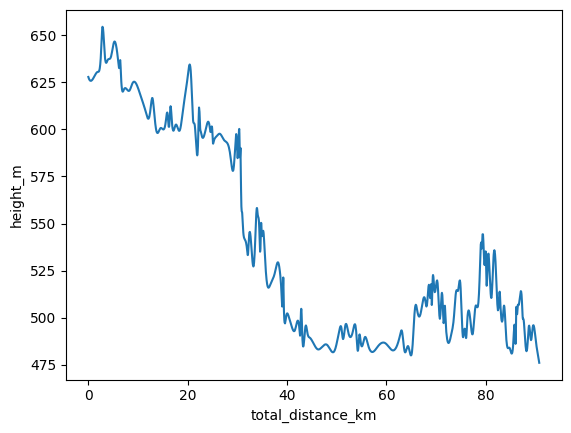

In [365]:
sns.lineplot(x=input_df['total_distance_km'].iloc[:2000], y=input_df['height_m'].iloc[:2000])

<Axes: xlabel='total_distance_km', ylabel='height_m'>

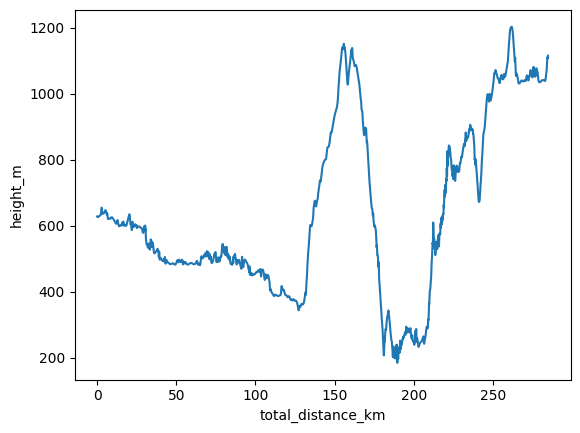

In [366]:
sns.lineplot(x=input_df['total_distance_km'], y=input_df['height_m'])

<Axes: xlabel='total_distance_km', ylabel='slope'>

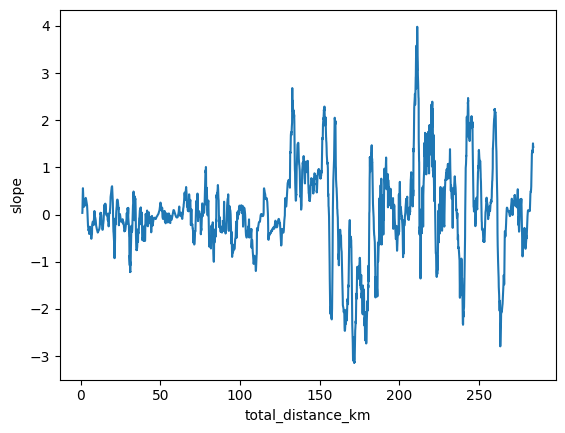

In [367]:
# Reviewing the 'steepness' of the track to see if that all makes sense
def smooth_data(df: pd.DataFrame, column_to_smooth: str, window_size: int = 5) -> pd.DataFrame:
    """
    Applies a running average (rolling mean) to a specified column in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_to_smooth (str): The name of the column to apply the smoothing to.
        window_size (int): The number of points to include in the running average.
                           Must be an odd number to be centered properly.

    Returns:
        pd.DataFrame: A new DataFrame with the smoothed data in a new column.
    """
    if column_to_smooth not in df.columns:
        raise ValueError(f"Column '{column_to_smooth}' not found in the DataFrame.")

    # Ensure window_size is odd for proper centering
    if window_size % 2 == 0:
        window_size += 1

    # Calculate the running average
    smoothed_series = df[column_to_smooth].rolling(
        window=window_size,
        center=True
    ).mean()

    # Create a new DataFrame with the original data and the smoothed data
    smoothed_df = df.copy()
    smoothed_df[column_to_smooth] = smoothed_series

    return smoothed_df

input_df['slope'] = input_df['height_m'].diff()
input_df_slope = smooth_data(input_df, 'slope', window_size=51)
sns.lineplot(x=input_df_slope['total_distance_km'].iloc[:], y=input_df_slope['slope'].iloc[:])

#### Saving the input track with all distance and height data included

In [368]:
add_heights = True
# Save it, so we save on requests and can take it back from here
if add_heights:
    dataframe_to_txt(input_df, filename='input_track_' + name_track +'.txt', sep='\t', index=False, header=True, mode='w')

# for now commented out, as we do not want to do it always and not mess up what was there already

DataFrame written to 'input_track_TCR12_-_Start_to_P1_segment_2.txt' successfully.


In [369]:
# Read it back in case something goes wrong later
input_df = pd.read_csv('input_track_' + name_track +'.txt', sep='\t')

#### Add the kilometer location of each POI.

In [370]:
def add_distance_from_closest(df1, df2, closest_col='closest', distance_col='total_distance_km', new_col='distance_km'):
    """
    Adds a column to df2 containing the 'total_distance_km' from df1, based on the 'closest' column.

    Args:
        df1 (pd.DataFrame): The first DataFrame containing the 'total_distance_km' column.
        df2 (pd.DataFrame): The second DataFrame containing the 'closest' column.
        closest_col (str): The name of the column in df2 that corresponds to the index of df1.
        distance_col (str): The name of the column in df1 containing the distance values.
        new_col (str): The name of the new column to be added to df2.

    Returns:
        pd.DataFrame: df2 with the added distance column.
    """

    if closest_col not in df2.columns:
        raise ValueError(f"Column '{closest_col}' not found in df2.")
    if distance_col not in df1.columns:
        raise ValueError(f"Column '{distance_col}' not found in df1.")

    distances = []
    for index in df2[closest_col]:
        if index in df1.index:
            distances.append(df1.loc[index, distance_col])
        else:
            distances.append(np.nan)

    df2[new_col] = distances

    return df2

pois = add_distance_from_closest(input_df, pois)
print(pois.head())

         lat        lon               name            type            phone  \
0  62.572287  11.387914  Solheim pensjonat           hotel  +47 95 52 37 06   
1  62.574591  11.383617              Røros            town              NaN   
2  62.566522  11.375053        Extra Røros     supermarket              NaN   
3  62.566570  11.372560     Circle K Røros            fuel              NaN   
4  62.567450  11.352337     drinking_water  drinking_water              NaN   

                                       opening_hours population elevation  \
0                                                NaN        NaN       NaN   
1                                                NaN       3897       NaN   
2                  Mo-Sa 07:00-23:00; Su 10:00-23:00        NaN       NaN   
3  Mo-Fr 06:30-22:00, Sa 07:30-22:00, Su 09:00-22:00        NaN       NaN   
4                                                NaN        NaN       NaN   

   closest  demoted  average_opening_time  distance_km  
0    

#### Finding the important peaks and add them to the POIs

The top in the 'x' surrounding kilometers.

In [371]:
# We need to make sure that when the peak is found, we cancel out the search for 'x' kilometers
# When peak is less than 500m: 200km
# When peak is less than 1000m: 50km
# When peak is less than 2000m: 25km


height_track = input_df.copy()
height_track['old index']=input_df.index
peak_position = 0

while len(height_track)>1:
    idx_max_height = height_track['height_m'].idxmax(axis=0)
    max_height = height_track.loc[height_track['height_m'].idxmax(axis=0), 'height_m']

    peak_position = height_track.iloc[idx_max_height]["total_distance_km"]

    print(f"The maximum of the route is at location {idx_max_height} with a height of {max_height}m, after {peak_position}km.")

    # Add a row missing one column
    new_row = {"lat":height_track.iloc[idx_max_height]["latitude"],
              "lon":height_track.iloc[idx_max_height]["longitude"],
              "name": "Top of route", "type": "peak",
              "closest": height_track.iloc[idx_max_height]["old index"], # THIS IS WRONG: IT SHOULD NOT BE OF THE FILTERED (REDUCED DF, but FROM THE TOTAL ONE)
              "elevation": height_track.iloc[idx_max_height]["height_m"],
               "distance_km": peak_position}  # No "City"
    pois = pd.concat([pois, pd.DataFrame([new_row])], ignore_index=True).sort_values("closest")

    # eliminate the rest of the dataframe based on the setting above
    if max_height <500:
        threshold = 200
    elif max_height <1000:
       threshold = 50
    else:
       threshold = 25

    height_track = height_track[~height_track["total_distance_km"].between(peak_position - threshold, peak_position + threshold)].reset_index(drop=True)


The maximum of the route is at location 6562 with a height of 1202.7214662870244m, after 261.8567699896366km.
The maximum of the route is at location 3395 with a height of 1151.0539094115925m, after 155.8663619220538km.
The maximum of the route is at location 4349 with a height of 905.564735299146m, after 235.6762316087576km.
The maximum of the route is at location 71 with a height of 654.533683883332m, after 2.846026507674802km.
The maximum of the route is at location 541 with a height of 544.3095941361992m, after 79.35134530511583km.
The maximum of the route is at location 24 with a height of 372.3264223547231m, after 130.86264454348438km.


In [372]:
print(pois.loc[pois['name']=='Top of route'])

          lat       lon          name  type phone opening_hours population  \
5    62.56685  11.34265  Top of route  peak   NaN           NaN        NaN   
24   62.09134  10.67540  Top of route  peak   NaN           NaN        NaN   
123  61.73902  10.77122  Top of route  peak   NaN           NaN        NaN   
37   61.63675  10.43934  Top of route  peak   NaN           NaN        NaN   
95   61.51924   9.38505  Top of route  peak   NaN           NaN        NaN   
114  61.39115   9.13230  Top of route  peak   NaN           NaN        NaN   

       elevation  closest  demoted  average_opening_time  distance_km  
5     654.533684     71.0      NaN                   NaN     2.846027  
24    544.309594   1768.0      NaN                   NaN    79.351345  
123   372.326422   2679.0      NaN                   NaN   130.862645  
37   1151.053909   3395.0      NaN                   NaN   155.866362  
95    905.564735   5744.0      NaN                   NaN   235.676232  
114  1202.721466   65

#### Calculate and add the ranking score for the POIs
Which are the most interesting places to stop?

In [373]:
# We chose fuel > convenience > supermarket > restaurant
# Simple idea: the different categories get a score: 4, 3, 2, 1 and we multiple with the amount of opening hours. If there are no opening hours present, we choose e.g. 40/7 hours or the minimum of the others of that category


def get_ranking_score(row_type, row_average_opening, row_population, row_elevation, row_demoted, df):
    type_mapping = {'convenience': 4, 'grocery': 3, 'supermarket': 4, 'kiosk': 1.5, 'bakery':1.5, 'restaurant': 1, 'drinking_water': 0.5, 'pub': 0.75, 'hotel': 0.75}

    #print(row_type)

    try:
        type_rank = type_mapping[row_type]
    except:
        if row_type == "town":
            return float(row_population)/4
        elif row_type == "peak":
            return float(row_elevation)/10
        elif row_type == "fuel" and row_demoted == 0:
            type_rank = 2.5 # 5  # Fuel made less important in Spain and France, as it is often not open or there is no food
        elif row_type == "fuel" and row_demoted == 1:
            type_rank = 0.75
        else:
            type_rank = 0.5 # Low rank in case it is not in the type_mapping, like the hotels

    if (row_average_opening != row_average_opening) & (row_type != "town"): # Easiest way to check if a value is nan is to check if it is equal to itself
        row_average_opening = (df[df['type']==row_type]['average_opening_time'].min()+df[df['type']==row_type]['average_opening_time'].mean())/2
    if (row_average_opening != row_average_opening): # Still nan, e.g. none of the location had a opening time (e.g. the case for drinking sources or hotels)
        row_average_opening = 1

    return type_rank*row_average_opening

pois['rank'] = pois.apply(lambda row: get_ranking_score(row['type'], row['average_opening_time'],row['population'], row['elevation'], row['demoted'],pois), axis=1)
# We need to add special landmarks still, like bigger cities and peaks, those would need a high ranking
pois = pois.sort_values(by=['distance_km'], ascending=True).reset_index(drop=True)


In [374]:
pois.sort_values(by=['rank'], ascending=False).head(20)

,lat,lon,name,type,phone,opening_hours,population,elevation,closest,demoted,average_opening_time,distance_km,rank
1,62.574591,11.383617,Røros,town,NaN,NaN,3897,NaN,3.0,NaN,NaN,0.033612,974.250000
19,62.274291,10.776868,Tynset,town,NaN,NaN,3067,NaN,1225.0,NaN,NaN,52.775770,766.750000
78,61.596491,9.736191,Vinstra,town,NaN,NaN,2727,NaN,4870.0,NaN,NaN,207.092426,681.750000
43,61.529565,10.138854,Ringebu,town,NaN,NaN,1442,NaN,4110.0,NaN,NaN,181.258961,360.500000
23,62.108567,10.633113,Alvdal,town,NaN,NaN,849,NaN,1665.0,NaN,NaN,76.040140,212.250000
8,62.496396,11.223311,Os,town,NaN,NaN,683,NaN,277.0,NaN,NaN,13.843491,170.750000
15,62.409448,10.996988,Tolga,town,NaN,NaN,637,NaN,743.0,NaN,NaN,31.627271,159.250000
55,61.555260,9.940352,Hundorp,town,NaN,NaN,606,NaN,4502.0,NaN,NaN,193.635148,151.500000
113,61.393448,9.142393,hill,peak,NaN,NaN,NaN,1207.0,6549.0,NaN,NaN,261.290269,120.700000
114,61.393448,9.142393,hill,peak,NaN,NaN,NaN,1207,6549.0,NaN,NaN,261.290269,120.700000


In [375]:
pois.sort_values(by=['rank'], ascending=False).tail(20)

,lat,lon,name,type,phone,opening_hours,population,elevation,closest,demoted,average_opening_time,distance_km,rank
49,61.548844,10.045259,Frya,town,NaN,NaN,NaN,NaN,4339.0,NaN,NaN,187.675747,NaN
53,61.553528,9.944933,Rundhaugen,town,NaN,NaN,NaN,NaN,4489.0,NaN,NaN,193.337735,NaN
54,61.553528,9.944933,Rundhaugen,peak,NaN,NaN,NaN,NaN,4489.0,NaN,NaN,193.337735,NaN
58,61.574864,9.904003,Kleberhaugen,peak,NaN,NaN,NaN,NaN,4603.0,NaN,NaN,196.829856,NaN
59,61.574864,9.904003,Kleberhaugen,town,NaN,NaN,NaN,NaN,4603.0,NaN,NaN,196.829856,NaN
60,61.576553,9.896844,Kjempehaugen,town,NaN,NaN,NaN,NaN,4611.0,NaN,NaN,197.123650,NaN
61,61.576553,9.896844,Kjempehaugen,peak,NaN,NaN,NaN,NaN,4611.0,NaN,NaN,197.123650,NaN
63,61.573608,9.883350,Gryttingshaugen,peak,NaN,NaN,NaN,NaN,4629.0,NaN,NaN,197.920360,NaN
64,61.573608,9.883350,Gryttingshaugen,town,NaN,NaN,NaN,NaN,4629.0,NaN,NaN,197.920360,NaN
65,61.570368,9.876304,village,town,NaN,NaN,NaN,NaN,4642.0,NaN,NaN,198.213988,NaN


In [376]:
pois[pois['type']=="fuel"].sort_values(by=['rank'], ascending=False)

,lat,lon,name,type,phone,opening_hours,population,elevation,closest,demoted,average_opening_time,distance_km,rank
21,62.111181,10.626602,St1 Alvdal,fuel,NaN,24/7,NaN,NaN,1652.0,0.0,24.0,75.484707,60.000
3,62.566570,11.372560,Circle K Røros,fuel,NaN,"Mo-Fr 06:30-22:00, Sa 07:30-22:00, Su 09:00-22:00",NaN,NaN,42.0,0.0,15.0,1.252955,37.500
75,61.593287,9.757232,YX Vinstra,fuel,NaN,"Mo-Fr 07:00-20:00, Sa 08:00-18:00, Su 09:00-20:00",NaN,NaN,4823.0,0.0,12.3,205.515931,30.750
9,62.497791,11.223096,Best Os i Østerdalen (automat),fuel,NaN,NaN,NaN,NaN,277.0,1.0,NaN,13.843491,11.025
33,61.835228,10.886188,Esso Express Hanestad,fuel,NaN,NaN,NaN,NaN,2415.0,1.0,NaN,115.143472,11.025
57,61.561014,9.937221,Circle K Automat Sør-Fron,fuel,NaN,NaN,NaN,NaN,4527.0,1.0,NaN,194.334679,11.025
76,61.594206,9.753015,Circle K Automat Vinstra,fuel,NaN,NaN,NaN,NaN,4827.0,1.0,NaN,205.767678,11.025
95,61.524167,9.406350,Bunker Oil Skåbu,fuel,NaN,NaN,NaN,NaN,5710.0,1.0,NaN,234.352426,11.025


#### Define the track steps

Great! We have ranking and it seems to be quite ok. For the POIs we will of course not use the towns as they are already there, we will use the ones that are not towns. To make the step sheet however, they are important.

Now we need to make two output:

1.   List with the most important POIs to add as points in the gps. Not that there is a maximum of 200 points for the whole route!
2.   The stepsheet dividing the route in manageable parts of e.g 15-30km

Let's start with the stepsheet, which is probably more complicated to get it right. The logic here would be to start from the highest priority location and then add the next points one by one, as long as they are not too close to points already in the list. If there are no gaps anymore more than 'x' kilometers and no points are closer than 'y' kilometers, we should have a good final list.


Final code (assuming that not only bigger towns can be interesting to stop).

In [377]:
minimum_distance_between_pois = 15

rolling_distance = 3 # km

In [378]:
# pois.loc[pois['name']=='Top of route']

The highest rank of the route is at location 1 with a rank of 1074.9168058420396, after 0.0km.
The highest rank of the route is at location 67 with a rank of 901.0921065130087, after 206.3km.
The highest rank of the route is at location 7 with a rank of 868.3000000000001, after 52.7km.
The highest rank of the route is at location 26 with a rank of 498.7, after 181.0km.
The highest rank of the route is at location 46 with a rank of 411.0, after 250.3km.
The highest rank of the route is at location 41 with a rank of 326.9, after 277.2km.
The highest rank of the route is at location 7 with a rank of 308.65, after 75.5km.
The highest rank of the route is at location 19 with a rank of 307.8, after 228.2km.
The highest rank of the route is at location 4 with a rank of 213.6, after 31.3km.
The highest rank of the route is at location 7 with a rank of 160.2, after 144.5km.
The highest rank of the route is at location 0 with a rank of 94.6, after 92.2km.
The highest rank of the route is at loca

<Axes: xlabel='distance_km', ylabel='rank'>

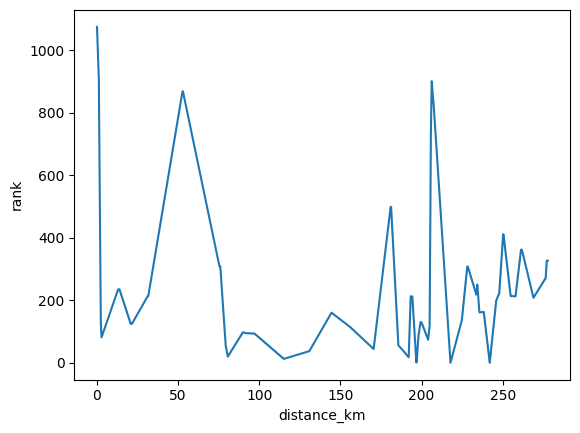

In [379]:
import math


def get_peaks_ranks(pois_remaining, minimum_distance_between_pois):
    poi_position = 0
    poi_stepsheet = pd.DataFrame(columns =  pois_remaining.columns)
    while len(pois_remaining)>1: # Run until we have no pois left in the list
        # Select the poi with the highest remaining rank
        idx_max_rank = pois_remaining['rank'].idxmax(axis=0)
        max_rank = pois_remaining.loc[pois_remaining['rank'].idxmax(axis=0), 'rank']

        poi_position = pois_remaining.iloc[idx_max_rank]["distance_km"]

        print(f"The highest rank of the route is at location {idx_max_rank} with a rank of {max_rank}, after {round(poi_position, 1)}km.")

        # Add the row to the poi_stepsheet
        poi_stepsheet = pd.concat([poi_stepsheet, pois_remaining.iloc[idx_max_rank].to_frame().T], ignore_index=True)

        # eliminate the rest of the dataframe based on the setting above
        pois_remaining = pois_remaining[~pois_remaining["distance_km"].between(poi_position - minimum_distance_between_pois, poi_position + minimum_distance_between_pois)].reset_index(drop=True)

    poi_stepsheet = poi_stepsheet.sort_values(by=['distance_km'], ascending=True)

    # If the start or finish is closer than the minimum distance/2 to a point, we replace it, we need to do the same for all other steps that are too close
    start_index = input_df.index[0]
    end_index =input_df.index[-1]
    too_close_to_start = False
    too_close_to_end = False

    for index, row in poi_stepsheet.iterrows():
      if row['distance_km'] < minimum_distance_between_pois / 2:
          too_close_to_start = True
          poi_stepsheet.loc[index, 'distance_km'] = 0
          poi_stepsheet.loc[index, 'lat'] = input_df.loc[start_index, 'latitude']
          poi_stepsheet.loc[index, 'lon'] = input_df.loc[start_index, 'longitude']
          poi_stepsheet.loc[index, 'name'] = "Start"
          poi_stepsheet.loc[index, 'closest'] = 0
          poi_stepsheet.loc[index, 'type'] = 'CP' # Control Point
          poi_stepsheet.loc[index, 'elevation'] = input_df.loc[start_index, 'height_m']
      if row['distance_km'] >input_df.loc[end_index, 'total_distance_km'] - minimum_distance_between_pois/2:
          too_close_to_end = True
          poi_stepsheet.loc[index, 'distance_km'] = input_df.loc[end_index, 'total_distance_km']
          poi_stepsheet.loc[index, 'lat'] = input_df.loc[end_index, 'latitude']
          poi_stepsheet.loc[index, 'lon'] = input_df.loc[end_index, 'longitude']
          poi_stepsheet.loc[index, 'name'] = "Finish"
          poi_stepsheet.loc[index, 'closest'] = end_index
          poi_stepsheet.loc[index, 'type'] = 'CP'
          poi_stepsheet.loc[index, 'elevation'] = input_df.loc[end_index, 'height_m']

    if not too_close_to_start: # if not the case: add a start row
          start_row = {'lat':input_df.loc[0, 'latitude'],
                          'lon':input_df.loc[0, 'longitude'],
                          'name':'Start', 'type':'CP',
                          'phone':np.nan, 'opening_hours':np.nan,
                          'population': np.nan, 'elevation': np.nan,
                          'closest':0, 'average_opening_time':np.nan,
                          'distance_km':0,
                          'rank':100000}
          poi_stepsheet = pd.concat([poi_stepsheet, pd.DataFrame([start_row])], ignore_index=True).sort_values("closest")
    if not too_close_to_end: # if not the case: add an end row
        end_row = {'lat':input_df.loc[input_df.index[-1],'latitude'],
                        'lon':input_df.loc[input_df.index[-1],'longitude'],
                        'name':'Finish', 'type':'CP',
                        'phone':np.nan, 'opening_hours':np.nan,
                        'population': np.nan, 'elevation': np.nan,
                        'closest':input_df.index[-1], 'average_opening_time':np.nan,
                        'distance_km':input_df.loc[input_df.index[-1], 'total_distance_km'],
                        'rank':100000}
        poi_stepsheet = pd.concat([poi_stepsheet, pd.DataFrame([end_row])], ignore_index=True).sort_values("closest")


    poi_stepsheet = poi_stepsheet.reset_index(drop=True)
    poi_stepsheet = poi_stepsheet.drop(columns=['phone', 'opening_hours', 'average_opening_time'])

    return poi_stepsheet

def create_rolling_sum_df(pois_remaining):
    """
    Creates a dataframe with distance_km and rolling average of rank.

    Args:
        pois_remaining (pd.DataFrame): DataFrame with 'rank' and 'distance_km' columns.

    Returns:
        pd.DataFrame: DataFrame with distance_km and rolling average of rank.
    """

    max_distance = int(pois_remaining['distance_km'].max())
    distances = np.arange(0, max_distance + 1)
    rolling_sum_ranks = []

    for distance in distances:
        # Filter the DataFrame for distances less than or equal to the current distance
        filtered_df = pois_remaining[(pois_remaining['distance_km'] < distance + rolling_distance/2) & (pois_remaining['distance_km'] > distance-rolling_distance/2)]

        if not filtered_df.empty:
            # Calculate the average rank for the filtered data
            sum_rank = filtered_df['rank'].sum()
            rolling_sum_ranks.append(sum_rank)
        else:
            # Handle the case where there's no data for the current distance (e.g., set to NaN or 0)
            rolling_sum_ranks.append(0)

    result_df = pd.DataFrame({'distance_km': distances, 'rolling_sum_rank': rolling_sum_ranks})

    # Interpolate the rolling sum onto the original distance_km values
    interpolated_ranks = np.interp(pois_remaining['distance_km'], result_df['distance_km'], result_df['rolling_sum_rank'])

    # Replace the 'rank' column in the original DataFrame
    pois_remaining['rank'] = interpolated_ranks

    return pois_remaining


def replace_rows_by_closest_distance(poi_stepsheet, pois_corrected):
    """
    Replaces rows in poi_stepsheet (excluding 'CP', 'town', 'peak' types)
    with the closest 'peak' or 'town' row from pois_corrected based on 'distance_km'.

    Args:
        poi_stepsheet_2 (pd.DataFrame): DataFrame to be modified.
        pois_corrected (pd.DataFrame): DataFrame to look up replacement rows.

    Returns:
        pd.DataFrame: Modified poi_stepsheet_2 DataFrame.
    """

    # Create a copy to avoid modifying the original DataFrame directly
    poi_stepsheet_modified = poi_stepsheet.copy()

    # Define types to keep
    types_to_keep = ['CP', 'town', 'peak']

    # Identify rows to replace
    rows_to_replace_indices = poi_stepsheet_modified[(~poi_stepsheet_modified['type'].isin(types_to_keep)) | (poi_stepsheet_modified['name'].isna())].index

    #print(poi_stepsheet)
    print('rows to replace indices:')
    print(rows_to_replace_indices)
    # Filter pois_corrected for 'peak' or 'town' types
    eligible_rows = pois_corrected[
        (pois_corrected['type'].isin(['peak', 'town'])) &
        (~pois_corrected['name'].isna())  # Check for not NaN name
    ]
    print("the eligible rows are (town or peak):")
    print(eligible_rows)

    for index in rows_to_replace_indices:
        # Get the distance_km of the row to replace
        target_distance = poi_stepsheet_modified.loc[index, 'distance_km']
        print(target_distance)

        if not eligible_rows.empty:
            # Find the row with the closest distance
            closest_index = (eligible_rows['distance_km'] - target_distance).abs().idxmin()
            closest_row = eligible_rows.loc[closest_index]

            # Replace the row in poi_stepsheet_modified
            poi_stepsheet_modified.loc[index] = closest_row

    # --- Deduplication Step ---
    # # Determine the best subset for deduplication
    # if 'id' in poi_stepsheet_modified.columns and poi_stepsheet_modified['id'].notna().any():
    #     # Prefer 'id' if it's available and has unique values
    #     poi_stepsheet_modified.drop_duplicates(subset=['id'], inplace=True)
    #     print("Deduplicated using 'id' column.")
    # elif 'lat' in poi_stepsheet_modified.columns and 'lon' in poi_stepsheet_modified.columns:
    #     # Fallback to 'lat' and 'lon' if 'id' is not suitable
    #     poi_stepsheet_modified.drop_duplicates(subset=['lat', 'lon'], inplace=True)
    #     print("Deduplicated using 'lat' and 'lon' columns.")
    # else:
    #     # As a last resort, drop duplicates on all columns, which might be too strict
    #     poi_stepsheet_modified.drop_duplicates(inplace=True)
    #     print("Deduplicated using all columns (less ideal for POI data).")

    return poi_stepsheet_modified.reset_index(drop=True)

# Copy the pois
pois_remaining = pois.copy()
#print(pois_remaining.loc[pois_remaining['name']=='Top of route'])

poi_stepsheet = pd.DataFrame(columns =  pois_remaining.columns)
rolling_sum_df = create_rolling_sum_df(pois_remaining)

#print(rolling_sum_df.loc[rolling_sum_df['name']=='Top of route'])

#print("The locations with the peak rolling ranks are:")
poi_stepsheet = get_peaks_ranks(rolling_sum_df, minimum_distance_between_pois)
#print(poi_stepsheet)

# We will of course have maxima on the strangest places (like shops and drinking sources) due to this rolling sum. We need to fix that by replacing each point that is not CP, peak or town by the closest one.
pois_corrected = pois.drop(columns=['phone', 'opening_hours', 'average_opening_time'])

#print("Replacing these peak rolling ranks by a location more meaningful:")
poi_stepsheet = replace_rows_by_closest_distance(poi_stepsheet, pois_corrected)
print(poi_stepsheet)

sns.lineplot(x=rolling_sum_df['distance_km'], y=rolling_sum_df['rank'])

In [380]:
poi_stepsheet

,lat,lon,name,type,population,elevation,closest,demoted,distance_km,rank
0,62.57191,11.38788,Start,CP,3897,627.871314,0,NaN,0,1074.916806
1,62.409448,10.996988,Tolga,town,637,NaN,743.0,NaN,31.627271,159.25
2,62.274291,10.776868,Tynset,town,3067,NaN,1225.0,NaN,52.77577,766.75
3,62.108567,10.633113,Alvdal,town,849,NaN,1665.0,NaN,76.04014,212.25
4,62.017358,10.837514,hill,peak,NaN,473.0,2019.0,NaN,92.150054,94.6
5,61.73902,10.77122,Top of route,peak,NaN,372.326422,2679.0,NaN,130.862645,37.232642
6,61.691251,10.580179,hill,peak,NaN,801,3074.0,NaN,144.529812,160.2
7,61.529565,10.138854,Ringebu,town,1442,NaN,4110.0,NaN,181.258961,360.5
8,61.596491,9.736191,Vinstra,town,2727,NaN,4870.0,NaN,207.092426,681.75
9,61.561976,9.466031,hill,peak,NaN,770,5537.0,NaN,228.186657,307.8


#### Finalize the stepsheet with the missing data and eliminate the unnecessary ones

We make the stepsheet. We need the following columns:

*   Number
*   Name
*   Resupply possible?
*   Hotel
*   Bike shop (maybe to be added later)
*   km for step
*   hm for step
*   dm for step
*   hm/km for step
*   profile for step
*   total km
*   total hm



In [381]:
def add_height_dm_hm(poi_stepsheet, input_df):
    """
    Adds 'height_m', 'dm', and 'hm' columns from input_df to poi_stepsheet based on the 'closest' column.

    Args:
        poi_stepsheet (pd.DataFrame): The DataFrame to which columns will be added.
        input_df (pd.DataFrame): The DataFrame containing the 'height_m', 'dm', and 'hm' columns.

    Returns:
        pd.DataFrame: The poi_stepsheet DataFrame with added columns.
    """

    poi_stepsheet['height_m'] = poi_stepsheet['closest'].apply(lambda x: input_df.loc[x, 'height_m'] if x in input_df.index else None).astype(int)
    poi_stepsheet['hm_total'] = (round(poi_stepsheet['closest'].apply(lambda x: input_df.loc[x, 'hm'] if x in input_df.index else None)/10)*10).astype(int)
    poi_stepsheet['dm_total'] = (round(poi_stepsheet['closest'].apply(lambda x: input_df.loc[x, 'dm'] if x in input_df.index else None)/10)*10).astype(int)
    poi_stepsheet = poi_stepsheet.infer_objects(copy=False) #added line
    poi_stepsheet['km_step'] = poi_stepsheet['distance_km'].diff().fillna(0)
    poi_stepsheet = poi_stepsheet.infer_objects(copy=False) #added line
    poi_stepsheet['hm_step'] = poi_stepsheet['hm_total'].diff().fillna(0)
    poi_stepsheet['dm_step'] = poi_stepsheet['dm_total'].diff().fillna(0)
    poi_stepsheet['hm/km_step'] = round((poi_stepsheet['hm_step'] / poi_stepsheet['km_step']).fillna(0)*10)/10
    # Rounding the numbers that we need to round still
    poi_stepsheet['km_step'] = round(poi_stepsheet['km_step']*2)/2
    poi_stepsheet['distance_km'] = round(poi_stepsheet['distance_km']*2)/2
    poi_stepsheet['hm_step'] = (round(poi_stepsheet['hm_step']/10)*10).astype(int)
    poi_stepsheet['dm_step'] = (round(poi_stepsheet['dm_step']/10)*10).astype(int)


    return poi_stepsheet

poi_stepsheet = add_height_dm_hm(poi_stepsheet, input_df)

In [382]:
# poi_stepsheet

We still need to add the indication for food (or hotels, or bike shops,...) on the way and eliminate the information that is not important.


In [383]:
pois_shop = pois[(pois['type']== 'supermarket') | (pois['type']== 'convenience') | (pois['type']== 'fuel') | (pois['type']== 'bakery') | (pois['type']== 'kiosk') | (pois['type']== 'supermarket') | (pois['type']== 'restaurant') | (pois['type']== 'pub') | (pois['type']== 'drinking_water') ].reset_index(drop=True)
in_town_threshold = 3 #km
out_of_town_default = 15 #km

def additional_string(df):
    additional_string = ""
    # Any 24/7 gas station?
    if ((df['type'] == 'fuel') & (df['average_opening_time'] == 24)&(df['demoted'] != 1)).any():
        additional_string = " (G24)"
    else:
        # Check if there is any fuel location in this part
        if (df['type'].isin(['fuel']) & (df['demoted'] != 1)).any():
            additional_string = " (G)"
        # Check if there is any 24/7 location in this part (e.g. fuel)
        elif ((df['average_opening_time'] == 24) & (df['demoted'] != 1)).any():
            additional_string = " (24)"

    return additional_string

def add_shops_to_stepsheet(poi_stepsheet, pois_shop, in_town_threshold):
    poi_stepsheet["food_at_location"] = '-'
    poi_stepsheet["food_on_way"] = '-'

    for i in range(len(poi_stepsheet)):
        # The amount of food locations within +- the threshold of that location
        location_food = pois_shop[(pois_shop['distance_km']<poi_stepsheet.loc[i, 'distance_km']+in_town_threshold) & (pois_shop['distance_km']>poi_stepsheet.loc[i, 'distance_km']-in_town_threshold)]
        add_string = additional_string(location_food)

        # Food at location
        if location_food['rank'].sum() >= 100:
            poi_stepsheet.loc[i, "food_at_location"] = "***" + add_string
        elif location_food['rank'].sum() >= 50:
            poi_stepsheet.loc[i, "food_at_location"] = "**" + add_string
        elif location_food['rank'].sum() >= 10:
            poi_stepsheet.loc[i, "food_at_location"] = "*" + add_string

        # The amount of food on the way to the location --> This should be corrected for the length of this section!! If there is a long section,
        # there is more chance on things, but as it is spread over a longer distance this is not necessarily a good thing.
        if i !=0:
            on_way_food = pois_shop[(pois_shop['distance_km']>poi_stepsheet.loc[i-1, 'distance_km']+in_town_threshold) & (pois_shop['distance_km']<poi_stepsheet.loc[i, 'distance_km']-in_town_threshold)]
            section_length = poi_stepsheet.loc[i, 'distance_km'] - poi_stepsheet.loc[i-1, 'distance_km'] - 2*in_town_threshold
            add_string = additional_string(on_way_food)
            # We take
            # Food on the way
            if on_way_food['rank'].sum()*out_of_town_default/section_length >= 100:
                poi_stepsheet.loc[i, "food_on_way"] = "***" + add_string
            elif on_way_food['rank'].sum()*out_of_town_default/section_length >= 50:
                poi_stepsheet.loc[i, "food_on_way"] = "**" + add_string
            elif on_way_food['rank'].sum()*out_of_town_default/section_length >= 10:
                poi_stepsheet.loc[i, "food_on_way"] = "*" + add_string

    return poi_stepsheet

poi_stepsheet = add_shops_to_stepsheet(poi_stepsheet, pois_shop, in_town_threshold)
poi_stepsheet = poi_stepsheet[['lat','lon','type','name','food_at_location','food_on_way','km_step','hm_step','dm_step','hm/km_step','height_m','distance_km','hm_total']]

In [384]:
pois_shop.iloc[:50]

,lat,lon,name,type,phone,opening_hours,population,elevation,closest,demoted,average_opening_time,distance_km,rank
0,62.566522,11.375053,Extra Røros,supermarket,NaN,Mo-Sa 07:00-23:00; Su 10:00-23:00,NaN,NaN,40.0,NaN,15.6,1.187728,62.400
1,62.566570,11.372560,Circle K Røros,fuel,NaN,"Mo-Fr 06:30-22:00, Sa 07:30-22:00, Su 09:00-22:00",NaN,NaN,42.0,0.0,15.0,1.252955,37.500
2,62.567450,11.352337,drinking_water,drinking_water,NaN,NaN,NaN,NaN,60.0,NaN,NaN,2.397297,0.500
3,62.497848,11.237424,Trollkroa,restaurant,NaN,NaN,NaN,NaN,251.0,NaN,NaN,12.994767,7.950
4,62.496007,11.223974,Spar Os,supermarket,NaN,"Mo-Fr 08:00-21:00, Sa 09:00-19:00, Su 12:00-17:00",NaN,NaN,276.0,NaN,11.4,13.757640,45.600
5,62.497791,11.223096,Best Os i Østerdalen (automat),fuel,NaN,NaN,NaN,NaN,277.0,1.0,NaN,13.843491,11.025
6,62.411034,10.991722,Malmplassen Gjestegård,restaurant,NaN,NaN,NaN,NaN,740.0,NaN,NaN,31.331565,7.950
7,62.409644,10.998567,Coop Prix Tolga,supermarket,NaN,Mo-Fr 08:00-22:00; Sa 09:00-20:00,NaN,NaN,744.0,NaN,11.6,31.640596,46.400
8,62.274717,10.776392,Mix Tynset,convenience,NaN,Mo-Th 10:00-21:00; Fr-Sa 10:00-22:00; Su 12:00...,NaN,NaN,1224.0,NaN,11.0,52.725212,44.000
9,62.274030,10.777597,restaurant,restaurant,NaN,NaN,NaN,NaN,1225.0,NaN,NaN,52.775770,7.950


In [385]:
poi_stepsheet

,lat,lon,type,name,food_at_location,food_on_way,km_step,hm_step,dm_step,hm/km_step,height_m,distance_km,hm_total
0,62.571910,11.387880,CP,Start,*** (G),-,0.0,0,0,0.0,627,0.0,0
1,62.409448,10.996988,town,Tolga,**,*,31.5,210,290,6.6,540,31.5,210
2,62.274291,10.776868,town,Tynset,***,-,21.0,150,210,7.1,489,53.0,360
3,62.108567,10.633113,town,Alvdal,** (G24),-,23.5,180,180,7.7,489,76.0,540
4,62.017358,10.837514,peak,hill,-,-,16.0,240,260,14.9,476,92.0,780
5,61.739020,10.771220,peak,Top of route,-,-,38.5,210,310,5.4,372,131.0,990
6,61.691251,10.580179,peak,hill,-,-,13.5,470,30,34.4,800,144.5,1460
7,61.529565,10.138854,town,Ringebu,***,*,36.5,550,1140,15.0,213,181.5,2010
8,61.596491,9.736191,town,Vinstra,*** (G),**,26.0,620,580,24.0,257,207.0,2630
9,61.561976,9.466031,peak,hill,-,-,21.0,1110,610,52.6,762,228.0,3740


#### Add the height data for the sparkline for easier implementation and use in excel

We will for each section interpolate the height profile over 50 points and just add these in the columns to the right of the stepsheet. In the final excel version these will just be used for the sparklines.

In [386]:
# Initialize 50 new columns for the interpolated data in poi_stepsheet
interpolated_columns = [f'interpolated_height_{i}' for i in range(50)]
poi_stepsheet = poi_stepsheet.reindex(columns=poi_stepsheet.columns.tolist() + interpolated_columns, fill_value=np.nan)

# Create a list of distance intervals from the poi_stepsheet
distance_intervals = list(zip(
    poi_stepsheet['distance_km'].iloc[:-1],
    poi_stepsheet['distance_km'].iloc[1:]
))

# Loop through each interval and perform the interpolation
for i in tqdm(range(len(distance_intervals)), desc="Interpolating segments"):
    start_dist, end_dist = distance_intervals[i]

    # Define the 50 new points to interpolate for within this interval
    new_distances = np.linspace(start_dist, end_dist, 50)

    # Use numpy.interp to perform linear interpolation
    # It takes the points to interpolate for, the known x-values, and the known y-values.
    interpolated_heights = np.interp(
        new_distances,
        input_df['total_distance_km'],
        input_df['height_m']
    )

    # Assign the 50 values to the new columns in the correct row
    poi_stepsheet.loc[i, interpolated_columns] = interpolated_heights

# 1. Shift only the interpolated columns down by one row
poi_stepsheet[interpolated_columns] = poi_stepsheet[interpolated_columns].shift(1)

# 2. Set the new first row of these columns to all zeros
poi_stepsheet.loc[0, interpolated_columns] = 0

print("Interpolation for sparklines complete")

Interpolating segments:   0%|          | 0/12 [00:00<?, ?it/s]

Interpolation for sparklines complete


#### Save the stepsheet to a txt

This is what we are looking for in general. We can of course still change and expand it the way we want. We now save it, together with the height profile plot to make the height profile plots as well.

In [387]:
dataframe_to_txt(poi_stepsheet, filename='poi_stepsheet_'+ name_track +'.txt', sep='\t', index=False, header=True, mode='w')

DataFrame written to 'poi_stepsheet_TCR12_-_Start_to_P1_segment_2.txt' successfully.


#### Define the POIs that should be uploaded to the GPS

Not all of them should be added, as there are only 200 locations that you can upload to a Garmin device.

In [388]:
# TO ADJUST THESE VALUES CASE BY CASE!!!
total_length_route = 5000 # km
total_amount_pois = 180 # some margin from the 200

In [389]:
pois_shop.sort_values(by=['rank'], ascending=False)

,lat,lon,name,type,phone,opening_hours,population,elevation,closest,demoted,average_opening_time,distance_km,rank
0,62.566522,11.375053,Extra Røros,supermarket,NaN,Mo-Sa 07:00-23:00; Su 10:00-23:00,NaN,NaN,40.0,NaN,15.6,1.187728,62.400
16,61.530530,10.144702,Rema 1000 Ringebu,supermarket,NaN,"Mo-Sa 07:00-23:00, Su 09:00-21:00",NaN,NaN,4088.0,NaN,15.4,180.961795,61.600
11,62.111181,10.626602,St1 Alvdal,fuel,NaN,24/7,NaN,NaN,1652.0,0.0,24.0,75.484707,60.000
31,61.594917,9.732765,Rema 1000 Vinstra,supermarket,NaN,Mo-Sa 07:00-23:00,NaN,NaN,4876.0,NaN,13.7,207.266290,54.800
32,61.595819,9.729662,Kiwi Vinstra,supermarket,NaN,Mo-Sa 07:00-23:00,NaN,NaN,4882.0,NaN,13.7,207.429271,54.800
23,61.577845,9.858912,Kiwi Harpefoss,supermarket,NaN,"Mo-Fr 07:00-23:00, Sa 09:00-21:00",NaN,NaN,4681.0,NaN,13.1,199.523096,52.400
19,61.530471,10.141190,Extra Ringebu,supermarket,NaN,Mo-Fr 07:00-22:00; Sa 08:00-21:00,NaN,NaN,4110.0,NaN,12.6,181.258961,50.400
21,61.555637,9.939773,Coop Prix Sør-Fron,supermarket,NaN,Mo-Fr 07:00-22:00; Sa 09:00-21:00,NaN,NaN,4504.0,NaN,12.4,193.671863,49.600
10,62.272815,10.774672,Spar Tynset,supermarket,NaN,"Mo-Fr 07:00-22:00, Sa 08:00-20:00",NaN,NaN,1229.0,NaN,12.4,52.988639,49.600
7,62.409644,10.998567,Coop Prix Tolga,supermarket,NaN,Mo-Fr 08:00-22:00; Sa 09:00-20:00,NaN,NaN,744.0,NaN,11.6,31.640596,46.400


In [390]:
aim_interdistance = total_length_route/total_amount_pois
aim_interdistance=aim_interdistance*2 # Multiply by two, as we always try to add two POIs for each location (to have some redundancy in case of emergency or the first one being closed)

# Only the places with food or drinks are of importance here now, so we use pois_shop
pois_remaining = pois_shop[pois_shop['demoted'] != 1].copy().reset_index(drop=True)
poi_position = 0

poi_gps = pd.DataFrame(columns =  pois_remaining.columns)
max_rank = pois_remaining.loc[pois_remaining['rank'].idxmax(axis=0), 'rank']

# Provide information on how they were selected
print("The interdistance between gps POIs we aim at is:")
print(round(aim_interdistance,1))
print("The percentile cut_off of the POI ranks is:")
if pois_shop['rank'].quantile(0.7) < max_rank: # Sometimes there are many of the same rank and then the 70% percentile equals the maximum and no pois are kept
    percentile_cut_off= pois_shop['rank'].quantile(0.7)
else:
    percentile_cut_off= max_rank/2 # This rare case
print(round(percentile_cut_off,1))

while len(pois_remaining)>1 and max_rank>percentile_cut_off: # Run until we have no pois left in the list or until the rank of the added ones is too lower (the lower half of ranks)
    # Select the poi with the highest remaining rank
    idx_max_rank = pois_remaining['rank'].idxmax(axis=0)
    max_rank = pois_remaining.loc[pois_remaining['rank'].idxmax(axis=0), 'rank']

    poi_position = pois_remaining.iloc[idx_max_rank]["distance_km"]

    print(f"The most promising shop of the remaining route is after {round(poi_position,1)}km (rank of {round(max_rank,1)}).")

    # Add the row to the poi_gps
    poi_gps = pd.concat([poi_gps, pois_remaining.iloc[idx_max_rank].to_frame().T], ignore_index=True)

    # Find the second highest rank within the interdistance
    within_distance = pois_remaining.drop(idx_max_rank)  # Exclude the already selected highest rank

    if not within_distance.empty:
        idx_second_max_rank = within_distance['rank'].idxmax(axis=0)
        if not pd.isna(idx_second_max_rank): # Check if the second max exists.
            second_max_rank = within_distance.loc[idx_second_max_rank, 'rank']
            second_poi_position = within_distance.loc[idx_second_max_rank, "distance_km"]

            print(f"The spare one (second most promising) is after {round(second_poi_position,1)}km (rank of {round(second_max_rank,1)}).")

            # Add the second highest rank row to poi_gps
            poi_gps = pd.concat([poi_gps, within_distance.loc[idx_second_max_rank].to_frame().T], ignore_index=True)

            # Remove the second highest rank from pois_remaining
            pois_remaining = pois_remaining.drop(idx_second_max_rank).reset_index(drop=True)

    # Eliminate all pois within the interdistance
    pois_remaining = pois_remaining[~pois_remaining["distance_km"].between(poi_position - aim_interdistance / 2, poi_position + aim_interdistance / 2)].reset_index(drop=True)

poi_gps = poi_gps.sort_values(by=['distance_km'], ascending=True).reset_index(drop=True).drop(columns=['phone','elevation','population','closest'])



The interdistance between gps POIs we aim at is:
55.6
The percentile cut_off of the POI ranks is:
44.3
The most promising shop of the remaining route is after 1.2km (rank of 62.4).
The spare one (second most promising) is after 181.0km (rank of 61.6).
The most promising shop of the remaining route is after 75.5km (rank of 60.0).
The spare one (second most promising) is after 207.3km (rank of 54.8).
The most promising shop of the remaining route is after 207.4km (rank of 54.8).
The spare one (second most promising) is after 199.5km (rank of 52.4).
The most promising shop of the remaining route is after 31.6km (rank of 46.4).
The spare one (second most promising) is after 170.5km (rank of 44.0).


In [391]:
poi_gps

,lat,lon,name,type,opening_hours,demoted,average_opening_time,distance_km,rank
0,62.566522,11.375053,Extra Røros,supermarket,Mo-Sa 07:00-23:00; Su 10:00-23:00,NaN,15.6,1.187728,62.4
1,62.409644,10.998567,Coop Prix Tolga,supermarket,Mo-Fr 08:00-22:00; Sa 09:00-20:00,NaN,11.6,31.640596,46.4
2,62.111181,10.626602,St1 Alvdal,fuel,24/7,0.0,24.0,75.484707,60.0
3,61.559089,10.267275,Nærbutikken Måsåplassen,convenience,NaN,NaN,NaN,170.494359,44.0
4,61.53053,10.144702,Rema 1000 Ringebu,supermarket,"Mo-Sa 07:00-23:00, Su 09:00-21:00",NaN,15.4,180.961795,61.6
5,61.577845,9.858912,Kiwi Harpefoss,supermarket,"Mo-Fr 07:00-23:00, Sa 09:00-21:00",NaN,13.1,199.523096,52.4
6,61.594917,9.732765,Rema 1000 Vinstra,supermarket,Mo-Sa 07:00-23:00,NaN,13.7,207.26629,54.8
7,61.595819,9.729662,Kiwi Vinstra,supermarket,Mo-Sa 07:00-23:00,NaN,13.7,207.429271,54.8


In [392]:
dataframe_to_txt(poi_gps, filename='poi_gps_'+ name_track +'.txt', sep='\t', index=False, header=True, mode='w')

DataFrame written to 'poi_gps_TCR12_-_Start_to_P1_segment_2.txt' successfully.


#### Make the gpx file with POIs to upload to Mapy straight away

In [393]:
def generate_gpx_from_df(df, filename='mapy_waypoints.gpx'):
    """
    Generates a GPX file from a pandas DataFrame, correctly handling special characters and NaN values.

    Args:
        df (pd.DataFrame): The input DataFrame.
        filename (str): The name of the GPX file to be created.
    """
    gpx_content = '<?xml version="1.0" encoding="utf-8"?>\n'
    gpx_content += '<gpx xmlns="http://www.topografix.com/GPX/1/1" version="1.1" creator="https://mapy.com/">\n'

    df_filtered = df[~df['type'].isin(['town', 'peak'])].copy()

    for _, row in df_filtered.iterrows():
        lat = row['lat']
        lon = row['lon']
        original_name = str(row['name'])
        point_type = str(row['type'])
        phone = str(row['phone'])
        demoted = str(row['demoted'])
        avg_opening_time = str(row['average_opening_time'])

        prefix_map = {
            'fuel': 'G', 'restaurant': 'R', 'supermarket': 'S', 'hotel': 'H',
            'convenience': 'Sh', 'bakery': 'B', 'kiosk': 'K', 'pub': 'P',
            'drinking_water': 'D'
        }

        prefix = prefix_map.get(point_type, '')
        if point_type == 'fuel' and demoted == '1.0':
            prefix = 'G?'

        final_name = f'{prefix} - {original_name}'

        # Add additional information
        if point_type == 'hotel':
            info = f'({phone})' if pd.notna(row['phone']) else '(-)'
            final_name += f' {info}'
        elif point_type != 'drinking_water':
            info = f'({avg_opening_time})' if pd.notna(row['average_opening_time']) else '(-)'
            final_name += f' {info}'

        # Escape special characters for valid XML
        final_name = final_name.replace('&', '&amp;')
        final_name = final_name.replace('<', '&lt;')
        final_name = final_name.replace('>', '&gt;')
        final_name = final_name.replace('"', '&quot;')
        final_name = final_name.replace("'", '&apos;')

        wpt = f'\t<wpt lat="{lat}" lon="{lon}">\n\t\t<name>{final_name}</name>\n\t</wpt>\n'
        gpx_content += wpt

    gpx_content += '</gpx>'

    with open(filename, 'w', encoding='utf-8') as f:
        f.write(gpx_content)

    print(f'GPX file "{filename}" has been created and saved successfully.')

# Example of how to use the function with the sample DataFrame
gpx_output = generate_gpx_from_df(pois, filename='mapy_'+ name_track +'.gpx')

GPX file "mapy_TCR12_-_Start_to_P1_segment_2.gpx" has been created and saved successfully.


### Summary


In [394]:
folium_route(input_df["latitude"],
             input_df["longitude"],
             pois=pois,
             popup_func=lambda p,i: f"POI {i+1}: {p.loc[i,'name']} ({p.loc[i,'type']}) {p.loc[i,'phone'] if p.loc[i,'phone']==p.loc[i,'phone'] else ''}",
             width=200, height=150,
             save=True, save_name = name_track + "_map.html")

<Axes: xlabel='total_distance_km', ylabel='height_m'>

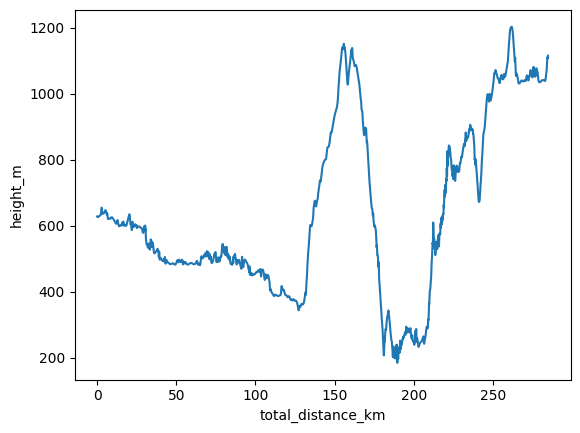

In [395]:
sns.lineplot(x=input_df['total_distance_km'], y=input_df['height_m'])

In [396]:
poi_stepsheet.iloc[:, :13]

,lat,lon,type,name,food_at_location,food_on_way,km_step,hm_step,dm_step,hm/km_step,height_m,distance_km,hm_total
0,62.571910,11.387880,CP,Start,*** (G),-,0.0,0,0,0.0,627,0.0,0
1,62.409448,10.996988,town,Tolga,**,*,31.5,210,290,6.6,540,31.5,210
2,62.274291,10.776868,town,Tynset,***,-,21.0,150,210,7.1,489,53.0,360
3,62.108567,10.633113,town,Alvdal,** (G24),-,23.5,180,180,7.7,489,76.0,540
4,62.017358,10.837514,peak,hill,-,-,16.0,240,260,14.9,476,92.0,780
5,61.739020,10.771220,peak,Top of route,-,-,38.5,210,310,5.4,372,131.0,990
6,61.691251,10.580179,peak,hill,-,-,13.5,470,30,34.4,800,144.5,1460
7,61.529565,10.138854,town,Ringebu,***,*,36.5,550,1140,15.0,213,181.5,2010
8,61.596491,9.736191,town,Vinstra,*** (G),**,26.0,620,580,24.0,257,207.0,2630
9,61.561976,9.466031,peak,hill,-,-,21.0,1110,610,52.6,762,228.0,3740


In [397]:
poi_gps

,lat,lon,name,type,opening_hours,demoted,average_opening_time,distance_km,rank
0,62.566522,11.375053,Extra Røros,supermarket,Mo-Sa 07:00-23:00; Su 10:00-23:00,NaN,15.6,1.187728,62.4
1,62.409644,10.998567,Coop Prix Tolga,supermarket,Mo-Fr 08:00-22:00; Sa 09:00-20:00,NaN,11.6,31.640596,46.4
2,62.111181,10.626602,St1 Alvdal,fuel,24/7,0.0,24.0,75.484707,60.0
3,61.559089,10.267275,Nærbutikken Måsåplassen,convenience,NaN,NaN,NaN,170.494359,44.0
4,61.53053,10.144702,Rema 1000 Ringebu,supermarket,"Mo-Sa 07:00-23:00, Su 09:00-21:00",NaN,15.4,180.961795,61.6
5,61.577845,9.858912,Kiwi Harpefoss,supermarket,"Mo-Fr 07:00-23:00, Sa 09:00-21:00",NaN,13.1,199.523096,52.4
6,61.594917,9.732765,Rema 1000 Vinstra,supermarket,Mo-Sa 07:00-23:00,NaN,13.7,207.26629,54.8
7,61.595819,9.729662,Kiwi Vinstra,supermarket,Mo-Sa 07:00-23:00,NaN,13.7,207.429271,54.8


TO DO:


*   Get the correct English names when the names are in cyrillic
*   Solve the height profile and absolute heights
*   Possiblity to add own specific coordinates to the pois_gps (like check points) and maybe force them to be step points as well
*   Add more data to the stars: if a 24/7 is there and if a gas station is there

DONE:

*   Correct that the hills are not seen as towns anymore
*   Review the way the stars are set and check if they make sense: maybe we should reduce the impact of 'in between' parts, as they are longer and you typically do not aim for them. If they are still high then, then we can set 3 stars (***)
*   Add x (x=50) columns to the stepsheet dataframe that contain the height profile data interpolated and ready to create sparklines in excel (*   Make the stepsheet right away with the sparklines as well in excel)



---



---



---



#### Stop the automatic running (not the obsolete functions)

In [ ]:
from google.colab import runtime
runtime.unassign()

## Obsolete functions (using the circles to get the many small overpass request

#### Code to find amenities in a radius of a location

In [ ]:
def fetch_osm_data():#lat, lon, radius_km):
    #radius_meters = radius_km * 1000
    overpass_url = "http://overpass-api.de/api/interpreter"
    lat = 42.922464736580515
    lon = 22.93046265711568
    radius_meters = 20000
    overpass_query = f"""
    [out:json];
    (
     node["place"="town"](around:{radius_meters},{lat},{lon});
     node["place"="city"](around:{radius_meters},{lat},{lon});
    );
    out;
    """
    # overpass_query = f"""
    # [out:json];
    # (
    #  node["place"="town"](around:{radius_meters},{lat},{lon});
    #  node["place"="city"](around:{radius_meters},{lat},{lon});
    #  node["place"="village"](around:{radius_meters},{lat},{lon});
    # );
    # out;
    # """
    # overpass_query = f"""
    # [out:json][timeout:25];
    # // gather results
    # (
    #   // query part for: “name=Bayreuth”
    #   node["name"="Тетово"][place]->.a;
    #   nwr(around.a:20000)["place"="city"];
    #   nwr(around.a:20000)["place"="town"];
    #   nwr(around.a:20000)["place"="village"];
    # );
    # // print results
    # out body;
    # """
    # nwr(around.a:20000)[amenity=parcel_locker];
    # parcel_locker # fuel
    response = requests.get(overpass_url, params={'data': overpass_query})
    if response.status_code != 200:
        return None
    data = response.json()
    return data['elements']

if __name__ == "__main__":
    to_run = True
    if to_run == True:
        #lat = float(input("Enter latitude: "))
        #lon = float(input("Enter longitude: "))
        #radius_km = float(input("Enter radius in kilometers: "))

        osm_data = fetch_osm_data()#lat, lon, radius_km)
        counter = 1
        columns = ['name', 'lat', 'lon']
        df_boxes = pd.DataFrame(columns=columns)

        if not osm_data:
            print("Failed to fetch data or no places found.")
        else:
            print(f"Places within Brno:")
            #print(f"Places within {radius_km} km:")
            for element in osm_data:
              try:
                place_name = element.get('tags', {}).get('name', 'Unknown')
                place_coord = (element['lat'], element['lon'])
                #distance = geodesic((lat, lon), place_coord).kilometers
                #print(f"{place_name} ({distance:.2f} km)")
                print(f"{counter}: {place_name} {place_coord}")
                df_boxes.loc[len(df_boxes)] = {'name': place_name, 'lat': element['lat'], 'lon': element['lon']}
                counter +=1
              except:
                print("error for this place")

        figure1 = px.scatter_mapbox(df_boxes,
                            lat="lat",
                            lon="lon",
                            hover_data= {
                                "name": True,
                                "lat": True,
                                "lon": True
                            },
                            #color="color",
                            #color_continuous_scale=color_scale,
                            #size="size",
                            zoom=10,
                            height=750,
                            width=1500,
                            color_discrete_sequence=['red'],
                            size_max = 50)

        figure1.update_layout(mapbox_style="open-street-map")
        figure1.update_layout(margin={"r":10,"t":10,"l":10,"b":10})

        # html file
        plotly.offline.plot(figure1, filename='boxes_Brno_20km.html') #C:/Users/TDeWitte/Documents/


        figure1.show()

Places within Brno:
1: Годеч (43.0157976, 23.0470159)
2: Сливница (42.8517828, 23.0380281)
3: Димитровград (43.0157433, 22.7781993)
4: Драгоман (42.9218621, 22.93018)


#### Test code to create the polygon around a gpx track

In [ ]:
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
from geopy.distance import geodesic
import numpy as np
import requests
import json
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==============================================================================
# Helper Functions for GPS Track and Polygon Generation
# ==============================================================================

def create_and_visualize_enveloping_polygon(input_latlons_str, buffer_distance_m=200, segment_distance_m=200):
    """
    Constructs a wide enveloping polygon for a GPS track and visualizes it using Plotly.
    The enveloping polygon's boundary is then divided into segments of a specified
    distance, and the points that define these segments are plotted.

    Args:
        input_latlons_str (str): A string of comma-separated latitude and longitude pairs.
        buffer_distance_m (int): The desired buffer distance in meters.
        segment_distance_m (int): The desired length of each segment in meters.

    Returns:
        tuple: A tuple containing:
            - list: A list of (latitude, longitude) tuples for the segmented polygon points.
            - str: A string of latitude-longitude pairs for the enveloping polygon,
                   formatted for an Overpass QL query's `poly` filter.
    """
    coords = [float(c) for c in input_latlons_str.split(',')]
    points = []
    for i in range(0, len(coords), 2):
        lat = coords[i]
        lon = coords[i + 1]
        points.append(Point(lon, lat))

    track_line = LineString(points)

    approx_meters_per_degree = 111139
    buffer_distance_deg = buffer_distance_m / approx_meters_per_degree

    enveloping_polygon = track_line.buffer(buffer_distance_deg, quad_segs=25)

    exterior_line = enveloping_polygon.exterior

    # Calculate actual length of the exterior line using geodesic distances
    poly_coords_latlon_original = [(p[1], p[0]) for p in exterior_line.coords]
    total_length_m = 0
    for i in range(len(poly_coords_latlon_original) - 1):
        total_length_m += geodesic(poly_coords_latlon_original[i], poly_coords_latlon_original[i+1]).meters

    num_segments = int(round(total_length_m / segment_distance_m))
    segment_length_normalized = exterior_line.length / num_segments

    # Generate segment points using interpolation
    segment_points_shapely = [exterior_line.interpolate(i * segment_length_normalized) for i in range(num_segments + 1)]
    # Ensure the first and last point are the same for a closed loop
    if segment_points_shapely[0] != segment_points_shapely[-1]:
         segment_points_shapely.append(segment_points_shapely[0])

    # Convert shapely Points to (lat, lon) tuples for output
    segmented_latlons_output = [(p.y, p.x) for p in segment_points_shapely]


    # 7. Visualization using Plotly
    fig = go.Figure()

    # Add GPS Track Points (Scatter)
    fig.add_trace(go.Scatter(
        x=[p.x for p in points],
        y=[p.y for p in points],
        mode='markers',
        name='GPS Track Points',
        marker=dict(color='blue', size=8),
        hoverinfo='text',
        text=[f"Lat: {p.y:.5f}<br>Lon: {p.x:.5f}" for p in points]
    ))

    # Add GPS Track Line
    fig.add_trace(go.Scatter(
        x=[p.x for p in points],
        y=[p.y for p in points],
        mode='lines',
        name='GPS Track Line',
        line=dict(color='blue', width=1, dash='dot'),
        hoverinfo='skip'
    ))

    # Add Enveloping Polygon Outline (as a line)
    # Using the original polygon's exterior coordinates for smooth outline in plot
    poly_lon_original = [p[0] for p in enveloping_polygon.exterior.coords]
    poly_lat_original = [p[1] for p in enveloping_polygon.exterior.coords]
    fig.add_trace(go.Scatter(
        x=poly_lon_original,
        y=poly_lat_original,
        mode='lines',
        fill='toself',
        fillcolor='rgba(128, 0, 128, 0.1)',
        line=dict(color='purple', width=2),
        name=f'Enveloping Polygon ({buffer_distance_m}m wide)',
        hoverinfo='text',
        text=[f"Polygon Boundary<br>Lat: {la:.5f}<br>Lon: {lo:.5f}" for la, lo in zip(poly_lat_original, poly_lon_original)]
    ))

    # Add Segment Division Points
    fig.add_trace(go.Scatter(
        x=[p.x for p in segment_points_shapely],
        y=[p.y for p in segment_points_shapely],
        mode='markers',
        name=f'Segment Division Points (~{segment_distance_m}m each)',
        marker=dict(color='black', size=6, symbol='circle'),
        hoverinfo='text',
        text=[f"Segment Point<br>Lat: {p.y:.5f}<br>Lon: {p.x:.5f}" for p in segment_points_shapely]
    ))

    fig.update_layout(
        title=f'GPS Track with Enveloping Polygon ({buffer_distance_m}m wide) and ~{segment_distance_m}m segments',
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        hovermode='closest',
        showlegend=True,
        yaxis=dict(scaleanchor="x", scaleratio=1),
        height=700,
        width=700,
        legend=dict(
            x=0.1,
            y=-0.3,
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(255,255,255,0.7)',
            bordercolor='Black',
            borderwidth=1,
            font=dict(
                family="Arial",
                size=12,
                color="black"
            )
        )
    )

    fig.show()

    # Create the poly_coords_str from the segmented points for Overpass
    # Overpass poly filter expects "lat lon lat lon..." format
    poly_coords_str = " ".join([f"{lat} {lon}" for lat, lon in segmented_latlons_output])

    return segmented_latlons_output, poly_coords_str

# Example Usage:
input_latlons_test = input_latlons#"49.19506,16.60749,49.19520,16.60780,49.19535,16.60810,49.19550,16.60840,49.19565,16.60870,49.19580,16.60900,49.19595,16.60930,49.19610,16.60960,49.19625,16.60990,49.19640,16.61020,49.19655,16.61050,49.19670,16.61080,49.19685,16.61110,49.19700,16.61140,49.19715,16.61170,49.19730,16.61200,49.19745,16.61230,49.19760,16.61260,49.19775,16.61290,49.19790,16.61320,49.19805,16.61350,49.19820,16.61380,49.19835,16.61410,49.19850,16.61440,49.19865,16.61470,49.19880,16.61500,49.19895,16.61530,49.19910,16.61560,49.19925,16.61590,49.19940,16.61620,49.19955,16.61650,49.19970,16.61680,49.19985,16.61710,49.20000,16.61740,49.20015,16.61770,49.20030,16.61800"

# --- New Example demonstrating the adjusted parameters ---

# You will need to install geopy: pip install geopy

# Example 1: Default values (100m buffer, 10m segments)
print("--- Generating plot with 100m buffer and ~10m segments (default) ---")
start_time = time.perf_counter()
polygon_coords_10m_segments, output2 = create_and_visualize_enveloping_polygon(input_latlons_test)
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Time taken for function call: {elapsed_time:.4f} seconds")

# Example 2: Adjusting to 50m buffer and 25m segments
print("\n--- Generating plot with 50m buffer and ~25m segments ---")
start_time = time.perf_counter()
polygon_coords_25m_segments, output2 = create_and_visualize_enveloping_polygon(input_latlons_test, buffer_distance_m=200, segment_distance_m=400)
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Time taken for function call: {elapsed_time:.4f} seconds")

--- Generating plot with 100m buffer and ~10m segments (default) ---


#### Old query scripts

In [ ]:
# Batching the queries for more points at once
# Code not implemented yet!!!!!
# Inside a new function, e.g., fetch_and_categorize_osm_data_batched(sampled_latlons, rules):

all_around_clauses = []
for single_latlon_str in sampled_latlons:
    # Build the individual around clauses for THIS single_latlon_str
    # This loop replicates what your template does for one point, for ALL points

    # Example for one type, repeat for all types in your categorization_rules
    all_around_clauses.append(f'nwr["amenity"="fuel"](around:200,{single_latlon_str});')
    all_around_clauses.append(f'nwr["shop"="supermarket"](around:200,{single_latlon_str});')
    # ... and so on for all 18 rules * len(sampled_latlons) combinations

# Combine all clauses into one union block
full_query_body = "\n".join(all_around_clauses)

# Add the wrapper and output statements
full_query = f"""
[out:json][timeout:1000];
(
  {full_query_body}
  (._; >;);
);
out center;
"""
# Now, send this single full_query to api.query(full_query)
# And process the combined results.

In [ ]:
import pandas as pd
import warnings
import re
import overpy # Changed from 'overpass' to 'overpy'
# Import specific exceptions from the overpy.exception submodule
from overpy.exception import OverpassTooManyRequests, OverpassBadRequest, OverpassGatewayTimeout

from tqdm.auto import tqdm
from geopy.distance import geodesic # Import geodesic for distance calculations
import time # Import time for potential delays between retries

# Initialize the Overpass API client using overpy
# Removed the 'timeout' argument from the constructor
#api = overpy.Overpass(url="https://overpass-api.de/api/interpreter")

# Initialize the Overpass API client using overpy with no arguments
# This will use the default URL (https://overpass-api.de/api/interpreter)
# and the default timeout (180 seconds).
api = overpy.Overpass()

# --- Adjusted parse_gpx_track_string to sample by distance ---
def parse_gpx_track_string_by_distance(gpx_track_str: str, distance_interval_meters: int = 300) -> list:
    """
    Parses a long string of GPX coordinates and extracts points approximately
    every specified distance interval.

    Args:
        gpx_track_str (str): A string like "lat1,lon1,lat2,lon2,..."
        distance_interval_meters (int): The desired distance interval in meters
                                        between sampled points.

    Returns:
        list: A list of "lat,lon" strings.
    """
    coords_list = [float(c) for c in re.findall(r"[-+]?\d*\.\d+|\d+", gpx_track_str)]

    if len(coords_list) % 2 != 0:
        warnings.warn("GPX track string has an odd number of coordinate values. Skipping the last value.")
        coords_list = coords_list[:-1]

    if not coords_list:
        return []

    parsed_latlons_tuples = []
    for i in range(0, len(coords_list), 2):
        parsed_latlons_tuples.append((coords_list[i], coords_list[i+1]))

    if not parsed_latlons_tuples:
        return []

    sampled_points_str = [f"{parsed_latlons_tuples[0][0]},{parsed_latlons_tuples[0][1]}"] # Always include the first point

    current_segment_start_point = parsed_latlons_tuples[0]
    cumulative_distance_in_segment = 0.0

    for i in range(1, len(parsed_latlons_tuples)):
        current_point = parsed_latlons_tuples[i]

        # Calculate distance from the start of the current segment
        dist_to_prev = geodesic(current_segment_start_point, current_point).meters
        cumulative_distance_in_segment += dist_to_prev
        current_segment_start_point = current_point

        # If we've traveled enough, add this point as a sample and reset segment start
        if cumulative_distance_in_segment >= distance_interval_meters:
            sampled_points_str.append(f"{current_point[0]},{current_point[1]}")
            current_segment_start_point = current_point
            cumulative_distance_in_segment = 0.0 # Reset cumulative distance for the new segment


    # Always include the last point of the track to ensure full coverage
    last_point = parsed_latlons_tuples[-1]
    last_point_str = f"{last_point[0]},{last_point[1]}"
    if not sampled_points_str or sampled_points_str[-1] != last_point_str:
        sampled_points_str.append(last_point_str)

    print(f"Number of points sampled for query: {len(sampled_points_str)}")
    if sampled_points_str:
        print(f"First sampled point: {sampled_points_str[0]}")
        print(f"Last sampled point: {sampled_points_str[-1]}")

    return sampled_points_str


# --- Adjusted Consolidated Overpass Query Template ---
consolidated_overpass_query_template = """
[out:json][timeout:1000];
(
  // Shops & Amenities (radius 200m)
  nwr["amenity"="fuel"](around:200,{input_latlons});
  nwr["shop"="supermarket"](around:200,{input_latlons});
  nwr["shop"="convenience"](around:200,{input_latlons});
  nwr["shop"="grocery"](around:200,{input_latlons});
  nwr["shop"="bakery"](around:200,{input_latlons});
  nwr["shop"="kiosk"](around:200,{input_latlons});
  nwr["amenity"="restaurant"](around:200,{input_latlons});
  nwr["amenity"="pub"](around:200,{input_latlons});
  nwr["tourism"="hotel"](around:200,{input_latlons});
  nwr["tourism"="guest_house"](around:200,{input_latlons});
  nwr["amenity"="drinking_water"](around:200,{input_latlons});

  // Places & Landmarks (specific radii for city/town, others 200m)
  nwr["place"="city"](around:2000,{input_latlons});     // Stays 2000m
  nwr["place"="town"](around:500,{input_latlons});      // Stays 500m
  nwr["place"="village"](around:200,{input_latlons});   // Now 200m
  nwr["natural"="peak"](around:200,{input_latlons});    // Now 200m
  nwr["natural"="hill"](around:200,{input_latlons});    // Now 200m
  nwr["mountain_pass"="yes"](around:200,{input_latlons}); // Now 200m

  (._; >;);
);
out center;
"""

# Categorization rules remain the same
categorization_rules = {
    "shops_fuel": [
        ("amenity", "fuel"), ("shop", "supermarket"), ("shop", "convenience"),
        ("shop", "grocery"), ("shop", "bakery"), ("shop", "kiosk")
    ],
    "restaurants_hotels": [
        ("amenity", "restaurant"), ("amenity", "pub"),
        ("tourism", "hotel"), ("tourism", "guest_house"),
        ("amenity", "drinking_water")
    ],
    "places_landmarks": [
        ("place", "city"), ("place", "town"), ("place", "village"),
        ("natural", "peak"), ("natural", "hill"), ("mountain_pass", "yes")
    ]
}


def fetch_and_categorize_osm_data_for_point(latlon_str: str, query_template: str, rules: dict) -> dict:
    """
    Fetches and categorizes OSM data for a given point, with a single retry mechanism
    in case of an error during the initial fetch.
    """
    full_query = query_template.format(input_latlons=latlon_str)

    try:
        result = api.query(full_query)

        elements = []

        for node in result.nodes:
            element_data = {
                'id': node.id,
                'type': 'node',
                'lat': node.lat,
                'lon': node.lon,
                'tags': node.tags
            }
            elements.append(element_data)

        for way in result.ways:
            element_data = {
                'id': way.id,
                'type': 'way',
                'tags': way.tags,
                'lat': getattr(way, 'center_lat', None),
                'lon': getattr(way, 'center_lon', None)
            }
            elements.append(element_data)

        for relation in result.relations:
            element_data = {
                'id': relation.id,
                'type': 'relation',
                'tags': relation.tags,
                'lat': getattr(relation, 'center_lat', None),
                'lon': getattr(relation, 'center_lon', None)
            }
            elements.append(element_data)


        if not elements:
            print(f"No raw OSM elements found for {latlon_str}...")
            return {cat: pd.DataFrame() for cat in rules}
        else:
            print(f"Found {len(elements)} raw OSM elements for {latlon_str}!")


        df_all = pd.json_normalize(elements, sep='.')

        # --- Changes Start Here ---

        # Initialize 'name' and 'operator' columns to None if they don't exist
        if 'name' not in df_all.columns:
            df_all['name'] = None
        if 'operator' not in df_all.columns: # New: Ensure 'operator' column exists
            df_all['operator'] = None

        # Populate top-level 'name' column
        if 'tags.name' in df_all.columns:
            df_all['name'] = df_all['name'].fillna(df_all['tags.name'])
        # Add operator to name if name is still empty (as per previous logic)
        if 'tags.operator' in df_all.columns:
            # First, populate the top-level 'operator' column
            df_all['operator'] = df_all['operator'].fillna(df_all['tags.operator'])
            # Then, use it to fill 'name' if 'name' is still empty
            df_all['name'] = df_all['name'].fillna(df_all['tags.operator'])


        # For entries still without a name, try to use amenity/shop tag value or ID
        for tag_col_prefix in ['tags.amenity', 'tags.shop', 'tags.place', 'tags.natural', 'tags.tourism', 'tags.landuse']:
            if tag_col_prefix in df_all.columns:
                df_all['name'] = df_all['name'].fillna(df_all[tag_col_prefix])

        # Finally, if still no name, use ID
        if 'id' in df_all.columns:
            df_all['name'] = df_all['name'].fillna('ID_' + df_all['id'].astype(str))


        # Apply the specific parcel_locker logic
        # This now uses the newly created 'operator' column
        if 'tags.amenity' in df_all.columns and 'operator' in df_all.columns: # Changed check to 'operator'
            df_all.loc[df_all['tags.amenity'] == 'parcel_locker', 'name'] = \
                df_all.loc[df_all['tags.amenity'] == 'parcel_locker', 'operator'] # Use 'operator' column


        # Now, only drop rows where 'name' is truly empty after all attempts
        df_all = df_all[df_all['name'].notna()].reset_index(drop=True)

        # --- Changes End Here ---


        if df_all.empty:
            print(f"No elements remained after name processing for {latlon_str}.")
            return {cat: pd.DataFrame() for cat in rules}

        categorized_dfs = {cat: pd.DataFrame() for cat in rules}

        for category_name, rule_list in rules.items():
            category_mask = pd.Series([False] * len(df_all), index=df_all.index)
            for tag_key, tag_value in rule_list:
                full_tag_col = f'tags.{tag_key}'
                if full_tag_col in df_all.columns:
                    category_mask = category_mask | (df_all[full_tag_col].astype(str).fillna('') == tag_value)

            categorized_df = df_all[category_mask].copy()

            if not categorized_df.empty:
                if 'id' in categorized_df.columns:
                    categorized_df.drop_duplicates(subset=['id'], inplace=True)
                elif 'lat' in categorized_df.columns and 'lon' in categorized_df.columns:
                    categorized_df.drop_duplicates(subset=['lat', 'lon'], inplace=True)

                categorized_dfs[category_name] = categorized_df.reset_index(drop=True)

        return categorized_dfs

    except OverpassTooManyRequests as e:
        print(f"Overpass API error (Too Many Requests) for {latlon_str}: {e}")
        return {cat: pd.DataFrame() for cat in rules}
    except OverpassBadRequest as e:
        print(f"Overpass API error (Bad Request) for {latlon_str}: {e}")
        return {cat: pd.DataFrame() for cat in rules}
    except OverpassGatewayTimeout as e: # Added this to catch potential server overload
        print(f"Overpass API error (Gateway Timeout) for {latlon_str}: {e}")
        return {cat: pd.DataFrame() for cat in rules}
    except Exception as e:
        print(f"General error fetching data for {latlon_str}: {e}")
        raise


def fetch_osm_data_along_track_with_progress(gpx_track_str: str, distance_interval_meters: int = 300) -> dict:
    """
    Fetches OpenStreetMap data for specified categories along a GPX track
    with a progress bar, by sampling points every distance_interval_meters.

    Args:
        gpx_track_str (str): Latitude and longitude as a string (e.g., "lat1,lon1,...").
        distance_interval_meters (int): The desired distance interval in meters
                                        between sampled points for queries.

    Returns:
        dict: A dictionary of pandas DataFrames, where keys are category names
              and values are DataFrames containing the fetched and categorized data.
    """
    sampled_latlons = parse_gpx_track_string_by_distance(gpx_track_str, distance_interval_meters)

    if not sampled_latlons:
        print("No valid points sampled from the GPX track. Returning empty results.")
        return {category: pd.DataFrame() for category in categorization_rules}

    print(f"Sampling points approximately every {distance_interval_meters} meters (radius is 200m for each search).")
    print(f"Starting data fetching for {len(sampled_latlons)} sampled points from the GPX track.")

    all_track_categorized_dfs = {cat: pd.DataFrame() for cat in categorization_rules}

    for i, point_latlon in tqdm(enumerate(sampled_latlons), total=len(sampled_latlons), desc="Querying OSM points"):
        point_categorized_data = fetch_and_categorize_osm_data_for_point(
            point_latlon,
            consolidated_overpass_query_template,
            categorization_rules
        )

        for category, df_segment in point_categorized_data.items():
            if not df_segment.empty:
                all_track_categorized_dfs[category] = pd.concat(
                    [all_track_categorized_dfs[category], df_segment], ignore_index=True
                )

    print("\n--- Final Deduplication and Consolidation for GPX Track Results ---")
    for category, df in all_track_categorized_dfs.items():
        if not df.empty:
            initial_count = len(df)
            if 'id' in df.columns:
                df.drop_duplicates(subset=['id'], inplace=True)
            elif 'lat' in df.columns and 'lon' in df.columns:
                df.drop_duplicates(subset=['lat', 'lon'], inplace=True)
            final_count = len(df)
            print(f"'{category}': Reduced from {initial_count} to {final_count} unique entries.")
            all_track_categorized_dfs[category] = df.reset_index(drop=True)
        else:
            print(f"'{category}': No data found.")

    return all_track_categorized_dfs


if __name__ == "__main__":
    query_interval_meters = 300 # Query every 300 meters

    final_results = fetch_osm_data_along_track_with_progress(input_latlons, query_interval_meters)

    print("\n--- Final Results Summary ---")
    for category, df in final_results.items():
        print(f"Category '{category}': {len(df)} unique entries.")
        if not df.empty:
            print(df.head())

#### Old height determination script

In [ ]:
# import pvlib

# def get_altitude(lat, long):
#     alt = pvlib.location.lookup_altitude(lat, long)
#     return alt

# def get_elevation(lat, long):
#     """This function is good, but slow. Getting the height for each and every coordinate is very time consuming.
#     As some points are just a few meters away from the previous one or the next, it would be better to run it only for each
#     e.g. 100 meters. For a 100 km ride that would still mean 1000 lookups.
#     Maybe we need to look it up more when it is hilly, e.g. by changing the distance when we look things up depending
#     on the average height change of the last 'x' measurements
#     """
#     query = ('https://api.open-elevation.com/api/v1/lookup'
#              f'?locations={lat},{long}')
#     r = requests.get(query).json()  # json object, various ways you can extract value
#     # one approach is to use pandas json functionality:
#     return(r['results'][0]['elevation'])

# def add_altitude_column(df, spatial_resolution_m):
#     heights = []
#     cumul_dist = 0
#     for i in range(len(df)):
#         if cumul_dist - df.loc[i, 'total_distance_km'] <0:
#             height = get_elevation(df.iloc[i,0], df.iloc[i,1])
#             cumul_dist += spatial_resolution_m/1000 # only every 200m a height points
#         elif i == len(df)-1: # last point
#             height = get_elevation(df.iloc[i,0], df.iloc[i,1])
#         else:
#             height = np.nan
#         #print(f"point {i+1}: {height}m")

#         heights.append(height)

#     df['height_m'] = heights

#     return df

# # There is a maximum of 10000 api requests per day (points) on top of that, the resolution should be decreased

# add_heights = True # False #

# if add_heights:
#     input_df = add_altitude_column(input_df, 250)

#### The first stepsheet algorithm

In [ ]:
pois_remaining = pois.copy()

minimum_distance_between_pois = 15



poi_stepsheet = get_peaks_ranks(pois_remaining, minimum_distance_between_pois)

print("The first point of the stepsheet:")
print(poi_stepsheet.iloc[0])
print("The last point of the stepsheet:")
print(poi_stepsheet.iloc[-1])

#### Use Google to get all the POI data (maybe more accurate)

https://andrewwango.github.io/gpx-overpass-googlemaps-tutorial/blog.html

In [ ]:
!pip install googlemaps

In [ ]:
import googlemaps

gmaps = googlemaps.Client(key="")

In [ ]:
poi_lat_lon_names = list(pois[["lat", "lon", "name"]].itertuples(index=False, name=None))

In [ ]:
from tqdm import tqdm

results = [gmaps.places_nearby(keyword=name, location=[lat, lon], radius=5) \
           for (lat, lon, name) in tqdm(poi_lat_lon_names)]

In [ ]:
results = [result["results"][0] if len(result["results"]) > 0 else {"business_status": np.nan} for result in results]

In [ ]:
gmaps_df = pd.json_normalize(results)

In [ ]:
pois[["google_name", "rating", "types", "n_ratings", "price_level"]] = \
    gmaps_df[["name", "rating", "types", "user_ratings_total", "price_level"]]

pois["url"] = gmaps_df["place_id"].map(lambda x: f"https://www.google.com/maps/place/?q=place_id:{x}")

In [ ]:
from io import BytesIO
import base64

def get_photo_bytes(photo: list) -> str:
    if isinstance(x, list) and len(x) > 0:

        # Get top returned photo ID
        photo_id = photo[0]["photo_reference"]

        # Get raw bytes of photo from Google Maps Place Photos search
        b = b"".join(gmaps.places_photo(photo_id, max_width=100))

        # Encode into base64 for HTML display
        return base64.b64encode(BytesIO(b).getvalue()).decode()
    else:
        return ""

In [ ]:
pois["photo_bytes"] = gmaps_df["photos"].map(get_photo_bytes)

In [ ]:
pois.head()

In [ ]:
folium_route(input_df["latitude"],
             input_df["longitude"],
             pois=pois,
             popup_func=popup_func)